# Semantic Robustness Analysis: Temperature and Persona Conditions

This notebook tests whether the main semantic crowding estimates are robust to AI generation settings.

We keep the same estimable quantities as the main analysis:

$ \widehat{\Delta}_{m,k}=\max(0,\widehat{\kappa}^A_{m,k}-\widehat{\kappa}^H_k) $

$ \widehat{\rho}_{m,k}=\frac{1-\widehat{\kappa}^A_{m,k}}{1-\widehat{\kappa}^H_k} $

The main benchmark used neutral prompting at $T=1.0$ with approximately 50 AI outputs per model-condition. The robustness conditions have approximately 10 outputs per setting-condition. We therefore use matched bootstrap estimates at the robustness sample size and compare them to the main $n=50$ estimates.

A robustness setting is classified as:

- **stable** if the robustness 95% bootstrap CI contains the main mean estimate;
- **higher diversity** if $\rho$ is measurably higher than the main estimate and $\Delta$ is measurably lower;
- **lower diversity** if $\rho$ is measurably lower than the main estimate and $\Delta$ is measurably higher;
- **mixed** otherwise.

We only use the primary semantic kernel here. Secondary kernels are reserved for the main analysis to avoid an unmanageably large robustness grid.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any
import hashlib
import json
import time
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 140)

ANALYSIS_DIR = Path("analysis_outputs")
STANDARDIZED_DIR = ANALYSIS_DIR / "standardized_loaded_data"
AI_PROCESSED_DIR = Path("ai_data/processed")

TABLE_DIR = ANALYSIS_DIR / "tables"
FIG_DIR = ANALYSIS_DIR / "figures"
EMBED_DIR = ANALYSIS_DIR / "embeddings"
ROBUST_DIR = ANALYSIS_DIR / "crowding_robustness_semantic"

for p in [TABLE_DIR, FIG_DIR, EMBED_DIR, ROBUST_DIR]:
    p.mkdir(parents=True, exist_ok=True)

MODEL_LABELS = {
    ("openai", "gpt-5.4"): "GPT-5.4",
    ("anthropic", "claude-sonnet-4-5"): "Claude Sonnet 4.5",
    ("gemini", "gemini-2.5-flash"): "Gemini 2.5 Flash",
}

MODEL_ORDER = ["GPT-5.4", "Claude Sonnet 4.5", "Gemini 2.5 Flash"]
TASK_ORDER = ["story", "aut", "slogan"]

In [2]:
# ============================================================
# Export all figures as PDF instead of PNG, while preserving:
# - same output folders
# - same filename stems
# - 300 dpi for any rasterized elements
# ============================================================

from pathlib import Path
import matplotlib.figure as mplfig

_ORIGINAL_SAVEFIG = mplfig.Figure.savefig

def _savefig_as_pdf_300dpi(self, fname, *args, **kwargs):
    path = Path(fname)

    # Preserve folder and filename stem, but write .pdf instead of .png
    if path.suffix.lower() == ".png":
        fname = path.with_suffix(".pdf")

    # Keep 300 dpi unless a specific call overrides it
    kwargs.setdefault("dpi", 300)

    return _ORIGINAL_SAVEFIG(self, fname, *args, **kwargs)

mplfig.Figure.savefig = _savefig_as_pdf_300dpi

## 1. Load human data and main benchmark reference

The main-reference table gives the $n=50$ neutral estimates. Robustness estimates will be compared against these values.

In [3]:
human_standard_df = pd.read_pickle(STANDARDIZED_DIR / "human_standard_all_tasks.pkl")

main_ref_path = TABLE_DIR / "main_results_semantic_crowding_table.csv"
assert main_ref_path.exists(), f"Missing main reference table: {main_ref_path}"

main_ref = pd.read_csv(main_ref_path).copy()

# Standardize main reference column names.
main_ref = main_ref.rename(
    columns={
        "model": "model_label",
        "task": "task_family",
        "kappa_H": "main_kappa_h",
        "kappa_A": "main_kappa_a",
        "Delta": "main_delta",
        "rho": "main_rho",
        "rho_95ci_low": "main_rho_ci_low",
        "rho_95ci_high": "main_rho_ci_high",
    }
)

main_ref = main_ref[
    [
        "model_label",
        "task_family",
        "main_kappa_h",
        "main_kappa_a",
        "main_delta",
        "main_rho",
        "main_rho_ci_low",
        "main_rho_ci_high",
    ]
].copy()

display(main_ref)
print("Human standardized:", human_standard_df.shape)

,model_label,task_family,main_kappa_h,main_kappa_a,main_delta,main_rho,main_rho_ci_low,main_rho_ci_high
0,Claude Sonnet 4.5,aut,0.601281,0.876643,0.275362,0.308882,0.276638,0.339699
1,GPT-5.4,aut,0.601197,0.790717,0.189520,0.525446,0.499255,0.548351
2,Gemini 2.5 Flash,aut,0.601108,0.743144,0.142037,0.644685,0.612164,0.676923
3,Claude Sonnet 4.5,slogan,0.597322,0.729460,0.132137,0.672075,0.595567,0.733997
4,GPT-5.4,slogan,0.597019,0.927791,0.330772,0.179242,0.095895,0.275426
5,Gemini 2.5 Flash,slogan,0.597005,0.733402,0.136397,0.661779,0.561557,0.746166
6,Claude Sonnet 4.5,story,0.705605,0.856871,0.151266,0.485399,0.440986,0.533075
7,GPT-5.4,story,0.705565,0.891775,0.186210,0.371828,0.337656,0.407763
8,Gemini 2.5 Flash,story,0.705322,0.869165,0.163843,0.445808,0.406139,0.489637


Human standardized: (3793, 17)


## 2. Load all AI robustness generations

We load all success-only generation files for stories, AUT, and slogans across the three providers. The main scenario is excluded from robustness estimates but kept out of the AI robustness table.

In [4]:
AI_FILES = [
    ("openai", "gpt-5.4", "story", AI_PROCESSED_DIR / "openai__gpt-5.4__story_generations_all_scenarios.pkl"),
    ("anthropic", "claude-sonnet-4-5", "story", AI_PROCESSED_DIR / "anthropic__claude-sonnet-4-5__story_generations_success_only.pkl"),
    ("gemini", "gemini-2.5-flash", "story", AI_PROCESSED_DIR / "gemini__gemini-2.5-flash__story_generations_success_only.pkl"),

    ("openai", "gpt-5.4", "aut", AI_PROCESSED_DIR / "openai__gpt-5.4__aut_generations_success_only.pkl"),
    ("anthropic", "claude-sonnet-4-5", "aut", AI_PROCESSED_DIR / "anthropic__claude-sonnet-4-5__aut_generations_success_only.pkl"),
    ("gemini", "gemini-2.5-flash", "aut", AI_PROCESSED_DIR / "gemini__gemini-2.5-flash__aut_generations_success_only.pkl"),

    ("openai", "gpt-5.4", "slogan", AI_PROCESSED_DIR / "openai__gpt-5.4__slogan_generations_success_only.pkl"),
    ("anthropic", "claude-sonnet-4-5", "slogan", AI_PROCESSED_DIR / "anthropic__claude-sonnet-4-5__slogan_generations_success_only.pkl"),
    ("gemini", "gemini-2.5-flash", "slogan", AI_PROCESSED_DIR / "gemini__gemini-2.5-flash__slogan_generations_success_only.pkl"),
]

ai_all_dfs = []

for provider, model, task_family, path in AI_FILES:
    assert path.exists(), f"Missing AI processed file: {path}"

    df = pd.read_pickle(path).copy()
    df["provider"] = provider
    df["model"] = model
    df["task_family"] = task_family
    df["source_type"] = "ai"

    if "analysis_scenario_name" not in df.columns:
        df["analysis_scenario_name"] = df.get("scenario_name", np.nan)

    df["analysis_scenario_name"] = df["analysis_scenario_name"].fillna(df.get("scenario_name", np.nan))
    ai_all_dfs.append(df)

    print(f"Loaded {provider} / {model} / {task_family}: {df.shape}")

ai_all_raw = pd.concat(ai_all_dfs, ignore_index=True, sort=False)

print("All AI rows:", ai_all_raw.shape)

display(
    ai_all_raw
    .groupby(["provider", "model", "task_family", "analysis_scenario_name", "temperature"], dropna=False)
    .size()
    .reset_index(name="n")
    .sort_values(["task_family", "provider", "analysis_scenario_name", "temperature"])
)

Loaded openai / gpt-5.4 / story: (3090, 27)
Loaded anthropic / claude-sonnet-4-5 / story: (3090, 29)
Loaded gemini / gemini-2.5-flash / story: (3090, 30)
Loaded openai / gpt-5.4 / aut: (5150, 35)
Loaded anthropic / claude-sonnet-4-5 / aut: (5150, 37)
Loaded gemini / gemini-2.5-flash / aut: (5150, 37)
Loaded openai / gpt-5.4 / slogan: (1030, 36)
Loaded anthropic / claude-sonnet-4-5 / slogan: (1030, 38)
Loaded gemini / gemini-2.5-flash / slogan: (1030, 38)
All AI rows: (27810, 48)


,provider,model,task_family,analysis_scenario_name,temperature,n
0,anthropic,claude-sonnet-4-5,aut,neutral_main_t1,1.0,250
1,anthropic,claude-sonnet-4-5,aut,neutral_temperature_robustness,0.3,50
2,anthropic,claude-sonnet-4-5,aut,neutral_temperature_robustness,0.7,50
3,anthropic,claude-sonnet-4-5,aut,personality_grid,0.3,1600
4,anthropic,claude-sonnet-4-5,aut,personality_grid,0.7,1600
5,anthropic,claude-sonnet-4-5,aut,personality_grid,1.0,1600
18,gemini,gemini-2.5-flash,aut,neutral_main_t1,1.0,250
19,gemini,gemini-2.5-flash,aut,neutral_temperature_robustness,0.7,50
20,gemini,gemini-2.5-flash,aut,neutral_temperature_robustness,1.3,50
21,gemini,gemini-2.5-flash,aut,personality_grid,0.7,1600


## 3. Standardize human and AI rows

Each row should represent one creative product. We keep exact duplicates because duplication is part of the crowding signal.

In [5]:
def normalize_condition_id_series(s: pd.Series) -> pd.Series:
    """
    Convert condition IDs to clean strings.

    Examples:
    - 10491.0 -> "10491"
    - "nan"  -> np.nan
    """
    out = s.copy()
    out = out.replace(["nan", "None", "NaN", "", None], np.nan)

    def clean_one(x):
        if pd.isna(x):
            return np.nan
        try:
            f = float(x)
            if f.is_integer():
                return str(int(f))
        except Exception:
            pass
        return str(x)

    return out.map(clean_one)


def repair_ai_story_condition_ids(ai_df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure story AI rows have condition_id equal to prompt_id.
    """
    df = ai_df.copy()

    if "condition_id" not in df.columns:
        df["condition_id"] = np.nan

    df["condition_id"] = normalize_condition_id_series(df["condition_id"])

    story_mask = df["task_family"].eq("story")

    if "prompt_id" in df.columns:
        prompt_id_clean = normalize_condition_id_series(df["prompt_id"])
        missing_story_condition = story_mask & df["condition_id"].isna()
        df.loc[missing_story_condition, "condition_id"] = prompt_id_clean.loc[missing_story_condition]

    if "condition_label" not in df.columns:
        df["condition_label"] = np.nan

    if "story_prompt" in df.columns:
        missing_label = story_mask & (
            df["condition_label"].isna()
            | df["condition_label"].astype(str).isin(["nan", "None", "NaN", ""])
        )
        df.loc[missing_label, "condition_label"] = df.loc[missing_label, "story_prompt"]

    if "user_prompt" in df.columns:
        missing_label = story_mask & (
            df["condition_label"].isna()
            | df["condition_label"].astype(str).isin(["nan", "None", "NaN", ""])
        )
        df.loc[missing_label, "condition_label"] = (
            df.loc[missing_label, "user_prompt"]
            .astype(str)
            .str.replace(r"^Prompt:\s*", "", regex=True)
        )

    return df


# Repair both human and AI condition IDs before standardization/pooling.
human_standard_df = human_standard_df.copy()
human_standard_df["condition_id"] = normalize_condition_id_series(human_standard_df["condition_id"])

ai_all_raw = repair_ai_story_condition_ids(ai_all_raw)

print("AI story robustness condition counts after repair:")
display(
    ai_all_raw
    .query("task_family == 'story'")
    .groupby(["provider", "model", "analysis_scenario_name", "temperature", "condition_id"], dropna=False)
    .size()
    .reset_index(name="n")
    .sort_values(["provider", "model", "analysis_scenario_name", "temperature", "condition_id"])
)

AI story robustness condition counts after repair:


,provider,model,analysis_scenario_name,temperature,condition_id,n
0,anthropic,claude-sonnet-4-5,neutral_main_t1,1.0,10491,50
1,anthropic,claude-sonnet-4-5,neutral_main_t1,1.0,93742,50
2,anthropic,claude-sonnet-4-5,neutral_main_t1,1.0,93855,50
3,anthropic,claude-sonnet-4-5,neutral_temperature_robustness,0.3,10491,10
4,anthropic,claude-sonnet-4-5,neutral_temperature_robustness,0.3,93742,10
5,anthropic,claude-sonnet-4-5,neutral_temperature_robustness,0.3,93855,10
6,anthropic,claude-sonnet-4-5,neutral_temperature_robustness,0.7,10491,10
7,anthropic,claude-sonnet-4-5,neutral_temperature_robustness,0.7,93742,10
8,anthropic,claude-sonnet-4-5,neutral_temperature_robustness,0.7,93855,10
9,anthropic,claude-sonnet-4-5,personality_grid,0.3,10491,320


In [6]:
def normalize_text(x: Any) -> str:
    if not isinstance(x, str):
        return ""
    return " ".join(x.strip().split())


def add_model_label(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    def label_row(row):
        if row.get("source_type") == "human":
            return "Human"
        return MODEL_LABELS.get((row.get("provider"), row.get("model")), row.get("model"))

    df["model_label"] = df.apply(label_row, axis=1)
    return df


def infer_response_text(df: pd.DataFrame) -> pd.Series:
    if "response_text" in df.columns:
        return df["response_text"].astype(str)
    if "text" in df.columns:
        return df["text"].astype(str)
    raise ValueError("No response_text or text column found.")


def standardize_human_rows(human_df: pd.DataFrame) -> pd.DataFrame:
    out = human_df.copy()

    out["source_type"] = "human"
    out["provider"] = "human"
    out["model"] = "human"
    out["temperature"] = np.nan
    out["analysis_scenario_name"] = "human"
    out["scenario_name"] = "human"
    out["persona_id"] = np.nan
    out["response_text"] = out["response_text"].astype(str).map(normalize_text)

    for col in ["participant_id", "condition_label", "condition_id", "task_family"]:
        if col not in out.columns:
            out[col] = np.nan

    keep = [
        "task_family",
        "source_type",
        "provider",
        "model",
        "condition_id",
        "condition_label",
        "analysis_scenario_name",
        "scenario_name",
        "temperature",
        "persona_id",
        "response_text",
        "participant_id",
    ]

    return out[keep].copy()


def standardize_ai_rows(ai_df: pd.DataFrame) -> pd.DataFrame:
    out = ai_df.copy()

    out["source_type"] = "ai"
    out["response_text"] = infer_response_text(out).map(normalize_text)
    out = out[out["response_text"].str.len() > 0].copy()

    for col in [
        "condition_id",
        "condition_label",
        "analysis_scenario_name",
        "scenario_name",
        "temperature",
        "persona_id",
        "run_idx",
        "request_key",
    ]:
        if col not in out.columns:
            out[col] = np.nan

    # Some generators may store object/prompt condition elsewhere.
    # condition_id should already be standardized from earlier notebooks.
    out["temperature"] = pd.to_numeric(out["temperature"], errors="coerce")

    keep = [
        "task_family",
        "source_type",
        "provider",
        "model",
        "condition_id",
        "condition_label",
        "analysis_scenario_name",
        "scenario_name",
        "temperature",
        "persona_id",
        "response_text",
        "run_idx",
        "request_key",
    ]

    return out[keep].copy()


human_robust_base = standardize_human_rows(human_standard_df)
ai_all = standardize_ai_rows(ai_all_raw)

human_robust_base = add_model_label(human_robust_base)
ai_all = add_model_label(ai_all)

print("Human rows:", human_robust_base.shape)
print("AI rows:", ai_all.shape)

display(ai_all.head())

Human rows: (3793, 13)
AI rows: (27810, 14)


,task_family,source_type,provider,model,condition_id,condition_label,analysis_scenario_name,scenario_name,temperature,persona_id,response_text,run_idx,request_key,model_label
0,story,ai,openai,gpt-5.4,93855,[ FF ] Describe 100 years of a character 's life in 10 words . Then describe the last 10 seconds of their life in 100 words .,personality_grid,personality_grid,0.7,extroverted__agreeable__conscientious__emotionally_stable__open_to_experience,"Born curious, loved widely, built gardens, forgave quickly, died grateful, smiling. Air thins like silk being slowly pulled through care...",7,00389e305a32a875a026a58d14bbea675156d32451284ac31f1e762ea0b17916,GPT-5.4
1,story,ai,openai,gpt-5.4,10491,A short Horror story . Something to chill the bones in one hundred words or less .,personality_grid,personality_grid,1.3,introverted__antagonistic__conscientious__neurotic__open_to_experience,"The scratching started inside the walls three nights after my wife was buried. Not loud. Careful. Patient. I told myself mice, grief, ol...",5,0039bfb5ad1f79c4104f28ef1baf5defd641b2c778c97e794a3c5eb3b61c7ede,GPT-5.4
2,story,ai,openai,gpt-5.4,10491,A short Horror story . Something to chill the bones in one hundred words or less .,personality_grid,personality_grid,1.0,extroverted__agreeable__conscientious__neurotic__closed_to_experience,"At the neighborhood potluck, everyone laughed when Mrs. Weller finally brought her famous stew. She stood smiling beside the crock, thou...",6,00465b94e10e2aedb22deb102d5efe94d83c25c1f6177f8c26ec6cc1674daa65,GPT-5.4
3,story,ai,openai,gpt-5.4,10491,A short Horror story . Something to chill the bones in one hundred words or less .,personality_grid,personality_grid,1.3,introverted__agreeable__conscientious__emotionally_stable__open_to_experience,"The house settled every night at 2:13, one soft sigh through the beams. I lived alone, so I learned its habits the way you learn winter ...",9,0048bdee437848a4c3a755c277aff8fec993e4ef4d3394ad2eb0133c8da1fa5b,GPT-5.4
4,story,ai,openai,gpt-5.4,93855,[ FF ] Describe 100 years of a character 's life in 10 words . Then describe the last 10 seconds of their life in 100 words .,personality_grid,personality_grid,0.7,introverted__agreeable__unconscientious__emotionally_stable__closed_to_experience,"Worked, married, worried quietly, raised children, retired, gardened, faded, died. For ten seconds, everything became small and ordinary...",1,004908dede73eac489ab5b1aff26e602af168b891ad964d52bff850bbfec6ab0,GPT-5.4


## 4. Define robustness settings

We test two robustness families.

1. **Temperature robustness**: neutral prompts at non-main temperatures.
2. **Persona robustness**: each persona-temperature setting in the personality grid is treated as a separate robustness setting.

We do not pool persona settings for the primary robustness test, because the relevant question is whether each controlled generation setting changes $\widehat{\Delta}$ and $\widehat{\rho}$ relative to the main benchmark.

In [7]:
def make_robustness_ai_table(ai_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build the robustness-only AI table.

    This excludes neutral_main_t1. Main rows are included later only for
    embedding/actionable temperature-grid analyses.
    """
    out = ai_df.copy()

    temp_mask = out["analysis_scenario_name"].eq("neutral_temperature_robustness")
    persona_mask = out["analysis_scenario_name"].eq("personality_grid")

    out = out[temp_mask | persona_mask].copy()

    out["robustness_family"] = np.where(
        out["analysis_scenario_name"].eq("neutral_temperature_robustness"),
        "temperature",
        "persona",
    )

    def setting_label(row):
        temp = row.get("temperature")
        temp_label = "T=NA" if pd.isna(temp) else f"T={float(temp):.1f}"

        if row["robustness_family"] == "temperature":
            return temp_label

        persona = row.get("persona_id")
        persona = "persona_NA" if pd.isna(persona) else str(persona)
        return f"{persona} | {temp_label}"

    out["robustness_setting"] = out.apply(setting_label, axis=1)

    out["robustness_setting_short"] = np.where(
        out["robustness_family"].eq("temperature"),
        out["robustness_setting"],
        out["temperature"].apply(lambda t: "T=NA" if pd.isna(t) else f"T={float(t):.1f}") + " persona",
    )

    return out


ai_robust = make_robustness_ai_table(ai_all)

print("AI robustness rows:", ai_robust.shape)

display(
    ai_robust
    .groupby(
        ["task_family", "model_label", "robustness_family", "robustness_setting", "condition_id"],
        dropna=False,
    )
    .size()
    .reset_index(name="n")
    .sort_values(["task_family", "model_label", "robustness_family", "robustness_setting", "condition_id"])
    .head(30)
)

# Correct summary: compute rows per setting-condition first, then summarize.
robust_setting_condition_counts = (
    ai_robust
    .groupby(
        ["task_family", "model_label", "robustness_family", "robustness_setting", "condition_id"],
        dropna=False,
    )
    .size()
    .reset_index(name="n_rows_setting_condition")
)

display(
    robust_setting_condition_counts
    .groupby(["task_family", "model_label", "robustness_family"], dropna=False)
    .agg(
        n_rows=("n_rows_setting_condition", "sum"),
        n_settings=("robustness_setting", "nunique"),
        n_conditions=("condition_id", "nunique"),
        min_rows_per_setting_condition=("n_rows_setting_condition", "min"),
        median_rows_per_setting_condition=("n_rows_setting_condition", "median"),
        max_rows_per_setting_condition=("n_rows_setting_condition", "max"),
    )
    .reset_index()
    .sort_values(["task_family", "model_label", "robustness_family"])
)

AI robustness rows: (26460, 17)


,task_family,model_label,robustness_family,robustness_setting,condition_id,n
0,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.3,automobile_tire,10
1,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.3,button,10
2,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.3,key,10
3,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.3,shoe,10
4,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.3,wooden_pencil,10
5,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.7,automobile_tire,10
6,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.7,button,10
7,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.7,key,10
8,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.7,shoe,10
9,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.7,wooden_pencil,10


,task_family,model_label,robustness_family,n_rows,n_settings,n_conditions,min_rows_per_setting_condition,median_rows_per_setting_condition,max_rows_per_setting_condition
0,aut,Claude Sonnet 4.5,persona,4800,96,5,10,10.0,10
1,aut,Claude Sonnet 4.5,temperature,100,2,5,10,10.0,10
2,aut,GPT-5.4,persona,4800,96,5,10,10.0,10
3,aut,GPT-5.4,temperature,100,2,5,10,10.0,10
4,aut,Gemini 2.5 Flash,persona,4800,96,5,10,10.0,10
5,aut,Gemini 2.5 Flash,temperature,100,2,5,10,10.0,10
6,slogan,Claude Sonnet 4.5,persona,960,96,1,10,10.0,10
7,slogan,Claude Sonnet 4.5,temperature,20,2,1,10,10.0,10
8,slogan,GPT-5.4,persona,960,96,1,10,10.0,10
9,slogan,GPT-5.4,temperature,20,2,1,10,10.0,10


## 5. Build the robustness analysis table and embeddings

We combine all human rows and all robustness AI rows. Human rows are reused across robustness settings; AI rows vary by model, setting, and task condition.

In [8]:
# Build one embedded analysis table that supports both:
# 1. robustness estimates: neutral_temperature_robustness + personality_grid;
# 2. actionable protocol analyses: neutral_main_t1 + robustness rows.
#
# Section 7 will filter back to robustness-only rows when building robustness pools.

ai_for_embedding = ai_all[
    ai_all["analysis_scenario_name"].isin(
        [
            "neutral_main_t1",
            "neutral_temperature_robustness",
            "personality_grid",
        ]
    )
].copy()

# Add robustness labels to AI rows where applicable.
ai_for_embedding["robustness_family"] = np.nan
ai_for_embedding.loc[
    ai_for_embedding["analysis_scenario_name"].eq("neutral_temperature_robustness"),
    "robustness_family",
] = "temperature"
ai_for_embedding.loc[
    ai_for_embedding["analysis_scenario_name"].eq("personality_grid"),
    "robustness_family",
] = "persona"

def _robustness_setting_from_row(row):
    if pd.isna(row.get("robustness_family")):
        return np.nan

    temp = row.get("temperature")
    temp_label = "T=NA" if pd.isna(temp) else f"T={float(temp):.1f}"

    if row["robustness_family"] == "temperature":
        return temp_label

    persona = row.get("persona_id")
    persona = "persona_NA" if pd.isna(persona) else str(persona)
    return f"{persona} | {temp_label}"

ai_for_embedding["robustness_setting"] = ai_for_embedding.apply(_robustness_setting_from_row, axis=1)
ai_for_embedding["robustness_setting_short"] = np.where(
    ai_for_embedding["robustness_family"].eq("temperature"),
    ai_for_embedding["robustness_setting"],
    np.where(
        ai_for_embedding["robustness_family"].eq("persona"),
        ai_for_embedding["temperature"].apply(lambda t: "T=NA" if pd.isna(t) else f"T={float(t):.1f}") + " persona",
        np.nan,
    ),
)

# Human rows do not have robustness settings.
human_for_embedding = human_robust_base.copy()
human_for_embedding["robustness_family"] = np.nan
human_for_embedding["robustness_setting"] = np.nan
human_for_embedding["robustness_setting_short"] = np.nan

robust_analysis_df = pd.concat(
    [human_for_embedding, ai_for_embedding],
    ignore_index=True,
    sort=False,
)

robust_analysis_df["response_text"] = robust_analysis_df["response_text"].astype(str).map(normalize_text)
robust_analysis_df = robust_analysis_df[robust_analysis_df["response_text"].str.len() > 0].copy()

robust_analysis_df = robust_analysis_df.reset_index(drop=True)
robust_analysis_df["row_id"] = np.arange(len(robust_analysis_df))

print("Embedded robustness/action analysis rows:", robust_analysis_df.shape)

display(
    robust_analysis_df
    .groupby(["source_type", "task_family", "model_label", "analysis_scenario_name"], dropna=False)
    .size()
    .reset_index(name="n")
    .sort_values(["source_type", "task_family", "model_label", "analysis_scenario_name"])
)

/var/folders/rj/l30_wb7d3w7_tbx4gbz6lzzh0000gn/T/ipykernel_74120/4157397648.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'temperature' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ai_for_embedding.loc[


Embedded robustness/action analysis rows: (31603, 19)


,source_type,task_family,model_label,analysis_scenario_name,n
0,ai,aut,Claude Sonnet 4.5,neutral_main_t1,250
1,ai,aut,Claude Sonnet 4.5,neutral_temperature_robustness,100
2,ai,aut,Claude Sonnet 4.5,personality_grid,4800
3,ai,aut,GPT-5.4,neutral_main_t1,250
4,ai,aut,GPT-5.4,neutral_temperature_robustness,100
5,ai,aut,GPT-5.4,personality_grid,4800
6,ai,aut,Gemini 2.5 Flash,neutral_main_t1,250
7,ai,aut,Gemini 2.5 Flash,neutral_temperature_robustness,100
8,ai,aut,Gemini 2.5 Flash,personality_grid,4800
9,ai,slogan,Claude Sonnet 4.5,neutral_main_t1,50


In [9]:
# Run only if needed.
# !pip install -U sentence-transformers

from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

def short_hash_texts(texts: List[str], model_name: str) -> str:
    payload = json.dumps(
        {"model": model_name, "texts": texts},
        ensure_ascii=False,
        sort_keys=True,
    )
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()[:16]


unique_text_df = (
    robust_analysis_df[["response_text"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

unique_text_df["embedding_text_id"] = np.arange(len(unique_text_df))
unique_texts = unique_text_df["response_text"].tolist()

cache_id = short_hash_texts(unique_texts, EMBEDDING_MODEL_NAME)
embedding_matrix_path = EMBED_DIR / f"robustness_semantic_embeddings__{cache_id}.npy"
embedding_texts_path = EMBED_DIR / f"robustness_semantic_embedding_texts__{cache_id}.csv"

print("Unique robustness/action texts:", len(unique_texts))
print("Embedding cache:", embedding_matrix_path)

if embedding_matrix_path.exists() and embedding_texts_path.exists():
    print("Loading cached embeddings...")
    embedding_matrix = np.load(embedding_matrix_path)
    cached_text_df = pd.read_csv(embedding_texts_path)
    assert cached_text_df["response_text"].tolist() == unique_texts
else:
    print("Computing embeddings...")
    embedding_matrix = embedding_model.encode(
        unique_texts,
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    embedding_matrix = np.asarray(embedding_matrix, dtype=np.float32)
    np.save(embedding_matrix_path, embedding_matrix)
    unique_text_df.to_csv(embedding_texts_path, index=False)

robust_analysis_df = robust_analysis_df.merge(
    unique_text_df,
    on="response_text",
    how="left",
    validate="many_to_one",
)

assert "embedding_text_id" in robust_analysis_df.columns
assert robust_analysis_df["embedding_text_id"].notna().all()

print("Embedding matrix:", embedding_matrix.shape)
display(robust_analysis_df.head())

Unique robustness/action texts: 26657
Embedding cache: analysis_outputs/embeddings/robustness_semantic_embeddings__802574276a69c2f5.npy
Loading cached embeddings...
Embedding matrix: (26657, 768)


,task_family,source_type,provider,model,condition_id,condition_label,analysis_scenario_name,scenario_name,temperature,persona_id,response_text,participant_id,model_label,robustness_family,robustness_setting,robustness_setting_short,run_idx,request_key,row_id,embedding_text_id
0,story,human,human,human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,human,NaN,NaN,"I was running . Tree branches whipped past my face , and I felt the hot warmth of my blood mix with the cold sweat . Footsteps behind me...",10880,Human,NaN,NaN,NaN,NaN,NaN,0,0
1,story,human,human,human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,human,NaN,NaN,"I breathed heavily under the covers . A creak made me jump unwillingly . Dad was n't here , so he did n't check the closet . What if *it...",11118,Human,NaN,NaN,NaN,NaN,NaN,1,1
2,story,human,human,human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,human,NaN,NaN,"I pound my fists against the old wooden door within the creaking old house I found in the woods . The wind had blown it shut , I told my...",15787,Human,NaN,NaN,NaN,NaN,NaN,2,2
3,story,human,human,human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,human,NaN,NaN,The town square sparkled like the 4th of July sky . Children 's laughter filled the air ; old friends were catching up . Hearing them ma...,28897,Human,NaN,NaN,NaN,NaN,NaN,3,3
4,story,human,human,human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,human,NaN,NaN,"It had been a year since the accident , and not one day passed I did n't think of Lindsay . The fiery wreck off Intersate 15 that took m...",32611,Human,NaN,NaN,NaN,NaN,NaN,4,4


## 6. Define semantic crowding and participant-aware sampling

These functions mirror the main analysis.

In [10]:
def mean_pairwise_semantic_crowding(
    embedding_ids: np.ndarray,
    embedding_matrix: np.ndarray,
) -> float:
    embedding_ids = np.asarray(embedding_ids, dtype=int)
    n = len(embedding_ids)

    if n < 2:
        return np.nan

    E = embedding_matrix[embedding_ids]
    cosine_sim = E @ E.T
    K = (1.0 + cosine_sim) / 2.0

    off_diag_sum = K.sum() - np.trace(K)
    n_off_diag = n * (n - 1)

    return float(off_diag_sum / n_off_diag)


def sample_human_one_response_per_participant(
    participant_to_ids: Dict[Any, np.ndarray],
    sample_size: int,
    rng: np.random.Generator,
) -> np.ndarray:
    participant_ids = np.array(list(participant_to_ids.keys()), dtype=object)

    sampled_participants = rng.choice(
        participant_ids,
        size=sample_size,
        replace=True,
    )

    sampled_ids = []
    for pid in sampled_participants:
        candidate_ids = participant_to_ids[pid]
        sampled_ids.append(rng.choice(candidate_ids, size=1, replace=True)[0])

    return np.asarray(sampled_ids, dtype=int)


def percentile_ci(x: pd.Series, low: float = 2.5, high: float = 97.5) -> Tuple[float, float]:
    x = x.dropna().to_numpy()
    return np.percentile(x, [low, high])


def summarize_bootstrap(
    df: pd.DataFrame,
    group_cols: List[str],
    metric_cols: List[str] = ["kappa_h", "kappa_a", "delta", "rho"],
) -> pd.DataFrame:
    rows = []

    for keys, g in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = dict(zip(group_cols, keys))

        for size_col in [
            "n_human_participants",
            "n_human_response_rows",
            "n_ai",
            "b_matched",
        ]:
            if size_col in g.columns:
                row[size_col] = g[size_col].iloc[0]

        for metric in metric_cols:
            vals = g[metric].dropna()
            row[f"{metric}_mean"] = vals.mean()
            row[f"{metric}_median"] = vals.median()
            row[f"{metric}_ci_low"], row[f"{metric}_ci_high"] = percentile_ci(vals)

        rows.append(row)

    return pd.DataFrame(rows)

## 7. Build robustness sampling pools

For every robustness setting, we compare AI rows to the matched human baseline within the same task condition.

For AUT and slogans, human sampling is participant-aware. For stories, each human participant contributes one story, so the same logic works.

In [11]:
assert "embedding_text_id" in robust_analysis_df.columns, (
    "embedding_text_id missing. Rerun Section 5 embedding cell before Section 7."
)

# Human pools by task-condition.
human_pools = {}

human_rows = robust_analysis_df.query("source_type == 'human'").copy()

for (task, condition_id), g_condition in human_rows.groupby(
    ["task_family", "condition_id"],
    dropna=False,
):
    participant_to_ids = {}

    for participant_id, g_participant in g_condition.groupby("participant_id", dropna=False):
        participant_to_ids[str(participant_id)] = (
            g_participant["embedding_text_id"].astype(int).to_numpy()
        )

    human_pools[(task, condition_id)] = participant_to_ids


# AI robustness pools only.
ai_pools = {}

ai_rows = robust_analysis_df.query(
    "source_type == 'ai' and analysis_scenario_name in ['neutral_temperature_robustness', 'personality_grid']"
).copy()

assert ai_rows["robustness_family"].notna().all()
assert ai_rows["robustness_setting"].notna().all()
assert ai_rows["robustness_setting_short"].notna().all()
assert ai_rows["embedding_text_id"].notna().all()

for keys, g in ai_rows.groupby(
    [
        "model_label",
        "task_family",
        "condition_id",
        "robustness_family",
        "robustness_setting",
        "robustness_setting_short",
    ],
    dropna=False,
):
    ai_pools[keys] = g["embedding_text_id"].astype(int).to_numpy()


pool_rows = []

for keys, ai_ids in ai_pools.items():
    model_label, task, condition_id, robustness_family, robustness_setting, robustness_setting_short = keys
    human_pool = human_pools.get((task, condition_id))

    if human_pool is None:
        continue

    response_counts = [len(v) for v in human_pool.values()]
    n_human_participants = len(human_pool)
    n_human_response_rows = int(np.sum(response_counts))
    n_ai = len(ai_ids)
    b_matched = min(n_human_participants, n_ai)

    pool_rows.append({
        "model_label": model_label,
        "task_family": task,
        "condition_id": condition_id,
        "robustness_family": robustness_family,
        "robustness_setting": robustness_setting,
        "robustness_setting_short": robustness_setting_short,
        "n_human_participants": n_human_participants,
        "n_human_response_rows": n_human_response_rows,
        "n_ai": n_ai,
        "b_matched": b_matched,
    })

robust_pool_summary = pd.DataFrame(pool_rows).sort_values(
    ["task_family", "model_label", "robustness_family", "robustness_setting", "condition_id"]
).reset_index(drop=True)

display(robust_pool_summary.head(30))

assert len(robust_pool_summary) > 0
assert (robust_pool_summary["b_matched"] >= 2).all()

robust_pool_summary.to_csv(
    TABLE_DIR / "robustness_semantic_sampling_pools.csv",
    index=False,
)

print("Robustness pool summary:")
display(
    robust_pool_summary
    .groupby(["task_family", "model_label", "robustness_family"], dropna=False)
    .agg(
        n_setting_conditions=("condition_id", "size"),
        n_settings=("robustness_setting", "nunique"),
        n_conditions=("condition_id", "nunique"),
        min_b_matched=("b_matched", "min"),
        median_b_matched=("b_matched", "median"),
        max_b_matched=("b_matched", "max"),
    )
    .reset_index()
)

,model_label,task_family,condition_id,robustness_family,robustness_setting,robustness_setting_short,n_human_participants,n_human_response_rows,n_ai,b_matched
0,Claude Sonnet 4.5,aut,automobile_tire,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.3,T=0.3 persona,109,615,10,10
1,Claude Sonnet 4.5,aut,button,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.3,T=0.3 persona,109,603,10,10
2,Claude Sonnet 4.5,aut,key,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.3,T=0.3 persona,109,612,10,10
3,Claude Sonnet 4.5,aut,shoe,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.3,T=0.3 persona,109,604,10,10
4,Claude Sonnet 4.5,aut,wooden_pencil,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.3,T=0.3 persona,109,613,10,10
5,Claude Sonnet 4.5,aut,automobile_tire,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.7,T=0.7 persona,109,615,10,10
6,Claude Sonnet 4.5,aut,button,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.7,T=0.7 persona,109,603,10,10
7,Claude Sonnet 4.5,aut,key,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.7,T=0.7 persona,109,612,10,10
8,Claude Sonnet 4.5,aut,shoe,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.7,T=0.7 persona,109,604,10,10
9,Claude Sonnet 4.5,aut,wooden_pencil,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.7,T=0.7 persona,109,613,10,10


Robustness pool summary:


,task_family,model_label,robustness_family,n_setting_conditions,n_settings,n_conditions,min_b_matched,median_b_matched,max_b_matched
0,aut,Claude Sonnet 4.5,persona,480,96,5,10,10.0,10
1,aut,Claude Sonnet 4.5,temperature,10,2,5,10,10.0,10
2,aut,GPT-5.4,persona,480,96,5,10,10.0,10
3,aut,GPT-5.4,temperature,10,2,5,10,10.0,10
4,aut,Gemini 2.5 Flash,persona,480,96,5,10,10.0,10
5,aut,Gemini 2.5 Flash,temperature,10,2,5,10,10.0,10
6,slogan,Claude Sonnet 4.5,persona,96,96,1,10,10.0,10
7,slogan,Claude Sonnet 4.5,temperature,2,2,1,10,10.0,10
8,slogan,GPT-5.4,persona,96,96,1,10,10.0,10
9,slogan,GPT-5.4,temperature,2,2,1,10,10.0,10


## 8. Bootstrap robustness estimates

The default uses 1000 bootstrap replicates. If the persona grid is slow, reduce to 500 for iteration and return to 1000 for final output.

In [12]:
def bootstrap_condition_crowding(
    human_participant_pool: Dict[Any, np.ndarray],
    ai_ids: np.ndarray,
    embedding_matrix: np.ndarray,
    n_boot: int,
    seed: int,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    ai_ids = np.asarray(ai_ids, dtype=int)

    n_human_participants = len(human_participant_pool)
    n_human_response_rows = int(sum(len(v) for v in human_participant_pool.values()))
    n_ai = len(ai_ids)
    b = min(n_human_participants, n_ai)

    if b < 2:
        raise ValueError(f"Need at least 2 matched units, got b={b}")

    rows = []

    for rep in range(n_boot):
        h_sample = sample_human_one_response_per_participant(
            participant_to_ids=human_participant_pool,
            sample_size=b,
            rng=rng,
        )

        a_sample = rng.choice(ai_ids, size=b, replace=True)

        kappa_h = mean_pairwise_semantic_crowding(h_sample, embedding_matrix)
        kappa_a = mean_pairwise_semantic_crowding(a_sample, embedding_matrix)

        delta = max(0.0, kappa_a - kappa_h)
        denom = 1.0 - kappa_h
        rho = np.nan if denom <= 1e-12 else (1.0 - kappa_a) / denom

        rows.append({
            "bootstrap_rep": rep,
            "b_matched": b,
            "kappa_h": kappa_h,
            "kappa_a": kappa_a,
            "delta": delta,
            "rho": rho,
            "n_human_participants": n_human_participants,
            "n_human_response_rows": n_human_response_rows,
            "n_ai": n_ai,
        })

    return pd.DataFrame(rows)


N_BOOT_ROBUST = 1000
ROBUST_BOOTSTRAP_SEED = 20260505

robust_condition_boot_dfs = []

start_time = time.time()

for row in robust_pool_summary.itertuples(index=False):
    model_label = row.model_label
    task = row.task_family
    condition_id = row.condition_id
    robustness_family = row.robustness_family
    robustness_setting = row.robustness_setting
    robustness_setting_short = row.robustness_setting_short

    human_pool = human_pools[(task, condition_id)]

    ai_key = (
        model_label,
        task,
        condition_id,
        robustness_family,
        robustness_setting,
        robustness_setting_short,
    )
    ai_ids = ai_pools[ai_key]

    seed_payload = (
        f"{ROBUST_BOOTSTRAP_SEED}::{model_label}::{task}::{condition_id}"
        f"::{robustness_family}::{robustness_setting}"
    )
    seed = int(hashlib.sha256(seed_payload.encode("utf-8")).hexdigest()[:8], 16)

    boot_df = bootstrap_condition_crowding(
        human_participant_pool=human_pool,
        ai_ids=ai_ids,
        embedding_matrix=embedding_matrix,
        n_boot=N_BOOT_ROBUST,
        seed=seed,
    )

    boot_df["model_label"] = model_label
    boot_df["task_family"] = task
    boot_df["condition_id"] = condition_id
    boot_df["robustness_family"] = robustness_family
    boot_df["robustness_setting"] = robustness_setting
    boot_df["robustness_setting_short"] = robustness_setting_short

    robust_condition_boot_dfs.append(boot_df)

    print(
        f"Finished {model_label:20s} | {task:7s} | {condition_id:16s} "
        f"| {robustness_family:11s} | {str(robustness_setting)[:70]} "
        f"| n_ai={len(ai_ids)} | b={boot_df['b_matched'].iloc[0]}"
    )

robust_condition_boot_df = pd.concat(robust_condition_boot_dfs, ignore_index=True)

elapsed = time.time() - start_time
print(f"\nRobustness bootstrap complete: {robust_condition_boot_df.shape} rows")
print(f"Elapsed time: {elapsed:.1f} seconds")

robust_condition_boot_df.to_pickle(
    ROBUST_DIR / "robustness_semantic_condition_bootstrap.pkl"
)

display(robust_condition_boot_df.head())

Finished Claude Sonnet 4.5    | aut     | automobile_tire  | persona     | extroverted__agreeable__conscientious__emotionally_stable__closed_to_e | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | button           | persona     | extroverted__agreeable__conscientious__emotionally_stable__closed_to_e | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | key              | persona     | extroverted__agreeable__conscientious__emotionally_stable__closed_to_e | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | shoe             | persona     | extroverted__agreeable__conscientious__emotionally_stable__closed_to_e | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | wooden_pencil    | persona     | extroverted__agreeable__conscientious__emotionally_stable__closed_to_e | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | automobile_tire  | persona     | extroverted__agreeable__conscientious__emotionally_stable__closed_to_e | n_ai=10 | b=10
Finished Claude Sonnet

Finished Claude Sonnet 4.5    | aut     | key              | persona     | extroverted__agreeable__conscientious__neurotic__open_to_experience |  | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | shoe             | persona     | extroverted__agreeable__conscientious__neurotic__open_to_experience |  | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | wooden_pencil    | persona     | extroverted__agreeable__conscientious__neurotic__open_to_experience |  | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | automobile_tire  | persona     | extroverted__agreeable__conscientious__neurotic__open_to_experience |  | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | button           | persona     | extroverted__agreeable__conscientious__neurotic__open_to_experience |  | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | key              | persona     | extroverted__agreeable__conscientious__neurotic__open_to_experience |  | n_ai=10 | b=10
Finished Claude Sonnet

Finished Claude Sonnet 4.5    | aut     | wooden_pencil    | persona     | extroverted__agreeable__unconscientious__neurotic__closed_to_experienc | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | automobile_tire  | persona     | extroverted__agreeable__unconscientious__neurotic__open_to_experience  | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | button           | persona     | extroverted__agreeable__unconscientious__neurotic__open_to_experience  | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | key              | persona     | extroverted__agreeable__unconscientious__neurotic__open_to_experience  | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | shoe             | persona     | extroverted__agreeable__unconscientious__neurotic__open_to_experience  | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | wooden_pencil    | persona     | extroverted__agreeable__unconscientious__neurotic__open_to_experience  | n_ai=10 | b=10
Finished Claude Sonnet

Finished Claude Sonnet 4.5    | aut     | button           | persona     | extroverted__antagonistic__conscientious__neurotic__closed_to_experien | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | key              | persona     | extroverted__antagonistic__conscientious__neurotic__closed_to_experien | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | shoe             | persona     | extroverted__antagonistic__conscientious__neurotic__closed_to_experien | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | wooden_pencil    | persona     | extroverted__antagonistic__conscientious__neurotic__closed_to_experien | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | automobile_tire  | persona     | extroverted__antagonistic__conscientious__neurotic__closed_to_experien | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | button           | persona     | extroverted__antagonistic__conscientious__neurotic__closed_to_experien | n_ai=10 | b=10
Finished Claude Sonnet

Finished Claude Sonnet 4.5    | aut     | shoe             | persona     | extroverted__antagonistic__unconscientious__emotionally_stable__open_t | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | wooden_pencil    | persona     | extroverted__antagonistic__unconscientious__emotionally_stable__open_t | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | automobile_tire  | persona     | extroverted__antagonistic__unconscientious__neurotic__closed_to_experi | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | button           | persona     | extroverted__antagonistic__unconscientious__neurotic__closed_to_experi | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | key              | persona     | extroverted__antagonistic__unconscientious__neurotic__closed_to_experi | n_ai=10 | b=10
Finished Claude Sonnet 4.5    | aut     | shoe             | persona     | extroverted__antagonistic__unconscientious__neurotic__closed_to_experi | n_ai=10 | b=10
Finished Claude Sonnet

...

Finished Gemini 2.5 Flash     | story   | 10491            | persona     | extroverted__antagonistic__conscientious__neurotic__open_to_experience | n_ai=10 | b=10
Finished Gemini 2.5 Flash     | story   | 93742            | persona     | extroverted__antagonistic__conscientious__neurotic__open_to_experience | n_ai=10 | b=10
Finished Gemini 2.5 Flash     | story   | 93855            | persona     | extroverted__antagonistic__conscientious__neurotic__open_to_experience | n_ai=10 | b=10
Finished Gemini 2.5 Flash     | story   | 10491            | persona     | extroverted__antagonistic__unconscientious__emotionally_stable__closed | n_ai=10 | b=10
Finished Gemini 2.5 Flash     | story   | 93742            | persona     | extroverted__antagonistic__unconscientious__emotionally_stable__closed | n_ai=10 | b=10
Finished Gemini 2.5 Flash     | story   | 93855            | persona     | extroverted__antagonistic__unconscientious__emotionally_stable__closed | n_ai=10 | b=10
Finished Gemini 2.5 Fl

Finished Gemini 2.5 Flash     | story   | 93742            | persona     | introverted__agreeable__conscientious__emotionally_stable__open_to_exp | n_ai=10 | b=10
Finished Gemini 2.5 Flash     | story   | 93855            | persona     | introverted__agreeable__conscientious__emotionally_stable__open_to_exp | n_ai=10 | b=10
Finished Gemini 2.5 Flash     | story   | 10491            | persona     | introverted__agreeable__conscientious__emotionally_stable__open_to_exp | n_ai=10 | b=10
Finished Gemini 2.5 Flash     | story   | 93742            | persona     | introverted__agreeable__conscientious__emotionally_stable__open_to_exp | n_ai=10 | b=10
Finished Gemini 2.5 Flash     | story   | 93855            | persona     | introverted__agreeable__conscientious__emotionally_stable__open_to_exp | n_ai=10 | b=10
Finished Gemini 2.5 Flash     | story   | 10491            | persona     | introverted__agreeable__conscientious__neurotic__closed_to_experience  | n_ai=10 | b=10
Finished Gemini 2.5 Fl

Finished Gemini 2.5 Flash     | story   | 93855            | persona     | introverted__agreeable__unconscientious__neurotic__open_to_experience  | n_ai=10 | b=10
Finished Gemini 2.5 Flash     | story   | 10491            | persona     | introverted__agreeable__unconscientious__neurotic__open_to_experience  | n_ai=10 | b=10
Finished Gemini 2.5 Flash     | story   | 93742            | persona     | introverted__agreeable__unconscientious__neurotic__open_to_experience  | n_ai=10 | b=10
Finished Gemini 2.5 Flash     | story   | 93855            | persona     | introverted__agreeable__unconscientious__neurotic__open_to_experience  | n_ai=10 | b=10
Finished Gemini 2.5 Flash     | story   | 10491            | persona     | introverted__agreeable__unconscientious__neurotic__open_to_experience  | n_ai=10 | b=10
Finished Gemini 2.5 Flash     | story   | 93742            | persona     | introverted__agreeable__unconscientious__neurotic__open_to_experience  | n_ai=10 | b=10
Finished Gemini 2.5 Fl

Finished Gemini 2.5 Flash     | story   | 10491            | persona     | introverted__antagonistic__unconscientious__emotionally_stable__open_t | n_ai=10 | b=10
Finished Gemini 2.5 Flash     | story   | 93742            | persona     | introverted__antagonistic__unconscientious__emotionally_stable__open_t | n_ai=10 | b=10
Finished Gemini 2.5 Flash     | story   | 93855            | persona     | introverted__antagonistic__unconscientious__emotionally_stable__open_t | n_ai=10 | b=10
Finished Gemini 2.5 Flash     | story   | 10491            | persona     | introverted__antagonistic__unconscientious__emotionally_stable__open_t | n_ai=10 | b=10
Finished Gemini 2.5 Flash     | story   | 93742            | persona     | introverted__antagonistic__unconscientious__emotionally_stable__open_t | n_ai=10 | b=10
Finished Gemini 2.5 Flash     | story   | 93855            | persona     | introverted__antagonistic__unconscientious__emotionally_stable__open_t | n_ai=10 | b=10
Finished Gemini 2.5 Fl

,bootstrap_rep,b_matched,kappa_h,kappa_a,delta,rho,n_human_participants,n_human_response_rows,n_ai,model_label,task_family,condition_id,robustness_family,robustness_setting,robustness_setting_short
0,0,10,0.619117,1.000000,0.380883,0.000000,109,615,10,Claude Sonnet 4.5,aut,automobile_tire,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.3,T=0.3 persona
1,1,10,0.606050,0.972172,0.366122,0.070639,109,615,10,Claude Sonnet 4.5,aut,automobile_tire,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.3,T=0.3 persona
2,2,10,0.600789,0.972172,0.371383,0.069708,109,615,10,Claude Sonnet 4.5,aut,automobile_tire,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.3,T=0.3 persona
3,3,10,0.592608,0.972172,0.379564,0.068308,109,615,10,Claude Sonnet 4.5,aut,automobile_tire,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.3,T=0.3 persona
4,4,10,0.606253,1.000000,0.393747,0.000000,109,615,10,Claude Sonnet 4.5,aut,automobile_tire,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.3,T=0.3 persona


## 9. Summarize condition-level and task-level robustness estimates

We summarize condition-level estimates first, then aggregate across task conditions with equal weights, matching the main analysis.

In [13]:
robust_condition_summary = summarize_bootstrap(
    robust_condition_boot_df,
    group_cols=[
        "task_family",
        "condition_id",
        "model_label",
        "robustness_family",
        "robustness_setting",
        "robustness_setting_short",
    ],
)

robust_condition_summary = robust_condition_summary.sort_values(
    ["task_family", "condition_id", "model_label", "robustness_family", "robustness_setting"]
).reset_index(drop=True)

display(robust_condition_summary.head())

robust_condition_summary.to_csv(
    TABLE_DIR / "robustness_semantic_condition_level.csv",
    index=False,
)

,task_family,condition_id,model_label,robustness_family,robustness_setting,robustness_setting_short,n_human_participants,n_human_response_rows,n_ai,b_matched,kappa_h_mean,kappa_h_median,kappa_h_ci_low,kappa_h_ci_high,kappa_a_mean,kappa_a_median,kappa_a_ci_low,kappa_a_ci_high,delta_mean,delta_median,delta_ci_low,delta_ci_high,rho_mean,rho_median,rho_ci_low,rho_ci_high
0,aut,automobile_tire,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.3,T=0.3 persona,109,615,10,10,0.600941,0.599459,0.567780,0.643461,0.975112,0.972172,0.935068,1.000000,0.374172,0.375590,0.314968,0.426940,0.062462,0.068391,0.000000,0.173075
1,aut,automobile_tire,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.7,T=0.7 persona,109,615,10,10,0.599786,0.598632,0.565725,0.638841,0.886576,0.886881,0.836024,0.939189,0.286790,0.285981,0.226852,0.349521,0.283901,0.284594,0.149952,0.412925
2,aut,automobile_tire,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=1.0,T=1.0 persona,109,615,10,10,0.600499,0.599236,0.567647,0.640898,0.807411,0.803107,0.773830,0.861861,0.206913,0.205615,0.155050,0.273414,0.483116,0.492112,0.341086,0.582609
3,aut,automobile_tire,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__open_to_experience | T=0.3,T=0.3 persona,109,615,10,10,0.599879,0.598849,0.563822,0.641194,0.883440,0.875770,0.763581,0.970341,0.283561,0.279781,0.158584,0.387099,0.291649,0.309708,0.076347,0.595370
4,aut,automobile_tire,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__open_to_experience | T=0.7,T=0.7 persona,109,615,10,10,0.599768,0.598011,0.564838,0.641147,0.833349,0.827671,0.763565,0.931302,0.233581,0.230981,0.152202,0.336798,0.417517,0.427140,0.172305,0.604682


In [14]:
# Equal-weight aggregate across conditions inside each task family.
robust_task_boot_df = (
    robust_condition_boot_df
    .groupby(
        [
            "bootstrap_rep",
            "task_family",
            "model_label",
            "robustness_family",
            "robustness_setting",
            "robustness_setting_short",
        ],
        dropna=False,
    )
    .agg(
        kappa_h=("kappa_h", "mean"),
        kappa_a=("kappa_a", "mean"),
        delta=("delta", "mean"),
        rho=("rho", "mean"),
        n_conditions=("condition_id", "nunique"),
        mean_b_matched=("b_matched", "mean"),
        mean_human_participants_per_condition=("n_human_participants", "mean"),
        mean_human_response_rows_per_condition=("n_human_response_rows", "mean"),
        mean_ai_per_condition=("n_ai", "mean"),
    )
    .reset_index()
)

robust_task_summary = summarize_bootstrap(
    robust_task_boot_df,
    group_cols=[
        "task_family",
        "model_label",
        "robustness_family",
        "robustness_setting",
        "robustness_setting_short",
    ],
    metric_cols=["kappa_h", "kappa_a", "delta", "rho"],
)

robust_task_meta = (
    robust_task_boot_df
    .groupby(
        [
            "task_family",
            "model_label",
            "robustness_family",
            "robustness_setting",
            "robustness_setting_short",
        ],
        dropna=False,
    )
    .agg(
        n_conditions=("n_conditions", "first"),
        mean_b_matched=("mean_b_matched", "first"),
        mean_human_participants_per_condition=("mean_human_participants_per_condition", "first"),
        mean_human_response_rows_per_condition=("mean_human_response_rows_per_condition", "first"),
        mean_ai_per_condition=("mean_ai_per_condition", "first"),
    )
    .reset_index()
)

drop_meta_cols = [
    c for c in [
        "n_conditions",
        "mean_b_matched",
        "mean_human_participants_per_condition",
        "mean_human_response_rows_per_condition",
        "mean_ai_per_condition",
    ]
    if c in robust_task_summary.columns
]

robust_task_summary = robust_task_summary.drop(columns=drop_meta_cols)
robust_task_summary = robust_task_summary.merge(
    robust_task_meta,
    on=[
        "task_family",
        "model_label",
        "robustness_family",
        "robustness_setting",
        "robustness_setting_short",
    ],
    how="left",
)

robust_task_summary = robust_task_summary.sort_values(
    ["task_family", "model_label", "robustness_family", "robustness_setting"]
).reset_index(drop=True)

display(robust_task_summary.head())

robust_task_summary.to_csv(
    TABLE_DIR / "robustness_semantic_task_level.csv",
    index=False,
)

robust_task_boot_df.to_pickle(
    ROBUST_DIR / "robustness_semantic_task_bootstrap.pkl"
)

,task_family,model_label,robustness_family,robustness_setting,robustness_setting_short,kappa_h_mean,kappa_h_median,kappa_h_ci_low,kappa_h_ci_high,kappa_a_mean,kappa_a_median,kappa_a_ci_low,kappa_a_ci_high,delta_mean,delta_median,delta_ci_low,delta_ci_high,rho_mean,rho_median,rho_ci_low,rho_ci_high,n_conditions,mean_b_matched,mean_human_participants_per_condition,mean_human_response_rows_per_condition,mean_ai_per_condition
0,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.3,T=0.3 persona,0.601520,0.601293,0.585093,0.618561,0.920398,0.919440,0.901888,0.946295,0.318878,0.318816,0.292197,0.349174,0.199507,0.201597,0.135011,0.248634,5,10.0,109.0,609.4,10.0
1,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.7,T=0.7 persona,0.601075,0.600745,0.585262,0.617948,0.830239,0.829952,0.799249,0.863744,0.229164,0.228783,0.194741,0.265240,0.426373,0.426933,0.343231,0.506440,5,10.0,109.0,609.4,10.0
2,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=1.0,T=1.0 persona,0.601205,0.600882,0.585555,0.617669,0.820417,0.820154,0.794658,0.851361,0.219212,0.218690,0.187608,0.252566,0.451004,0.451416,0.373139,0.520444,5,10.0,109.0,609.4,10.0
3,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__open_to_experience | T=0.3,T=0.3 persona,0.601131,0.601079,0.585011,0.618148,0.912339,0.912080,0.875448,0.951898,0.311208,0.311665,0.268727,0.355823,0.221043,0.221019,0.121864,0.315071,5,10.0,109.0,609.4,10.0
4,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__open_to_experience | T=0.7,T=0.7 persona,0.601087,0.600978,0.584862,0.617583,0.811787,0.810382,0.782158,0.847737,0.210699,0.210053,0.177035,0.249090,0.473414,0.476141,0.379597,0.553657,5,10.0,109.0,609.4,10.0


## 10. Compare robustness estimates to the main $n=50$ benchmark

For each robustness setting, we test whether the robustness 95% bootstrap CI contains the corresponding main mean estimate.

This is a descriptive stability diagnostic, not a formal equivalence test.

In [15]:
robust_vs_main = robust_task_summary.merge(
    main_ref,
    on=["model_label", "task_family"],
    how="left",
    validate="many_to_one",
)

assert robust_vs_main["main_rho"].notna().all()
assert robust_vs_main["main_delta"].notna().all()

robust_vs_main["rho_contains_main_mean"] = (
    (robust_vs_main["rho_ci_low"] <= robust_vs_main["main_rho"])
    & (robust_vs_main["main_rho"] <= robust_vs_main["rho_ci_high"])
)

robust_vs_main["delta_contains_main_mean"] = (
    (robust_vs_main["delta_ci_low"] <= robust_vs_main["main_delta"])
    & (robust_vs_main["main_delta"] <= robust_vs_main["delta_ci_high"])
)

robust_vs_main["rho_shift_from_main"] = robust_vs_main["rho_mean"] - robust_vs_main["main_rho"]
robust_vs_main["delta_shift_from_main"] = robust_vs_main["delta_mean"] - robust_vs_main["main_delta"]

def classify_robustness(row):
    rho_contains = bool(row["rho_contains_main_mean"])
    delta_contains = bool(row["delta_contains_main_mean"])

    if rho_contains and delta_contains:
        return "stable"

    # Higher diversity means rho is above main and delta is below main.
    if (row["rho_ci_low"] > row["main_rho"]) and (row["delta_ci_high"] < row["main_delta"]):
        return "higher diversity than main"

    # Lower diversity means rho is below main and delta is above main.
    if (row["rho_ci_high"] < row["main_rho"]) and (row["delta_ci_low"] > row["main_delta"]):
        return "lower diversity than main"

    return "mixed / partial shift"

robust_vs_main["robustness_class"] = robust_vs_main.apply(classify_robustness, axis=1)

display(
    robust_vs_main[
        [
            "task_family",
            "model_label",
            "robustness_family",
            "robustness_setting",
            "mean_ai_per_condition",
            "main_rho",
            "rho_mean",
            "rho_ci_low",
            "rho_ci_high",
            "rho_shift_from_main",
            "rho_contains_main_mean",
            "main_delta",
            "delta_mean",
            "delta_ci_low",
            "delta_ci_high",
            "delta_shift_from_main",
            "delta_contains_main_mean",
            "robustness_class",
        ]
    ].head(30)
)

robust_vs_main.to_csv(
    TABLE_DIR / "robustness_semantic_against_main.csv",
    index=False,
)

,task_family,model_label,robustness_family,robustness_setting,mean_ai_per_condition,main_rho,rho_mean,rho_ci_low,rho_ci_high,rho_shift_from_main,rho_contains_main_mean,main_delta,delta_mean,delta_ci_low,delta_ci_high,delta_shift_from_main,delta_contains_main_mean,robustness_class
0,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.3,10.0,0.308882,0.199507,0.135011,0.248634,-0.109375,False,0.275362,0.318878,0.292197,0.349174,0.043516,False,lower diversity than main
1,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.7,10.0,0.308882,0.426373,0.343231,0.506440,0.117491,False,0.275362,0.229164,0.194741,0.265240,-0.046197,False,higher diversity than main
2,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=1.0,10.0,0.308882,0.451004,0.373139,0.520444,0.142122,False,0.275362,0.219212,0.187608,0.252566,-0.056149,False,higher diversity than main
3,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__open_to_experience | T=0.3,10.0,0.308882,0.221043,0.121864,0.315071,-0.087839,True,0.275362,0.311208,0.268727,0.355823,0.035847,True,stable
4,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__open_to_experience | T=0.7,10.0,0.308882,0.473414,0.379597,0.553657,0.164532,False,0.275362,0.210699,0.177035,0.249090,-0.064662,False,higher diversity than main
5,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__open_to_experience | T=1.0,10.0,0.308882,0.486769,0.418711,0.557902,0.177888,False,0.275362,0.205685,0.173537,0.236574,-0.069677,False,higher diversity than main
6,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__neurotic__closed_to_experience | T=0.3,10.0,0.308882,0.183903,0.113833,0.245851,-0.124979,False,0.275362,0.325831,0.295935,0.357149,0.050469,False,lower diversity than main
7,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__neurotic__closed_to_experience | T=0.7,10.0,0.308882,0.372789,0.290259,0.454088,0.063907,True,0.275362,0.249970,0.214576,0.285327,-0.025392,True,stable
8,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__neurotic__closed_to_experience | T=1.0,10.0,0.308882,0.540037,0.477940,0.594467,0.231155,False,0.275362,0.183742,0.158535,0.211112,-0.091619,False,higher diversity than main
9,aut,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__neurotic__open_to_experience | T=0.3,10.0,0.308882,0.211996,0.152057,0.265374,-0.096886,False,0.275362,0.314754,0.289275,0.342924,0.039393,False,lower diversity than main


## 11. Summary tables

These tables answer the manuscript-level question:

- Are robustness estimates measurably different from the main estimate?
- If so, do they improve or worsen $\widehat{\rho}$ and $\widehat{\Delta}$?

In [16]:
robustness_family_summary = (
    robust_vs_main
    .groupby(["robustness_family", "task_family", "model_label"], dropna=False)
    .agg(
        n_settings=("robustness_setting", "nunique"),
        share_rho_contains_main=("rho_contains_main_mean", "mean"),
        share_delta_contains_main=("delta_contains_main_mean", "mean"),
        mean_rho_shift=("rho_shift_from_main", "mean"),
        median_rho_shift=("rho_shift_from_main", "median"),
        min_rho_shift=("rho_shift_from_main", "min"),
        max_rho_shift=("rho_shift_from_main", "max"),
        mean_delta_shift=("delta_shift_from_main", "mean"),
        median_delta_shift=("delta_shift_from_main", "median"),
        min_delta_shift=("delta_shift_from_main", "min"),
        max_delta_shift=("delta_shift_from_main", "max"),
    )
    .reset_index()
    .sort_values(["robustness_family", "task_family", "model_label"])
)

display(robustness_family_summary)

robustness_family_summary.to_csv(
    TABLE_DIR / "robustness_semantic_family_summary.csv",
    index=False,
)

,robustness_family,task_family,model_label,n_settings,share_rho_contains_main,share_delta_contains_main,mean_rho_shift,median_rho_shift,min_rho_shift,max_rho_shift,mean_delta_shift,median_delta_shift,min_delta_shift,max_delta_shift
0,persona,aut,Claude Sonnet 4.5,96,0.239583,0.260417,0.115570,0.126711,-0.191997,0.418895,-0.045362,-0.049796,-0.166199,0.077038
1,persona,aut,GPT-5.4,96,0.093750,0.166667,-0.134758,-0.133102,-0.274723,0.011028,0.054075,0.053322,-0.003950,0.109701
2,persona,aut,Gemini 2.5 Flash,96,0.427083,0.458333,-0.056414,-0.059342,-0.279566,0.130482,0.022859,0.023867,-0.051622,0.111793
3,persona,slogan,Claude Sonnet 4.5,96,0.166667,0.187500,-0.315984,-0.320143,-0.672075,0.201791,0.127453,0.129201,-0.080074,0.271245
4,persona,slogan,GPT-5.4,96,0.218750,0.229167,0.340965,0.358639,-0.133012,0.712868,-0.137094,-0.144562,-0.285834,0.053124
5,persona,slogan,Gemini 2.5 Flash,96,0.531250,0.583333,-0.106037,-0.110214,-0.632769,0.210891,0.043015,0.044827,-0.084212,0.254525
6,persona,story,Claude Sonnet 4.5,96,0.656250,0.822917,-0.020195,-0.009067,-0.238933,0.121273,0.007354,0.004343,-0.034417,0.071949
7,persona,story,GPT-5.4,96,0.510417,0.812500,0.061634,0.061903,-0.079974,0.172774,-0.018182,-0.018245,-0.050854,0.024557
8,persona,story,Gemini 2.5 Flash,96,0.375000,0.572917,0.086594,0.094858,-0.153619,0.249824,-0.023952,-0.025944,-0.072059,0.046042
9,temperature,aut,Claude Sonnet 4.5,2,0.000000,0.500000,-0.091714,-0.091714,-0.141420,-0.042009,0.036648,0.036648,0.016982,0.056314


In [17]:
robustness_class_counts = (
    robust_vs_main
    .groupby(["robustness_family", "task_family", "model_label", "robustness_class"], dropna=False)
    .size()
    .reset_index(name="n")
)

robustness_class_counts["share"] = (
    robustness_class_counts["n"]
    / robustness_class_counts.groupby(["robustness_family", "task_family", "model_label"])["n"].transform("sum")
)

display(robustness_class_counts)

robustness_class_counts.to_csv(
    TABLE_DIR / "robustness_semantic_class_counts.csv",
    index=False,
)

,robustness_family,task_family,model_label,robustness_class,n,share
0,persona,aut,Claude Sonnet 4.5,higher diversity than main,58,0.604167
1,persona,aut,Claude Sonnet 4.5,lower diversity than main,13,0.135417
2,persona,aut,Claude Sonnet 4.5,mixed / partial shift,2,0.020833
3,persona,aut,Claude Sonnet 4.5,stable,23,0.239583
4,persona,aut,GPT-5.4,lower diversity than main,80,0.833333
5,persona,aut,GPT-5.4,mixed / partial shift,7,0.072917
6,persona,aut,GPT-5.4,stable,9,0.093750
7,persona,aut,Gemini 2.5 Flash,higher diversity than main,9,0.093750
8,persona,aut,Gemini 2.5 Flash,lower diversity than main,43,0.447917
9,persona,aut,Gemini 2.5 Flash,mixed / partial shift,3,0.031250


In [18]:
# Top settings that improve rho.
top_rho_improvements = (
    robust_vs_main
    .sort_values("rho_shift_from_main", ascending=False)
    [
        [
            "task_family",
            "model_label",
            "robustness_family",
            "robustness_setting",
            "main_rho",
            "rho_mean",
            "rho_ci_low",
            "rho_ci_high",
            "rho_shift_from_main",
            "main_delta",
            "delta_mean",
            "delta_shift_from_main",
            "robustness_class",
        ]
    ]
    .head(30)
)

display(top_rho_improvements)

top_rho_improvements.to_csv(
    TABLE_DIR / "robustness_semantic_top_rho_improvements.csv",
    index=False,
)

# Top settings that worsen rho.
top_rho_decreases = (
    robust_vs_main
    .sort_values("rho_shift_from_main", ascending=True)
    [
        [
            "task_family",
            "model_label",
            "robustness_family",
            "robustness_setting",
            "main_rho",
            "rho_mean",
            "rho_ci_low",
            "rho_ci_high",
            "rho_shift_from_main",
            "main_delta",
            "delta_mean",
            "delta_shift_from_main",
            "robustness_class",
        ]
    ]
    .head(30)
)

display(top_rho_decreases)

top_rho_decreases.to_csv(
    TABLE_DIR / "robustness_semantic_top_rho_decreases.csv",
    index=False,
)

,task_family,model_label,robustness_family,robustness_setting,main_rho,rho_mean,rho_ci_low,rho_ci_high,rho_shift_from_main,main_delta,delta_mean,delta_shift_from_main,robustness_class
484,slogan,GPT-5.4,persona,introverted__antagonistic__unconscientious__neurotic__closed_to_experience | T=1.3,0.179242,0.892110,0.741520,1.028689,0.712868,0.330772,0.044939,-0.285834,higher diversity than main
483,slogan,GPT-5.4,persona,introverted__antagonistic__unconscientious__neurotic__closed_to_experience | T=1.0,0.179242,0.830600,0.628297,0.979303,0.651358,0.330772,0.069203,-0.261569,higher diversity than main
430,slogan,GPT-5.4,persona,extroverted__antagonistic__unconscientious__emotionally_stable__closed_to_experience | T=1.3,0.179242,0.809084,0.610746,0.950483,0.629842,0.330772,0.077687,-0.253085,higher diversity than main
411,slogan,GPT-5.4,persona,extroverted__agreeable__unconscientious__neurotic__closed_to_experience | T=1.0,0.179242,0.805392,0.654501,0.925295,0.626150,0.330772,0.079028,-0.251744,higher diversity than main
417,slogan,GPT-5.4,persona,extroverted__antagonistic__conscientious__emotionally_stable__closed_to_experience | T=1.0,0.179242,0.790231,0.576235,0.963121,0.610989,0.330772,0.085315,-0.245457,higher diversity than main
429,slogan,GPT-5.4,persona,extroverted__antagonistic__unconscientious__emotionally_stable__closed_to_experience | T=1.0,0.179242,0.782577,0.610057,0.901864,0.603335,0.330772,0.088052,-0.242721,higher diversity than main
412,slogan,GPT-5.4,persona,extroverted__agreeable__unconscientious__neurotic__closed_to_experience | T=1.3,0.179242,0.770783,0.544890,0.924762,0.591542,0.330772,0.093078,-0.237695,higher diversity than main
454,slogan,GPT-5.4,persona,introverted__agreeable__unconscientious__emotionally_stable__closed_to_experience | T=1.3,0.179242,0.765590,0.617555,0.889327,0.586349,0.330772,0.095045,-0.235727,higher diversity than main
471,slogan,GPT-5.4,persona,introverted__antagonistic__conscientious__neurotic__closed_to_experience | T=1.0,0.179242,0.762176,0.568990,0.913348,0.582934,0.330772,0.096306,-0.234467,higher diversity than main
408,slogan,GPT-5.4,persona,extroverted__agreeable__unconscientious__emotionally_stable__open_to_experience | T=1.0,0.179242,0.756999,0.579231,0.888496,0.577757,0.330772,0.098325,-0.232448,higher diversity than main


,task_family,model_label,robustness_family,robustness_setting,main_rho,rho_mean,rho_ci_low,rho_ci_high,rho_shift_from_main,main_delta,delta_mean,delta_shift_from_main,robustness_class
351,slogan,Claude Sonnet 4.5,persona,introverted__agreeable__conscientious__neurotic__open_to_experience | T=0.3,0.672075,-2.111571e-07,-2.347389e-07,-1.953613e-07,-0.672075,0.132137,0.402337,0.270199,lower diversity than main
315,slogan,Claude Sonnet 4.5,persona,extroverted__agreeable__unconscientious__neurotic__open_to_experience | T=0.3,0.672075,0.000000e+00,0.000000e+00,0.000000e+00,-0.672075,0.132137,0.402688,0.270550,lower diversity than main
378,slogan,Claude Sonnet 4.5,persona,introverted__antagonistic__unconscientious__emotionally_stable__closed_to_experience | T=0.3,0.672075,0.000000e+00,0.000000e+00,0.000000e+00,-0.672075,0.132137,0.402475,0.270337,lower diversity than main
384,slogan,Claude Sonnet 4.5,persona,introverted__antagonistic__unconscientious__neurotic__closed_to_experience | T=0.3,0.672075,0.000000e+00,0.000000e+00,0.000000e+00,-0.672075,0.132137,0.403382,0.271245,lower diversity than main
312,slogan,Claude Sonnet 4.5,persona,extroverted__agreeable__unconscientious__neurotic__closed_to_experience | T=0.3,0.672075,0.000000e+00,0.000000e+00,0.000000e+00,-0.672075,0.132137,0.403260,0.271122,lower diversity than main
303,slogan,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__neurotic__open_to_experience | T=0.3,0.672075,3.278619e-02,0.000000e+00,8.821932e-02,-0.639289,0.132137,0.388941,0.256804,lower diversity than main
375,slogan,Claude Sonnet 4.5,persona,introverted__antagonistic__conscientious__neurotic__open_to_experience | T=0.3,0.672075,3.405268e-02,0.000000e+00,9.035793e-02,-0.638023,0.132137,0.388761,0.256623,lower diversity than main
294,slogan,Claude Sonnet 4.5,persona,extroverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.3,0.672075,3.570553e-02,0.000000e+00,9.565068e-02,-0.636370,0.132137,0.388714,0.256577,lower diversity than main
342,slogan,Claude Sonnet 4.5,persona,introverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.3,0.672075,3.605012e-02,0.000000e+00,5.030058e-02,-0.636025,0.132137,0.387680,0.255543,lower diversity than main
343,slogan,Claude Sonnet 4.5,persona,introverted__agreeable__conscientious__emotionally_stable__closed_to_experience | T=0.7,0.672075,3.627236e-02,0.000000e+00,5.049320e-02,-0.635803,0.132137,0.387944,0.255807,lower diversity than main


## 12. Temperature robustness figures

These figures show whether changing temperature shifts $\widehat{\rho}$ or $\widehat{\Delta}$ relative to the main $T=1.0$ neutral estimate.

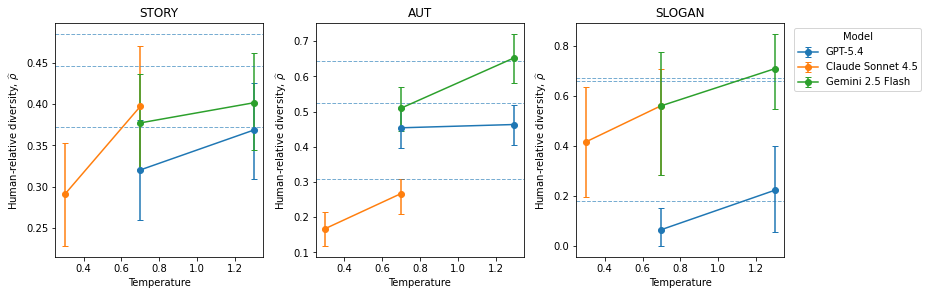

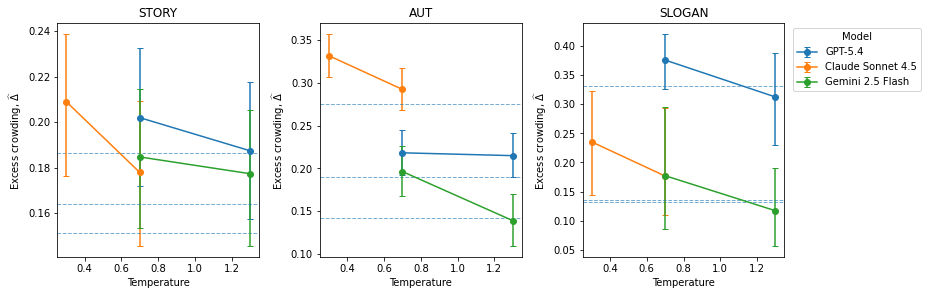

In [19]:
def plot_temperature_robustness(metric: str, ylabel: str, save_path: Path):
    temp_df = robust_vs_main.query("robustness_family == 'temperature'").copy()

    temp_df["temperature_numeric"] = (
        temp_df["robustness_setting"]
        .astype(str)
        .str.extract(r"T=([0-9.]+)")[0]
        .astype(float)
    )

    main_metric = "main_rho" if metric == "rho_mean" else "main_delta"
    ci_low = "rho_ci_low" if metric == "rho_mean" else "delta_ci_low"
    ci_high = "rho_ci_high" if metric == "rho_mean" else "delta_ci_high"

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=False)

    for ax, task in zip(axes, TASK_ORDER):
        sub_task = temp_df.query("task_family == @task").copy()

        if sub_task.empty:
            ax.set_title(task.upper() + " (no data)")
            ax.set_xlabel("Temperature")
            ax.set_ylabel(ylabel)
            continue

        for model_label in MODEL_ORDER:
            sub = sub_task.query("model_label == @model_label").copy()
            if sub.empty:
                continue

            sub = sub.sort_values("temperature_numeric")

            x = sub["temperature_numeric"].to_numpy(dtype=float)
            y = sub[metric].to_numpy(dtype=float)
            yerr_low = y - sub[ci_low].to_numpy(dtype=float)
            yerr_high = sub[ci_high].to_numpy(dtype=float) - y

            ax.errorbar(
                x,
                y,
                yerr=[yerr_low, yerr_high],
                marker="o",
                capsize=3,
                label=model_label,
            )

            main_val = sub[main_metric].iloc[0]
            ax.axhline(main_val, linestyle="--", linewidth=1, alpha=0.6)

        ax.set_title(task.upper())
        ax.set_xlabel("Temperature")
        ax.set_ylabel(ylabel)

    axes[-1].legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_temperature_robustness(
    metric="rho_mean",
    ylabel="Human-relative diversity, $\\widehat{\\rho}$",
    save_path=FIG_DIR / "robustness_temperature_rho_vs_main.pdf",
)

plot_temperature_robustness(
    metric="delta_mean",
    ylabel="Excess crowding, $\\widehat{\\Delta}$",
    save_path=FIG_DIR / "robustness_temperature_delta_vs_main.pdf",
)

## 13. Persona robustness figures

Each point is one persona-temperature setting. These plots show whether persona prompting tends to increase or decrease $\widehat{\rho}$ relative to the main neutral estimate.

/var/folders/rj/l30_wb7d3w7_tbx4gbz6lzzh0000gn/T/ipykernel_74120/2690705652.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showmeans=True)


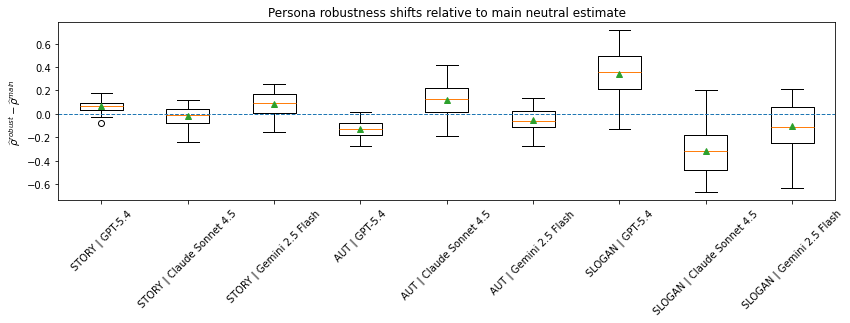

/var/folders/rj/l30_wb7d3w7_tbx4gbz6lzzh0000gn/T/ipykernel_74120/2690705652.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showmeans=True)


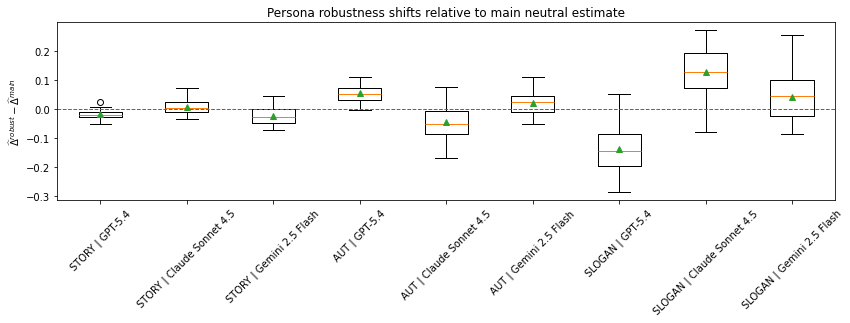

In [20]:
def plot_persona_shift_boxplot(metric_shift: str, ylabel: str, save_path: Path):
    persona_df = robust_vs_main.query("robustness_family == 'persona'").copy()

    # One box per model-task combination.
    persona_df["model_task"] = persona_df["task_family"].str.upper() + " | " + persona_df["model_label"]

    order = []
    for task in TASK_ORDER:
        for model in MODEL_ORDER:
            label = task.upper() + " | " + model
            if label in set(persona_df["model_task"]):
                order.append(label)

    data = [
        persona_df.query("model_task == @label")[metric_shift].dropna().to_numpy()
        for label in order
    ]

    fig, ax = plt.subplots(figsize=(12, 4.6))

    ax.boxplot(data, labels=order, showmeans=True)
    ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.set_ylabel(ylabel)
    ax.set_title("Persona robustness shifts relative to main neutral estimate")
    ax.tick_params(axis="x", rotation=45)

    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_persona_shift_boxplot(
    metric_shift="rho_shift_from_main",
    ylabel="$\\widehat{\\rho}^{robust}-\\widehat{\\rho}^{main}$",
    save_path=FIG_DIR / "robustness_persona_rho_shift_boxplot.pdf",
)

plot_persona_shift_boxplot(
    metric_shift="delta_shift_from_main",
    ylabel="$\\widehat{\\Delta}^{robust}-\\widehat{\\Delta}^{main}$",
    save_path=FIG_DIR / "robustness_persona_delta_shift_boxplot.pdf",
)

## 14. Containment summary figure

This figure summarizes the share of robustness settings whose 95% CI contains the main estimate.

,robustness_family,task_family,model_label,share_rho_contains,share_delta_contains,n_settings
0,persona,aut,Claude Sonnet 4.5,0.239583,0.260417,96
1,persona,aut,GPT-5.4,0.093750,0.166667,96
2,persona,aut,Gemini 2.5 Flash,0.427083,0.458333,96
3,persona,slogan,Claude Sonnet 4.5,0.166667,0.187500,96
4,persona,slogan,GPT-5.4,0.218750,0.229167,96
5,persona,slogan,Gemini 2.5 Flash,0.531250,0.583333,96
6,persona,story,Claude Sonnet 4.5,0.656250,0.822917,96
7,persona,story,GPT-5.4,0.510417,0.812500,96
8,persona,story,Gemini 2.5 Flash,0.375000,0.572917,96
9,temperature,aut,Claude Sonnet 4.5,0.000000,0.500000,2


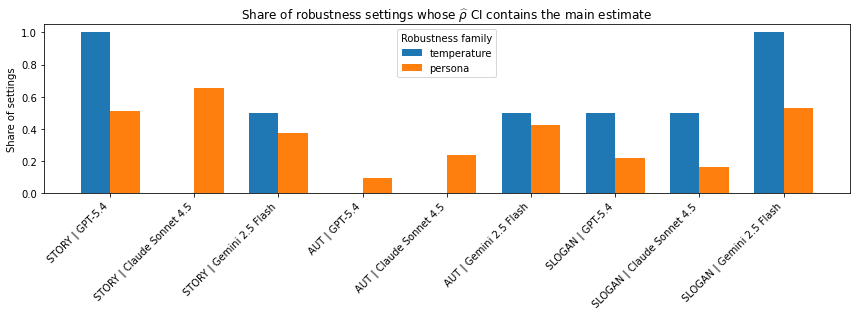

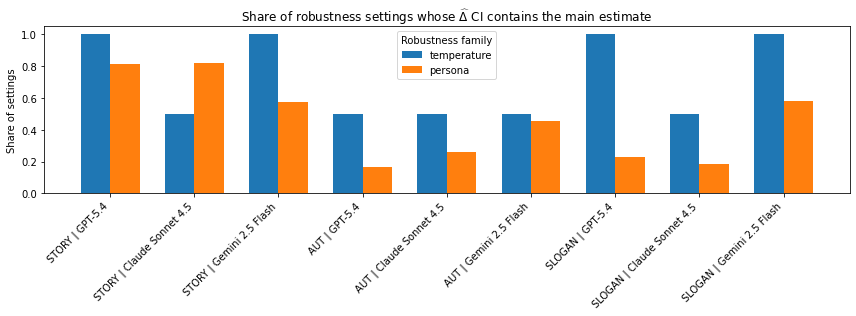

In [21]:
contain_summary = (
    robust_vs_main
    .groupby(["robustness_family", "task_family", "model_label"], dropna=False)
    .agg(
        share_rho_contains=("rho_contains_main_mean", "mean"),
        share_delta_contains=("delta_contains_main_mean", "mean"),
        n_settings=("robustness_setting", "nunique"),
    )
    .reset_index()
)

display(contain_summary)

def plot_containment_summary(metric: str, title: str, save_path: Path):
    plot_df = contain_summary.copy()
    plot_df["model_task"] = plot_df["task_family"].str.upper() + " | " + plot_df["model_label"]

    families = ["temperature", "persona"]
    labels = []

    for task in TASK_ORDER:
        for model in MODEL_ORDER:
            label = task.upper() + " | " + model
            if label in set(plot_df["model_task"]):
                labels.append(label)

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 4.5))

    for i, fam in enumerate(families):
        vals = []
        for label in labels:
            row = plot_df.query("model_task == @label and robustness_family == @fam")
            vals.append(np.nan if row.empty else float(row[metric].iloc[0]))

        ax.bar(x + (i - 0.5) * width, vals, width=width, label=fam)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Share of settings")
    ax.set_title(title)
    ax.legend(title="Robustness family")

    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_containment_summary(
    metric="share_rho_contains",
    title="Share of robustness settings whose $\\widehat{\\rho}$ CI contains the main estimate",
    save_path=FIG_DIR / "robustness_rho_containment_summary.pdf",
)

plot_containment_summary(
    metric="share_delta_contains",
    title="Share of robustness settings whose $\\widehat{\\Delta}$ CI contains the main estimate",
    save_path=FIG_DIR / "robustness_delta_containment_summary.pdf",
)

## 15. Save final robustness status report

These files are the main outputs from the robustness notebook.

In [22]:
print("=" * 100)
print("ROBUSTNESS SEMANTIC OUTPUTS")
print("=" * 100)

saved_paths = [
    TABLE_DIR / "robustness_semantic_sampling_pools.csv",
    TABLE_DIR / "robustness_semantic_condition_level.csv",
    TABLE_DIR / "robustness_semantic_task_level.csv",
    TABLE_DIR / "robustness_semantic_against_main.csv",
    TABLE_DIR / "robustness_semantic_family_summary.csv",
    TABLE_DIR / "robustness_semantic_class_counts.csv",
    TABLE_DIR / "robustness_semantic_top_rho_improvements.csv",
    TABLE_DIR / "robustness_semantic_top_rho_decreases.csv",
    FIG_DIR / "robustness_temperature_rho_vs_main.pdf",
    FIG_DIR / "robustness_temperature_delta_vs_main.pdf",
    FIG_DIR / "robustness_persona_rho_shift_boxplot.pdf",
    FIG_DIR / "robustness_persona_delta_shift_boxplot.pdf",
    FIG_DIR / "robustness_rho_containment_summary.pdf",
    FIG_DIR / "robustness_delta_containment_summary.pdf",
    ROBUST_DIR / "robustness_semantic_condition_bootstrap.pkl",
    ROBUST_DIR / "robustness_semantic_task_bootstrap.pkl",
]

for p in saved_paths:
    print(p, "| exists:", p.exists())

print("\nRecommended manuscript/appendix tables:")
print(TABLE_DIR / "robustness_semantic_family_summary.csv")
print(TABLE_DIR / "robustness_semantic_class_counts.csv")
print(TABLE_DIR / "robustness_semantic_top_rho_improvements.csv")
print(TABLE_DIR / "robustness_semantic_top_rho_decreases.csv")

print("\nRecommended figures:")
print(FIG_DIR / "robustness_temperature_rho_vs_main.pdf")
print(FIG_DIR / "robustness_persona_rho_shift_boxplot.pdf")
print(FIG_DIR / "robustness_rho_containment_summary.pdf")

ROBUSTNESS SEMANTIC OUTPUTS
analysis_outputs/tables/robustness_semantic_sampling_pools.csv | exists: True
analysis_outputs/tables/robustness_semantic_condition_level.csv | exists: True
analysis_outputs/tables/robustness_semantic_task_level.csv | exists: True
analysis_outputs/tables/robustness_semantic_against_main.csv | exists: True
analysis_outputs/tables/robustness_semantic_family_summary.csv | exists: True
analysis_outputs/tables/robustness_semantic_class_counts.csv | exists: True
analysis_outputs/tables/robustness_semantic_top_rho_improvements.csv | exists: True
analysis_outputs/tables/robustness_semantic_top_rho_decreases.csv | exists: True
analysis_outputs/figures/robustness_temperature_rho_vs_main.pdf | exists: True
analysis_outputs/figures/robustness_temperature_delta_vs_main.pdf | exists: True
analysis_outputs/figures/robustness_persona_rho_shift_boxplot.pdf | exists: True
analysis_outputs/figures/robustness_persona_delta_shift_boxplot.pdf | exists: True
analysis_outputs/figur

In [23]:
if "robust_pool_summary" in globals():
    print("Story temperature AI rows before pooling:")
    display(
        robust_analysis_df
        .query("source_type == 'ai' and task_family == 'story' and analysis_scenario_name == 'neutral_temperature_robustness'")
        .groupby(["model_label", "condition_id", "temperature"], dropna=False)
        .size()
        .reset_index(name="n")
        .sort_values(["model_label", "condition_id", "temperature"])
    )

    print("Story temperature rows that survived into robustness pools:")
    display(
        robust_pool_summary
        .query("task_family == 'story' and robustness_family == 'temperature'")
        .groupby(["model_label", "condition_id", "robustness_setting"], dropna=False)
        .size()
        .reset_index(name="n_rows")
        .sort_values(["model_label", "condition_id", "robustness_setting"])
    )
else:
    print("robust_pool_summary not defined yet. Run Section 7 first.")

Story temperature AI rows before pooling:


,model_label,condition_id,temperature,n
0,Claude Sonnet 4.5,10491,0.3,10
1,Claude Sonnet 4.5,10491,0.7,10
2,Claude Sonnet 4.5,93742,0.3,10
3,Claude Sonnet 4.5,93742,0.7,10
4,Claude Sonnet 4.5,93855,0.3,10
5,Claude Sonnet 4.5,93855,0.7,10
6,GPT-5.4,10491,0.7,10
7,GPT-5.4,10491,1.3,10
8,GPT-5.4,93742,0.7,10
9,GPT-5.4,93742,1.3,10


Story temperature rows that survived into robustness pools:


,model_label,condition_id,robustness_setting,n_rows
0,Claude Sonnet 4.5,10491,T=0.3,1
1,Claude Sonnet 4.5,10491,T=0.7,1
2,Claude Sonnet 4.5,93742,T=0.3,1
3,Claude Sonnet 4.5,93742,T=0.7,1
4,Claude Sonnet 4.5,93855,T=0.3,1
5,Claude Sonnet 4.5,93855,T=0.7,1
6,GPT-5.4,10491,T=0.7,1
7,GPT-5.4,10491,T=1.3,1
8,GPT-5.4,93742,T=0.7,1
9,GPT-5.4,93742,T=1.3,1


# 16. Actionable Robustness: Can Generation Protocols Improve $\rho$?

The main benchmark treats the default model distribution as the object of evaluation. But the theory also suggests an actionable design goal: choose generation protocols that reduce excess crowding.

Human parity, $\rho=1$, is not a ceiling. It is the no-externality threshold. If a model or deployment protocol achieves $\rho>1$, then it is more diverse than the matched human baseline under the selected kernel.

Here we test two protocol-level interventions available in current LLMs:

1. **Temperature tuning:** Does increasing temperature monotonically increase $\rho$ and reduce $\Delta$?
2. **Persona-mixture prompting:** Does sampling from a pool of persona-conditioned generations increase $\rho$ relative to the neutral main setting?

All tests use the primary semantic kernel. For temperature trends, we add a matched $T=1.0$ point by subsampling the main neutral generations down to the same $n=10$ scale used by the robustness conditions.

In [24]:
from scipy.stats import spearmanr, kendalltau

## 16.1 Build a comparable temperature grid

The robustness temperature conditions have about 10 outputs per model-condition-temperature. The main $T=1.0$ condition has about 50 outputs per model-condition.

For trend analysis, we therefore create a comparable temperature grid by using:

- the existing robustness temperature generations;
- a subsampled $T=1.0$ neutral-main estimate using $n=10$ AI outputs per condition.

This avoids making the $T=1.0$ point artificially more precise than the other temperature points.

In [25]:
TEMP_TREND_DIR = ANALYSIS_DIR / "crowding_temperature_trend"
TEMP_TREND_DIR.mkdir(parents=True, exist_ok=True)

TEMP_TREND_AI_TARGET_N = 10
N_BOOT_TEMP_TREND = 2000
TEMP_TREND_SEED = 20260506

In [26]:
def make_temperature_grid_ai_table(robust_analysis_df: pd.DataFrame) -> pd.DataFrame:
    """
    Keep neutral temperature-robustness rows and neutral main T=1.0 rows
    from the embedded analysis table.
    """
    assert "embedding_text_id" in robust_analysis_df.columns, (
        "embedding_text_id missing. Rerun Section 5 embedding cell first."
    )

    out = robust_analysis_df.query("source_type == 'ai'").copy()

    keep_mask = (
        out["analysis_scenario_name"].eq("neutral_temperature_robustness")
        | out["analysis_scenario_name"].eq("neutral_main_t1")
    )

    out = out[keep_mask].copy()
    out["temperature"] = pd.to_numeric(out["temperature"], errors="coerce")
    out = out[out["temperature"].notna()].copy()

    out["protocol_family"] = "temperature_grid"
    out["protocol_setting"] = out["temperature"].map(lambda t: f"T={float(t):.1f}")

    assert out["embedding_text_id"].notna().all()

    return out


ai_temp_grid = make_temperature_grid_ai_table(robust_analysis_df)

print("AI temperature-grid rows:", ai_temp_grid.shape)

display(
    ai_temp_grid
    .groupby(["task_family", "model_label", "temperature", "condition_id"], dropna=False)
    .size()
    .reset_index(name="n")
    .sort_values(["task_family", "model_label", "temperature", "condition_id"])
)

print("Number of temperatures per model-task:")
display(
    ai_temp_grid
    .groupby(["task_family", "model_label"], dropna=False)
    .agg(
        n_temperatures=("temperature", "nunique"),
        temperatures=("temperature", lambda x: sorted(pd.Series(x).dropna().unique())),
        n_rows=("response_text", "size"),
    )
    .reset_index()
    .sort_values(["task_family", "model_label"])
)

AI temperature-grid rows: (1890, 22)


,task_family,model_label,temperature,condition_id,n
0,aut,Claude Sonnet 4.5,0.3,automobile_tire,10
1,aut,Claude Sonnet 4.5,0.3,button,10
2,aut,Claude Sonnet 4.5,0.3,key,10
3,aut,Claude Sonnet 4.5,0.3,shoe,10
4,aut,Claude Sonnet 4.5,0.3,wooden_pencil,10
...,...,...,...,...,...
76,story,Gemini 2.5 Flash,1.0,93742,50
77,story,Gemini 2.5 Flash,1.0,93855,50
78,story,Gemini 2.5 Flash,1.3,10491,10
79,story,Gemini 2.5 Flash,1.3,93742,10


Number of temperatures per model-task:


,task_family,model_label,n_temperatures,temperatures,n_rows
0,aut,Claude Sonnet 4.5,3,"[0.3, 0.7, 1.0]",350
1,aut,GPT-5.4,3,"[0.7, 1.0, 1.3]",350
2,aut,Gemini 2.5 Flash,3,"[0.7, 1.0, 1.3]",350
3,slogan,Claude Sonnet 4.5,3,"[0.3, 0.7, 1.0]",70
4,slogan,GPT-5.4,3,"[0.7, 1.0, 1.3]",70
5,slogan,Gemini 2.5 Flash,3,"[0.7, 1.0, 1.3]",70
6,story,Claude Sonnet 4.5,3,"[0.3, 0.7, 1.0]",210
7,story,GPT-5.4,3,"[0.7, 1.0, 1.3]",210
8,story,Gemini 2.5 Flash,3,"[0.7, 1.0, 1.3]",210


## 16.2 Matched bootstrap for the temperature grid

For every model-task-condition-temperature, we sample at most 10 AI outputs. The human side uses the same participant-aware sampling as the main analysis.

For each bootstrap replicate, we estimate:

$ \widehat{\Delta}=\max(0,\widehat{\kappa}^A-\widehat{\kappa}^H) $

$ \widehat{\rho}=\frac{1-\widehat{\kappa}^A}{1-\widehat{\kappa}^H} $

In [27]:
# Build AI pools for the temperature grid.
ai_temp_pools = {}

for keys, g in ai_temp_grid.groupby(
    ["model_label", "task_family", "condition_id", "temperature", "protocol_setting"],
    dropna=False,
):
    ai_temp_pools[keys] = g["embedding_text_id"].astype(int).to_numpy()


temp_pool_rows = []

for keys, ai_ids in ai_temp_pools.items():
    model_label, task, condition_id, temperature, protocol_setting = keys
    human_pool = human_pools.get((task, condition_id))

    if human_pool is None:
        continue

    n_human_participants = len(human_pool)
    n_human_response_rows = int(sum(len(v) for v in human_pool.values()))
    n_ai_available = len(ai_ids)

    b_matched = min(n_human_participants, n_ai_available, TEMP_TREND_AI_TARGET_N)

    temp_pool_rows.append({
        "model_label": model_label,
        "task_family": task,
        "condition_id": condition_id,
        "temperature": temperature,
        "protocol_setting": protocol_setting,
        "n_human_participants": n_human_participants,
        "n_human_response_rows": n_human_response_rows,
        "n_ai_available": n_ai_available,
        "b_matched": b_matched,
    })

temp_grid_pool_summary = pd.DataFrame(temp_pool_rows).sort_values(
    ["task_family", "model_label", "temperature", "condition_id"]
).reset_index(drop=True)

display(temp_grid_pool_summary)

assert (temp_grid_pool_summary["b_matched"] >= 2).all()

temp_grid_pool_summary.to_csv(
    TABLE_DIR / "temperature_grid_sampling_pools.csv",
    index=False,
)

,model_label,task_family,condition_id,temperature,protocol_setting,n_human_participants,n_human_response_rows,n_ai_available,b_matched
0,Claude Sonnet 4.5,aut,automobile_tire,0.3,T=0.3,109,615,10,10
1,Claude Sonnet 4.5,aut,button,0.3,T=0.3,109,603,10,10
2,Claude Sonnet 4.5,aut,key,0.3,T=0.3,109,612,10,10
3,Claude Sonnet 4.5,aut,shoe,0.3,T=0.3,109,604,10,10
4,Claude Sonnet 4.5,aut,wooden_pencil,0.3,T=0.3,109,613,10,10
...,...,...,...,...,...,...,...,...,...
76,Gemini 2.5 Flash,story,93742,1.0,T=1.0,32,32,50,10
77,Gemini 2.5 Flash,story,93855,1.0,T=1.0,20,20,50,10
78,Gemini 2.5 Flash,story,10491,1.3,T=1.3,35,35,10,10
79,Gemini 2.5 Flash,story,93742,1.3,T=1.3,32,32,10,10


In [28]:
def bootstrap_condition_crowding_fixed_ai_n(
    human_participant_pool: Dict[Any, np.ndarray],
    ai_ids: np.ndarray,
    embedding_matrix: np.ndarray,
    ai_target_n: int,
    n_boot: int,
    seed: int,
) -> pd.DataFrame:
    """
    Matched bootstrap with an explicit AI target n.

    The matched sample size is:
        b = min(n_human_participants, n_ai_available, ai_target_n)

    This lets us compare robustness settings with n≈10 to a downsampled main T=1.0 condition.
    """
    rng = np.random.default_rng(seed)

    ai_ids = np.asarray(ai_ids, dtype=int)

    n_human_participants = len(human_participant_pool)
    n_human_response_rows = int(sum(len(v) for v in human_participant_pool.values()))
    n_ai = len(ai_ids)

    b = min(n_human_participants, n_ai, ai_target_n)

    if b < 2:
        raise ValueError(f"Need at least 2 matched units, got b={b}")

    rows = []

    for rep in range(n_boot):
        h_sample = sample_human_one_response_per_participant(
            participant_to_ids=human_participant_pool,
            sample_size=b,
            rng=rng,
        )

        a_sample = rng.choice(ai_ids, size=b, replace=True)

        kappa_h = mean_pairwise_semantic_crowding(h_sample, embedding_matrix)
        kappa_a = mean_pairwise_semantic_crowding(a_sample, embedding_matrix)

        delta = max(0.0, kappa_a - kappa_h)

        denom = 1.0 - kappa_h
        rho = np.nan if denom <= 1e-12 else (1.0 - kappa_a) / denom

        rows.append({
            "bootstrap_rep": rep,
            "b_matched": b,
            "kappa_h": kappa_h,
            "kappa_a": kappa_a,
            "delta": delta,
            "rho": rho,
            "n_human_participants": n_human_participants,
            "n_human_response_rows": n_human_response_rows,
            "n_ai_available": n_ai,
        })

    return pd.DataFrame(rows)


temp_condition_boot_dfs = []

start_time = time.time()

for row in temp_grid_pool_summary.itertuples(index=False):
    model_label = row.model_label
    task = row.task_family
    condition_id = row.condition_id
    temperature = row.temperature
    protocol_setting = row.protocol_setting

    human_pool = human_pools[(task, condition_id)]

    ai_key = (
        model_label,
        task,
        condition_id,
        temperature,
        protocol_setting,
    )
    ai_ids = ai_temp_pools[ai_key]

    seed_payload = (
        f"{TEMP_TREND_SEED}::temperature_grid::{model_label}::{task}"
        f"::{condition_id}::{temperature}"
    )
    seed = int(hashlib.sha256(seed_payload.encode("utf-8")).hexdigest()[:8], 16)

    boot_df = bootstrap_condition_crowding_fixed_ai_n(
        human_participant_pool=human_pool,
        ai_ids=ai_ids,
        embedding_matrix=embedding_matrix,
        ai_target_n=TEMP_TREND_AI_TARGET_N,
        n_boot=N_BOOT_TEMP_TREND,
        seed=seed,
    )

    boot_df["model_label"] = model_label
    boot_df["task_family"] = task
    boot_df["condition_id"] = condition_id
    boot_df["temperature"] = temperature
    boot_df["protocol_family"] = "temperature_grid"
    boot_df["protocol_setting"] = protocol_setting

    temp_condition_boot_dfs.append(boot_df)

    print(
        f"Finished {model_label:20s} | {task:7s} | {condition_id:16s} "
        f"| T={temperature:.1f} | n_ai_available={len(ai_ids)} | b={boot_df['b_matched'].iloc[0]}"
    )

temperature_condition_boot_df = pd.concat(temp_condition_boot_dfs, ignore_index=True)

elapsed = time.time() - start_time
print(f"\nTemperature-grid bootstrap complete: {temperature_condition_boot_df.shape} rows")
print(f"Elapsed time: {elapsed:.1f} seconds")

temperature_condition_boot_df.to_pickle(
    TEMP_TREND_DIR / "temperature_grid_condition_bootstrap.pkl"
)

Finished Claude Sonnet 4.5    | aut     | automobile_tire  | T=0.3 | n_ai_available=10 | b=10
Finished Claude Sonnet 4.5    | aut     | button           | T=0.3 | n_ai_available=10 | b=10
Finished Claude Sonnet 4.5    | aut     | key              | T=0.3 | n_ai_available=10 | b=10
Finished Claude Sonnet 4.5    | aut     | shoe             | T=0.3 | n_ai_available=10 | b=10
Finished Claude Sonnet 4.5    | aut     | wooden_pencil    | T=0.3 | n_ai_available=10 | b=10
Finished Claude Sonnet 4.5    | aut     | automobile_tire  | T=0.7 | n_ai_available=10 | b=10
Finished Claude Sonnet 4.5    | aut     | button           | T=0.7 | n_ai_available=10 | b=10
Finished Claude Sonnet 4.5    | aut     | key              | T=0.7 | n_ai_available=10 | b=10
Finished Claude Sonnet 4.5    | aut     | shoe             | T=0.7 | n_ai_available=10 | b=10
Finished Claude Sonnet 4.5    | aut     | wooden_pencil    | T=0.7 | n_ai_available=10 | b=10
Finished Claude Sonnet 4.5    | aut     | automobile_tire  |

## 16.3 Aggregate temperature-grid estimates to task level

In [29]:
temperature_task_boot_df = (
    temperature_condition_boot_df
    .groupby(
        [
            "bootstrap_rep",
            "task_family",
            "model_label",
            "temperature",
            "protocol_family",
            "protocol_setting",
        ],
        dropna=False,
    )
    .agg(
        kappa_h=("kappa_h", "mean"),
        kappa_a=("kappa_a", "mean"),
        delta=("delta", "mean"),
        rho=("rho", "mean"),
        n_conditions=("condition_id", "nunique"),
        mean_b_matched=("b_matched", "mean"),
        mean_ai_available_per_condition=("n_ai_available", "mean"),
    )
    .reset_index()
)

temperature_task_summary = summarize_bootstrap(
    temperature_task_boot_df,
    group_cols=[
        "task_family",
        "model_label",
        "temperature",
        "protocol_family",
        "protocol_setting",
    ],
    metric_cols=["kappa_h", "kappa_a", "delta", "rho"],
)

temperature_task_meta = (
    temperature_task_boot_df
    .groupby(
        [
            "task_family",
            "model_label",
            "temperature",
            "protocol_family",
            "protocol_setting",
        ],
        dropna=False,
    )
    .agg(
        n_conditions=("n_conditions", "first"),
        mean_b_matched=("mean_b_matched", "first"),
        mean_ai_available_per_condition=("mean_ai_available_per_condition", "first"),
    )
    .reset_index()
)

drop_cols = [
    c for c in ["n_conditions", "mean_b_matched", "mean_ai_available_per_condition"]
    if c in temperature_task_summary.columns
]

temperature_task_summary = temperature_task_summary.drop(columns=drop_cols)
temperature_task_summary = temperature_task_summary.merge(
    temperature_task_meta,
    on=[
        "task_family",
        "model_label",
        "temperature",
        "protocol_family",
        "protocol_setting",
    ],
    how="left",
)

temperature_task_summary = temperature_task_summary.sort_values(
    ["task_family", "model_label", "temperature"]
).reset_index(drop=True)

display(temperature_task_summary)

temperature_task_summary.to_csv(
    TABLE_DIR / "temperature_grid_task_level_semantic_crowding.csv",
    index=False,
)

temperature_task_boot_df.to_pickle(
    TEMP_TREND_DIR / "temperature_grid_task_bootstrap.pkl"
)

,task_family,model_label,temperature,protocol_family,protocol_setting,kappa_h_mean,kappa_h_median,kappa_h_ci_low,kappa_h_ci_high,kappa_a_mean,kappa_a_median,kappa_a_ci_low,kappa_a_ci_high,delta_mean,delta_median,delta_ci_low,delta_ci_high,rho_mean,rho_median,rho_ci_low,rho_ci_high,n_conditions,mean_b_matched,mean_ai_available_per_condition
0,aut,Claude Sonnet 4.5,0.3,temperature_grid,T=0.3,0.600963,0.600869,0.585001,0.618494,0.933035,0.933290,0.914493,0.953624,0.332072,0.331790,0.307022,0.358305,0.167183,0.167205,1.162288e-01,0.213662,5,10.0,10.0
1,aut,Claude Sonnet 4.5,0.7,temperature_grid,T=0.7,0.600963,0.600777,0.585472,0.618427,0.893827,0.892249,0.877235,0.918538,0.292863,0.292124,0.268427,0.321881,0.266028,0.269272,2.028997e-01,0.311482,5,10.0,10.0
2,aut,Claude Sonnet 4.5,1.0,temperature_grid,T=1.0,0.600876,0.600577,0.585452,0.617932,0.876406,0.876217,0.847471,0.904552,0.275530,0.275382,0.241602,0.309251,0.309908,0.309599,2.363955e-01,0.384973,5,10.0,50.0
3,aut,GPT-5.4,0.7,temperature_grid,T=0.7,0.600976,0.600664,0.584796,0.618169,0.820490,0.819273,0.800705,0.845435,0.219514,0.219052,0.192120,0.248416,0.451661,0.453085,3.886341e-01,0.508191,5,10.0,10.0
4,aut,GPT-5.4,1.0,temperature_grid,T=1.0,0.600879,0.600780,0.585585,0.617580,0.790454,0.789843,0.770240,0.813386,0.189575,0.189533,0.163146,0.217973,0.526651,0.527115,4.670124e-01,0.583554,5,10.0,50.0
5,aut,GPT-5.4,1.3,temperature_grid,T=1.3,0.601271,0.601053,0.584960,0.618566,0.815347,0.814958,0.794378,0.838563,0.214076,0.213942,0.186555,0.242226,0.465341,0.466114,4.035895e-01,0.522846,5,10.0,10.0
6,aut,Gemini 2.5 Flash,0.7,temperature_grid,T=0.7,0.601137,0.600790,0.585352,0.618160,0.797752,0.796670,0.776216,0.823789,0.196615,0.196350,0.168774,0.227174,0.508704,0.510631,4.423194e-01,0.567915,5,10.0,10.0
7,aut,Gemini 2.5 Flash,1.0,temperature_grid,T=1.0,0.600997,0.600762,0.584682,0.618339,0.743230,0.743064,0.717508,0.771746,0.142239,0.142314,0.111773,0.174731,0.645550,0.645303,5.705093e-01,0.718393,5,10.0,50.0
8,aut,Gemini 2.5 Flash,1.3,temperature_grid,T=1.3,0.601267,0.600990,0.585926,0.617965,0.739526,0.738550,0.716708,0.767610,0.138260,0.137459,0.110311,0.170153,0.654922,0.657188,5.799077e-01,0.719889,5,10.0,10.0
9,slogan,Claude Sonnet 4.5,0.3,temperature_grid,T=0.3,0.597223,0.595533,0.567387,0.636171,0.831886,0.826409,0.743043,0.921771,0.234663,0.232698,0.138054,0.331041,0.418385,0.434454,1.929844e-01,0.646477,1,10.0,10.0


## 16.4 Monotonic trend tests for temperature

For each model-task pair, we test monotonic association between temperature and diversity.

We report Spearman $\rho_s$ and Kendall $\tau$ for:

- temperature vs. $\widehat{\rho}$, where positive association means higher diversity;
- temperature vs. $\widehat{\Delta}$, where negative association means lower excess crowding.

With only three or four temperature points, these should be interpreted descriptively.

In [30]:
temp_trend_rows = []
skipped_temp_trend_rows = []

for (task, model_label), g in temperature_task_summary.groupby(["task_family", "model_label"], dropna=False):
    g = g.sort_values("temperature").copy()

    n_temps = g["temperature"].nunique()

    if n_temps < 3:
        skipped_temp_trend_rows.append({
            "task_family": task,
            "model_label": model_label,
            "n_temperatures": n_temps,
            "temperatures": ", ".join([f"{x:.1f}" for x in sorted(g["temperature"].dropna().unique())]),
            "reason": "fewer than 3 temperature points",
        })
        continue

    temp = g["temperature"].to_numpy(dtype=float)
    rho_vals = g["rho_mean"].to_numpy(dtype=float)
    delta_vals = g["delta_mean"].to_numpy(dtype=float)
    kappa_a_vals = g["kappa_a_mean"].to_numpy(dtype=float)

    rho_s, rho_s_p = spearmanr(temp, rho_vals)
    tau_rho, tau_rho_p = kendalltau(temp, rho_vals)

    delta_s, delta_s_p = spearmanr(temp, delta_vals)
    tau_delta, tau_delta_p = kendalltau(temp, delta_vals)

    kappa_s, kappa_s_p = spearmanr(temp, kappa_a_vals)
    tau_kappa, tau_kappa_p = kendalltau(temp, kappa_a_vals)

    temp_trend_rows.append({
        "task_family": task,
        "model_label": model_label,
        "n_temperatures": n_temps,
        "temperatures": ", ".join([f"{x:.1f}" for x in temp]),
        "rho_at_min_temp": rho_vals[0],
        "rho_at_max_temp": rho_vals[-1],
        "rho_change_max_minus_min": rho_vals[-1] - rho_vals[0],
        "spearman_temp_rho": rho_s,
        "spearman_temp_rho_p": rho_s_p,
        "kendall_temp_rho": tau_rho,
        "kendall_temp_rho_p": tau_rho_p,
        "delta_at_min_temp": delta_vals[0],
        "delta_at_max_temp": delta_vals[-1],
        "delta_change_max_minus_min": delta_vals[-1] - delta_vals[0],
        "spearman_temp_delta": delta_s,
        "spearman_temp_delta_p": delta_s_p,
        "kendall_temp_delta": tau_delta,
        "kendall_temp_delta_p": tau_delta_p,
        "kappa_a_at_min_temp": kappa_a_vals[0],
        "kappa_a_at_max_temp": kappa_a_vals[-1],
        "kappa_a_change_max_minus_min": kappa_a_vals[-1] - kappa_a_vals[0],
        "spearman_temp_kappa_a": kappa_s,
        "spearman_temp_kappa_a_p": kappa_s_p,
        "kendall_temp_kappa_a": tau_kappa,
        "kendall_temp_kappa_a_p": tau_kappa_p,
    })

temperature_monotonicity = pd.DataFrame(temp_trend_rows)

if len(temperature_monotonicity) > 0:
    temperature_monotonicity = temperature_monotonicity.sort_values(
        ["task_family", "model_label"]
    ).reset_index(drop=True)

display(temperature_monotonicity)

temperature_monotonicity.to_csv(
    TABLE_DIR / "temperature_grid_monotonicity_tests.csv",
    index=False,
)

skipped_temperature_monotonicity = pd.DataFrame(skipped_temp_trend_rows)
display(skipped_temperature_monotonicity)

skipped_temperature_monotonicity.to_csv(
    TABLE_DIR / "temperature_grid_monotonicity_skipped.csv",
    index=False,
)

,task_family,model_label,n_temperatures,temperatures,rho_at_min_temp,rho_at_max_temp,rho_change_max_minus_min,spearman_temp_rho,spearman_temp_rho_p,kendall_temp_rho,kendall_temp_rho_p,delta_at_min_temp,delta_at_max_temp,delta_change_max_minus_min,spearman_temp_delta,spearman_temp_delta_p,kendall_temp_delta,kendall_temp_delta_p,kappa_a_at_min_temp,kappa_a_at_max_temp,kappa_a_change_max_minus_min,spearman_temp_kappa_a,spearman_temp_kappa_a_p,kendall_temp_kappa_a,kendall_temp_kappa_a_p
0,aut,Claude Sonnet 4.5,3,"0.3, 0.7, 1.0",0.167183,0.309908,0.142725,1.0,0.000000,1.000000,0.333333,0.332072,0.275530,-0.056542,-1.0,0.000000,-1.000000,0.333333,0.933035,0.876406,-0.056629,-1.0,0.000000,-1.000000,0.333333
1,aut,GPT-5.4,3,"0.7, 1.0, 1.3",0.451661,0.465341,0.013680,0.5,0.666667,0.333333,1.000000,0.219514,0.214076,-0.005438,-0.5,0.666667,-0.333333,1.000000,0.820490,0.815347,-0.005144,-0.5,0.666667,-0.333333,1.000000
2,aut,Gemini 2.5 Flash,3,"0.7, 1.0, 1.3",0.508704,0.654922,0.146218,1.0,0.000000,1.000000,0.333333,0.196615,0.138260,-0.058356,-1.0,0.000000,-1.000000,0.333333,0.797752,0.739526,-0.058226,-1.0,0.000000,-1.000000,0.333333
3,slogan,Claude Sonnet 4.5,3,"0.3, 0.7, 1.0",0.418385,0.672215,0.253831,1.0,0.000000,1.000000,0.333333,0.234663,0.132444,-0.102219,-1.0,0.000000,-1.000000,0.333333,0.831886,0.729998,-0.101887,-1.0,0.000000,-1.000000,0.333333
4,slogan,GPT-5.4,3,"0.7, 1.0, 1.3",0.064431,0.227421,0.162989,1.0,0.000000,1.000000,0.333333,0.376884,0.311506,-0.065379,-1.0,0.000000,-1.000000,0.333333,0.974095,0.908573,-0.065522,-1.0,0.000000,-1.000000,0.333333
5,slogan,Gemini 2.5 Flash,3,"0.7, 1.0, 1.3",0.569634,0.710626,0.140992,1.0,0.000000,1.000000,0.333333,0.173495,0.117089,-0.056406,-1.0,0.000000,-1.000000,0.333333,0.771360,0.714502,-0.056858,-1.0,0.000000,-1.000000,0.333333
6,story,Claude Sonnet 4.5,3,"0.3, 0.7, 1.0",0.289102,0.487483,0.198380,1.0,0.000000,1.000000,0.333333,0.209695,0.151311,-0.058385,-1.0,0.000000,-1.000000,0.333333,0.915099,0.856878,-0.058222,-1.0,0.000000,-1.000000,0.333333
7,story,GPT-5.4,3,"0.7, 1.0, 1.3",0.319502,0.367760,0.048258,0.5,0.666667,0.333333,1.000000,0.202614,0.187909,-0.014705,-0.5,0.666667,-0.333333,1.000000,0.907853,0.893070,-0.014783,-0.5,0.666667,-0.333333,1.000000
8,story,Gemini 2.5 Flash,3,"0.7, 1.0, 1.3",0.378065,0.401493,0.023428,0.5,0.666667,0.333333,1.000000,0.184751,0.177391,-0.007360,-0.5,0.666667,-0.333333,1.000000,0.890121,0.883073,-0.007048,-0.5,0.666667,-0.333333,1.000000


""


## 16.5 Plot the full temperature grid

These plots include the downsampled neutral main $T=1.0$ point, so the trend is shown over the full available temperature grid.

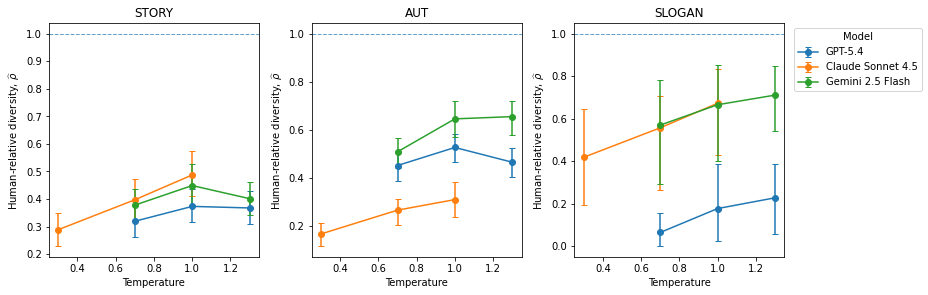

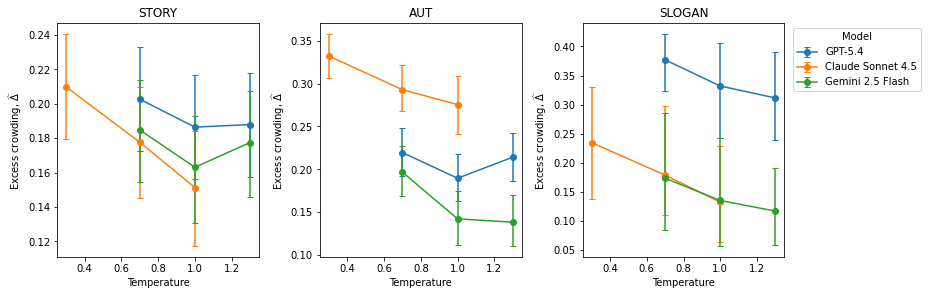

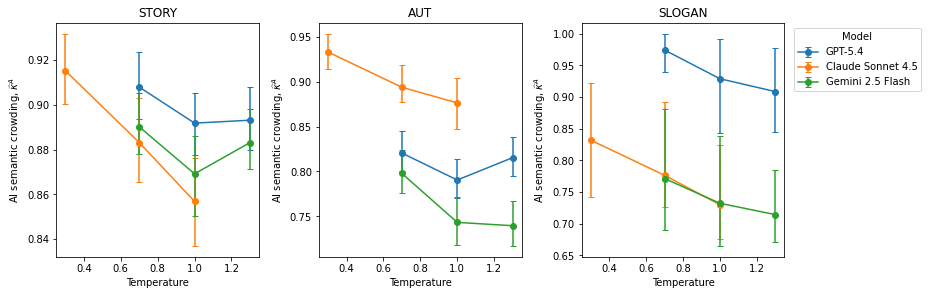

In [31]:
def plot_temperature_grid_metric(
    summary_df: pd.DataFrame,
    metric: str,
    ci_low: str,
    ci_high: str,
    ylabel: str,
    save_path: Path,
):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=False)

    for ax, task in zip(axes, TASK_ORDER):
        sub_task = summary_df.query("task_family == @task").copy()

        for model_label in MODEL_ORDER:
            sub = sub_task.query("model_label == @model_label").copy()
            if sub.empty:
                continue

            sub = sub.sort_values("temperature")

            x = sub["temperature"].to_numpy(dtype=float)
            y = sub[metric].to_numpy(dtype=float)
            yerr_low = y - sub[ci_low].to_numpy(dtype=float)
            yerr_high = sub[ci_high].to_numpy(dtype=float) - y

            ax.errorbar(
                x,
                y,
                yerr=[yerr_low, yerr_high],
                marker="o",
                capsize=3,
                label=model_label,
            )

        if metric == "rho_mean":
            ax.axhline(1.0, linestyle="--", linewidth=1, alpha=0.7)

        ax.set_title(task.upper())
        ax.set_xlabel("Temperature")
        ax.set_ylabel(ylabel)

    axes[-1].legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_temperature_grid_metric(
    temperature_task_summary,
    metric="rho_mean",
    ci_low="rho_ci_low",
    ci_high="rho_ci_high",
    ylabel="Human-relative diversity, $\\widehat{\\rho}$",
    save_path=FIG_DIR / "temperature_grid_rho_with_main_t1.pdf",
)

plot_temperature_grid_metric(
    temperature_task_summary,
    metric="delta_mean",
    ci_low="delta_ci_low",
    ci_high="delta_ci_high",
    ylabel="Excess crowding, $\\widehat{\\Delta}$",
    save_path=FIG_DIR / "temperature_grid_delta_with_main_t1.pdf",
)

plot_temperature_grid_metric(
    temperature_task_summary,
    metric="kappa_a_mean",
    ci_low="kappa_a_ci_low",
    ci_high="kappa_a_ci_high",
    ylabel="AI semantic crowding, $\\widehat{\\kappa}^A$",
    save_path=FIG_DIR / "temperature_grid_kappa_a_with_main_t1.pdf",
)

# 17. Persona-Mixture Protocols

The per-persona robustness analysis asks whether each persona setting individually differs from the neutral main setting.

Here we ask a different deployment question:

What if a platform or user intentionally samples from a *mixture* of persona-conditioned prompts?

This creates a broader model-output distribution. If the mixture increases $\rho$ and reduces $\Delta$, then persona diversification is an actionable protocol-level way to reduce population crowding.

We test persona mixtures at fixed temperature. The most direct comparison is:

- neutral main $T=1.0$;
- pooled persona mixture at $T=1.0$.

For each model-task-condition, we pool all persona generations at a fixed temperature and estimate crowding using a matched AI sample size of 50 when available.

In [32]:
PERSONA_MIX_DIR = ANALYSIS_DIR / "crowding_persona_mixture"
PERSONA_MIX_DIR.mkdir(parents=True, exist_ok=True)

PERSONA_MIX_AI_TARGET_N = 50
N_BOOT_PERSONA_MIX = 2000
PERSONA_MIX_SEED = 20260507

In [33]:
def make_persona_mixture_ai_table(robust_analysis_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build persona-mixture table from the embedded analysis table,
    so embedding_text_id is available.
    """
    assert "embedding_text_id" in robust_analysis_df.columns, (
        "embedding_text_id missing. Rerun Section 5 embedding cell first."
    )

    out = robust_analysis_df.query("source_type == 'ai'").copy()
    out = out[out["analysis_scenario_name"].eq("personality_grid")].copy()

    out["temperature"] = pd.to_numeric(out["temperature"], errors="coerce")
    out = out[out["temperature"].notna()].copy()

    out["protocol_family"] = "persona_mixture"
    out["protocol_setting"] = out["temperature"].map(lambda t: f"persona_mix_T={float(t):.1f}")

    assert out["embedding_text_id"].notna().all()

    return out


ai_persona_mix = make_persona_mixture_ai_table(robust_analysis_df)

print("AI persona-mixture rows:", ai_persona_mix.shape)

display(
    ai_persona_mix
    .groupby(["task_family", "model_label", "temperature", "condition_id"], dropna=False)
    .agg(
        n_rows=("response_text", "size"),
        n_personas=("persona_id", "nunique"),
    )
    .reset_index()
    .sort_values(["task_family", "model_label", "temperature", "condition_id"])
)

AI persona-mixture rows: (25920, 22)


,task_family,model_label,temperature,condition_id,n_rows,n_personas
0,aut,Claude Sonnet 4.5,0.3,automobile_tire,320,32
1,aut,Claude Sonnet 4.5,0.3,button,320,32
2,aut,Claude Sonnet 4.5,0.3,key,320,32
3,aut,Claude Sonnet 4.5,0.3,shoe,320,32
4,aut,Claude Sonnet 4.5,0.3,wooden_pencil,320,32
...,...,...,...,...,...,...
76,story,Gemini 2.5 Flash,1.0,93742,320,32
77,story,Gemini 2.5 Flash,1.0,93855,320,32
78,story,Gemini 2.5 Flash,1.3,10491,320,32
79,story,Gemini 2.5 Flash,1.3,93742,320,32


## 17.1 Matched bootstrap for persona-mixture protocols

Each persona-mixture pool contains many more than 50 AI generations. To keep comparability with the main analysis, we sample up to 50 AI generations per model-condition-temperature in each bootstrap replicate.

In [34]:
# AI pools for persona-mixture settings.
persona_mix_pools = {}

for keys, g in ai_persona_mix.groupby(
    ["model_label", "task_family", "condition_id", "temperature", "protocol_setting"],
    dropna=False,
):
    persona_mix_pools[keys] = g["embedding_text_id"].astype(int).to_numpy()


persona_mix_pool_rows = []

for keys, ai_ids in persona_mix_pools.items():
    model_label, task, condition_id, temperature, protocol_setting = keys
    human_pool = human_pools.get((task, condition_id))

    if human_pool is None:
        continue

    n_human_participants = len(human_pool)
    n_human_response_rows = int(sum(len(v) for v in human_pool.values()))
    n_ai_available = len(ai_ids)

    b_matched = min(n_human_participants, n_ai_available, PERSONA_MIX_AI_TARGET_N)

    persona_mix_pool_rows.append({
        "model_label": model_label,
        "task_family": task,
        "condition_id": condition_id,
        "temperature": temperature,
        "protocol_setting": protocol_setting,
        "n_human_participants": n_human_participants,
        "n_human_response_rows": n_human_response_rows,
        "n_ai_available": n_ai_available,
        "b_matched": b_matched,
    })

persona_mix_pool_summary = pd.DataFrame(persona_mix_pool_rows).sort_values(
    ["task_family", "model_label", "temperature", "condition_id"]
).reset_index(drop=True)

display(persona_mix_pool_summary)

assert (persona_mix_pool_summary["b_matched"] >= 2).all()

persona_mix_pool_summary.to_csv(
    TABLE_DIR / "persona_mixture_sampling_pools.csv",
    index=False,
)

,model_label,task_family,condition_id,temperature,protocol_setting,n_human_participants,n_human_response_rows,n_ai_available,b_matched
0,Claude Sonnet 4.5,aut,automobile_tire,0.3,persona_mix_T=0.3,109,615,320,50
1,Claude Sonnet 4.5,aut,button,0.3,persona_mix_T=0.3,109,603,320,50
2,Claude Sonnet 4.5,aut,key,0.3,persona_mix_T=0.3,109,612,320,50
3,Claude Sonnet 4.5,aut,shoe,0.3,persona_mix_T=0.3,109,604,320,50
4,Claude Sonnet 4.5,aut,wooden_pencil,0.3,persona_mix_T=0.3,109,613,320,50
...,...,...,...,...,...,...,...,...,...
76,Gemini 2.5 Flash,story,93742,1.0,persona_mix_T=1.0,32,32,320,32
77,Gemini 2.5 Flash,story,93855,1.0,persona_mix_T=1.0,20,20,320,20
78,Gemini 2.5 Flash,story,10491,1.3,persona_mix_T=1.3,35,35,320,35
79,Gemini 2.5 Flash,story,93742,1.3,persona_mix_T=1.3,32,32,320,32


In [35]:
persona_mix_condition_boot_dfs = []

start_time = time.time()

for row in persona_mix_pool_summary.itertuples(index=False):
    model_label = row.model_label
    task = row.task_family
    condition_id = row.condition_id
    temperature = row.temperature
    protocol_setting = row.protocol_setting

    human_pool = human_pools[(task, condition_id)]

    ai_key = (
        model_label,
        task,
        condition_id,
        temperature,
        protocol_setting,
    )
    ai_ids = persona_mix_pools[ai_key]

    seed_payload = (
        f"{PERSONA_MIX_SEED}::persona_mix::{model_label}::{task}"
        f"::{condition_id}::{temperature}"
    )
    seed = int(hashlib.sha256(seed_payload.encode("utf-8")).hexdigest()[:8], 16)

    boot_df = bootstrap_condition_crowding_fixed_ai_n(
        human_participant_pool=human_pool,
        ai_ids=ai_ids,
        embedding_matrix=embedding_matrix,
        ai_target_n=PERSONA_MIX_AI_TARGET_N,
        n_boot=N_BOOT_PERSONA_MIX,
        seed=seed,
    )

    boot_df["model_label"] = model_label
    boot_df["task_family"] = task
    boot_df["condition_id"] = condition_id
    boot_df["temperature"] = temperature
    boot_df["protocol_family"] = "persona_mixture"
    boot_df["protocol_setting"] = protocol_setting

    persona_mix_condition_boot_dfs.append(boot_df)

    print(
        f"Finished {model_label:20s} | {task:7s} | {condition_id:16s} "
        f"| persona mix T={temperature:.1f} | n_ai_available={len(ai_ids)} | b={boot_df['b_matched'].iloc[0]}"
    )

persona_mix_condition_boot_df = pd.concat(persona_mix_condition_boot_dfs, ignore_index=True)

elapsed = time.time() - start_time
print(f"\nPersona-mixture bootstrap complete: {persona_mix_condition_boot_df.shape} rows")
print(f"Elapsed time: {elapsed:.1f} seconds")

persona_mix_condition_boot_df.to_pickle(
    PERSONA_MIX_DIR / "persona_mixture_condition_bootstrap.pkl"
)

Finished Claude Sonnet 4.5    | aut     | automobile_tire  | persona mix T=0.3 | n_ai_available=320 | b=50
Finished Claude Sonnet 4.5    | aut     | button           | persona mix T=0.3 | n_ai_available=320 | b=50
Finished Claude Sonnet 4.5    | aut     | key              | persona mix T=0.3 | n_ai_available=320 | b=50
Finished Claude Sonnet 4.5    | aut     | shoe             | persona mix T=0.3 | n_ai_available=320 | b=50
Finished Claude Sonnet 4.5    | aut     | wooden_pencil    | persona mix T=0.3 | n_ai_available=320 | b=50
Finished Claude Sonnet 4.5    | aut     | automobile_tire  | persona mix T=0.7 | n_ai_available=320 | b=50
Finished Claude Sonnet 4.5    | aut     | button           | persona mix T=0.7 | n_ai_available=320 | b=50
Finished Claude Sonnet 4.5    | aut     | key              | persona mix T=0.7 | n_ai_available=320 | b=50
Finished Claude Sonnet 4.5    | aut     | shoe             | persona mix T=0.7 | n_ai_available=320 | b=50
Finished Claude Sonnet 4.5    | aut  

Finished Gemini 2.5 Flash     | story   | 93855            | persona mix T=1.0 | n_ai_available=320 | b=20
Finished Gemini 2.5 Flash     | story   | 10491            | persona mix T=1.3 | n_ai_available=320 | b=35
Finished Gemini 2.5 Flash     | story   | 93742            | persona mix T=1.3 | n_ai_available=320 | b=32
Finished Gemini 2.5 Flash     | story   | 93855            | persona mix T=1.3 | n_ai_available=320 | b=20

Persona-mixture bootstrap complete: (162000, 15) rows
Elapsed time: 70.0 seconds


## 17.2 Aggregate persona-mixture estimates to task level

In [36]:
persona_mix_task_boot_df = (
    persona_mix_condition_boot_df
    .groupby(
        [
            "bootstrap_rep",
            "task_family",
            "model_label",
            "temperature",
            "protocol_family",
            "protocol_setting",
        ],
        dropna=False,
    )
    .agg(
        kappa_h=("kappa_h", "mean"),
        kappa_a=("kappa_a", "mean"),
        delta=("delta", "mean"),
        rho=("rho", "mean"),
        n_conditions=("condition_id", "nunique"),
        mean_b_matched=("b_matched", "mean"),
        mean_ai_available_per_condition=("n_ai_available", "mean"),
    )
    .reset_index()
)

persona_mix_task_summary = summarize_bootstrap(
    persona_mix_task_boot_df,
    group_cols=[
        "task_family",
        "model_label",
        "temperature",
        "protocol_family",
        "protocol_setting",
    ],
    metric_cols=["kappa_h", "kappa_a", "delta", "rho"],
)

persona_mix_task_meta = (
    persona_mix_task_boot_df
    .groupby(
        [
            "task_family",
            "model_label",
            "temperature",
            "protocol_family",
            "protocol_setting",
        ],
        dropna=False,
    )
    .agg(
        n_conditions=("n_conditions", "first"),
        mean_b_matched=("mean_b_matched", "first"),
        mean_ai_available_per_condition=("mean_ai_available_per_condition", "first"),
    )
    .reset_index()
)

drop_cols = [
    c for c in ["n_conditions", "mean_b_matched", "mean_ai_available_per_condition"]
    if c in persona_mix_task_summary.columns
]

persona_mix_task_summary = persona_mix_task_summary.drop(columns=drop_cols)
persona_mix_task_summary = persona_mix_task_summary.merge(
    persona_mix_task_meta,
    on=[
        "task_family",
        "model_label",
        "temperature",
        "protocol_family",
        "protocol_setting",
    ],
    how="left",
)

persona_mix_task_summary = persona_mix_task_summary.sort_values(
    ["task_family", "model_label", "temperature"]
).reset_index(drop=True)

display(persona_mix_task_summary)

persona_mix_task_summary.to_csv(
    TABLE_DIR / "persona_mixture_task_level_semantic_crowding.csv",
    index=False,
)

persona_mix_task_boot_df.to_pickle(
    PERSONA_MIX_DIR / "persona_mixture_task_bootstrap.pkl"
)

,task_family,model_label,temperature,protocol_family,protocol_setting,kappa_h_mean,kappa_h_median,kappa_h_ci_low,kappa_h_ci_high,kappa_a_mean,kappa_a_median,kappa_a_ci_low,kappa_a_ci_high,delta_mean,delta_median,delta_ci_low,delta_ci_high,rho_mean,rho_median,rho_ci_low,rho_ci_high,n_conditions,mean_b_matched,mean_ai_available_per_condition
0,aut,Claude Sonnet 4.5,0.3,persona_mixture,persona_mix_T=0.3,0.601132,0.601059,0.594426,0.608092,0.723045,0.722979,0.713126,0.733103,0.121914,0.122042,0.109771,0.133562,0.694514,0.694311,0.668315,0.722549,5,50.0,320.0
1,aut,Claude Sonnet 4.5,0.7,persona_mixture,persona_mix_T=0.7,0.601126,0.600962,0.594711,0.608214,0.708654,0.708631,0.698681,0.719028,0.107528,0.107596,0.095909,0.119055,0.730644,0.730555,0.703183,0.758330,5,50.0,320.0
2,aut,Claude Sonnet 4.5,1.0,persona_mixture,persona_mix_T=1.0,0.601258,0.601243,0.594361,0.608269,0.705324,0.705182,0.696158,0.714808,0.104065,0.104040,0.092677,0.115637,0.739183,0.739061,0.712091,0.765349,5,50.0,320.0
3,aut,GPT-5.4,0.7,persona_mixture,persona_mix_T=0.7,0.601164,0.601179,0.594581,0.607931,0.810766,0.810771,0.801184,0.819839,0.209602,0.209538,0.198221,0.220846,0.475115,0.475214,0.451070,0.500164,5,50.0,320.0
4,aut,GPT-5.4,1.0,persona_mixture,persona_mix_T=1.0,0.601244,0.601179,0.594771,0.607965,0.797978,0.798030,0.788650,0.807482,0.196733,0.196812,0.185020,0.207806,0.507319,0.507113,0.482680,0.532670,5,50.0,320.0
5,aut,GPT-5.4,1.3,persona_mixture,persona_mix_T=1.3,0.601087,0.601036,0.594593,0.608233,0.791743,0.791661,0.782401,0.801624,0.190657,0.190758,0.179390,0.202740,0.522732,0.522754,0.496471,0.547786,5,50.0,320.0
6,aut,Gemini 2.5 Flash,0.7,persona_mixture,persona_mix_T=0.7,0.601114,0.601108,0.593950,0.608113,0.713617,0.713583,0.703869,0.723248,0.112503,0.112591,0.100796,0.124538,0.718621,0.718179,0.691442,0.746074,5,50.0,320.0
7,aut,Gemini 2.5 Flash,1.0,persona_mixture,persona_mix_T=1.0,0.601149,0.601150,0.594487,0.607868,0.694711,0.694650,0.685362,0.704196,0.093562,0.093485,0.082520,0.105216,0.766047,0.766217,0.739261,0.792151,5,50.0,320.0
8,aut,Gemini 2.5 Flash,1.3,persona_mixture,persona_mix_T=1.3,0.601153,0.601140,0.594434,0.607969,0.679475,0.679432,0.671128,0.688906,0.078322,0.078095,0.067564,0.089609,0.804151,0.804302,0.777430,0.828982,5,50.0,320.0
9,slogan,Claude Sonnet 4.5,0.3,persona_mixture,persona_mix_T=0.3,0.597492,0.597169,0.584258,0.612210,0.615937,0.614899,0.600387,0.635874,0.018676,0.018558,0.000000,0.043806,0.954491,0.953955,0.893530,1.009288,1,50.0,320.0


## 17.3 Compare persona mixtures to neutral main

The key comparison is persona-mixture $T=1.0$ versus neutral-main $T=1.0$.

If the persona-mixture estimate has higher $\rho$ and lower $\Delta$, then persona diversification improves the population-level diversity objective.

In [37]:
persona_mix_vs_main = persona_mix_task_summary.merge(
    main_ref,
    on=["model_label", "task_family"],
    how="left",
    validate="many_to_one",
)

persona_mix_vs_main["rho_shift_from_main"] = (
    persona_mix_vs_main["rho_mean"] - persona_mix_vs_main["main_rho"]
)
persona_mix_vs_main["delta_shift_from_main"] = (
    persona_mix_vs_main["delta_mean"] - persona_mix_vs_main["main_delta"]
)

persona_mix_vs_main["rho_contains_main_mean"] = (
    (persona_mix_vs_main["rho_ci_low"] <= persona_mix_vs_main["main_rho"])
    & (persona_mix_vs_main["main_rho"] <= persona_mix_vs_main["rho_ci_high"])
)

persona_mix_vs_main["delta_contains_main_mean"] = (
    (persona_mix_vs_main["delta_ci_low"] <= persona_mix_vs_main["main_delta"])
    & (persona_mix_vs_main["main_delta"] <= persona_mix_vs_main["delta_ci_high"])
)

def classify_protocol_shift(row):
    if (row["rho_ci_low"] > row["main_rho"]) and (row["delta_ci_high"] < row["main_delta"]):
        return "higher diversity than main"
    if (row["rho_ci_high"] < row["main_rho"]) and (row["delta_ci_low"] > row["main_delta"]):
        return "lower diversity than main"
    if row["rho_contains_main_mean"] and row["delta_contains_main_mean"]:
        return "stable"
    return "mixed / partial shift"

persona_mix_vs_main["protocol_shift_class"] = persona_mix_vs_main.apply(
    classify_protocol_shift,
    axis=1,
)

display(
    persona_mix_vs_main[
        [
            "task_family",
            "model_label",
            "temperature",
            "protocol_setting",
            "mean_ai_available_per_condition",
            "main_rho",
            "rho_mean",
            "rho_ci_low",
            "rho_ci_high",
            "rho_shift_from_main",
            "main_delta",
            "delta_mean",
            "delta_ci_low",
            "delta_ci_high",
            "delta_shift_from_main",
            "protocol_shift_class",
        ]
    ].sort_values(["task_family", "model_label", "temperature"])
)

persona_mix_vs_main.to_csv(
    TABLE_DIR / "persona_mixture_against_main.csv",
    index=False,
)

,task_family,model_label,temperature,protocol_setting,mean_ai_available_per_condition,main_rho,rho_mean,rho_ci_low,rho_ci_high,rho_shift_from_main,main_delta,delta_mean,delta_ci_low,delta_ci_high,delta_shift_from_main,protocol_shift_class
0,aut,Claude Sonnet 4.5,0.3,persona_mix_T=0.3,320.0,0.308882,0.694514,0.668315,0.722549,0.385632,0.275362,0.121914,0.109771,0.133562,-0.153448,higher diversity than main
1,aut,Claude Sonnet 4.5,0.7,persona_mix_T=0.7,320.0,0.308882,0.730644,0.703183,0.758330,0.421762,0.275362,0.107528,0.095909,0.119055,-0.167834,higher diversity than main
2,aut,Claude Sonnet 4.5,1.0,persona_mix_T=1.0,320.0,0.308882,0.739183,0.712091,0.765349,0.430302,0.275362,0.104065,0.092677,0.115637,-0.171296,higher diversity than main
3,aut,GPT-5.4,0.7,persona_mix_T=0.7,320.0,0.525446,0.475115,0.451070,0.500164,-0.050330,0.189520,0.209602,0.198221,0.220846,0.020082,lower diversity than main
4,aut,GPT-5.4,1.0,persona_mix_T=1.0,320.0,0.525446,0.507319,0.482680,0.532670,-0.018127,0.189520,0.196733,0.185020,0.207806,0.007213,stable
5,aut,GPT-5.4,1.3,persona_mix_T=1.3,320.0,0.525446,0.522732,0.496471,0.547786,-0.002714,0.189520,0.190657,0.179390,0.202740,0.001137,stable
6,aut,Gemini 2.5 Flash,0.7,persona_mix_T=0.7,320.0,0.644685,0.718621,0.691442,0.746074,0.073936,0.142037,0.112503,0.100796,0.124538,-0.029533,higher diversity than main
7,aut,Gemini 2.5 Flash,1.0,persona_mix_T=1.0,320.0,0.644685,0.766047,0.739261,0.792151,0.121362,0.142037,0.093562,0.082520,0.105216,-0.048474,higher diversity than main
8,aut,Gemini 2.5 Flash,1.3,persona_mix_T=1.3,320.0,0.644685,0.804151,0.777430,0.828982,0.159467,0.142037,0.078322,0.067564,0.089609,-0.063715,higher diversity than main
9,slogan,Claude Sonnet 4.5,0.3,persona_mix_T=0.3,320.0,0.672075,0.954491,0.893530,1.009288,0.282416,0.132137,0.018676,0.000000,0.043806,-0.113462,higher diversity than main


## 17.4 Plot persona-mixture improvements

This figure shows how much persona mixtures shift $\widehat{\rho}$ relative to the neutral main estimate.

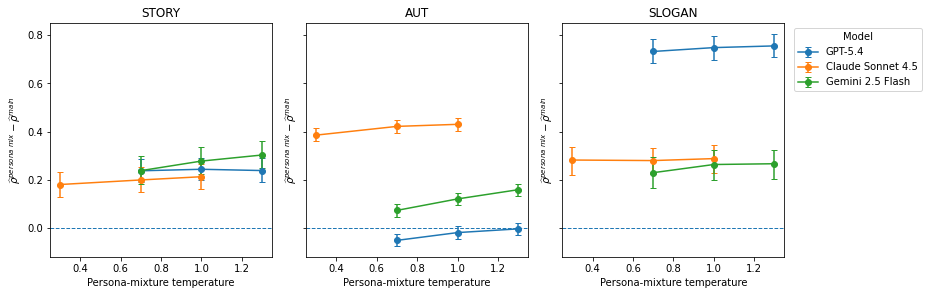

In [38]:
def plot_persona_mixture_rho_shift(save_path: Path):
    plot_df = persona_mix_vs_main.copy()

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)

    for ax, task in zip(axes, TASK_ORDER):
        sub_task = plot_df.query("task_family == @task").copy()

        for model_label in MODEL_ORDER:
            sub = sub_task.query("model_label == @model_label").copy()
            if sub.empty:
                continue

            sub = sub.sort_values("temperature")

            x = sub["temperature"].to_numpy(dtype=float)
            y = sub["rho_shift_from_main"].to_numpy(dtype=float)

            # Approximate error bars around shift using persona-mixture CI only;
            # main estimate uncertainty is omitted for visual simplicity.
            yerr_low = sub["rho_mean"].to_numpy(dtype=float) - sub["rho_ci_low"].to_numpy(dtype=float)
            yerr_high = sub["rho_ci_high"].to_numpy(dtype=float) - sub["rho_mean"].to_numpy(dtype=float)

            ax.errorbar(
                x,
                y,
                yerr=[yerr_low, yerr_high],
                marker="o",
                capsize=3,
                label=model_label,
            )

        ax.axhline(0.0, linestyle="--", linewidth=1)
        ax.set_title(task.upper())
        ax.set_xlabel("Persona-mixture temperature")
        ax.set_ylabel("$\\widehat{\\rho}^{persona\\ mix}-\\widehat{\\rho}^{main}$")

    axes[-1].legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_persona_mixture_rho_shift(
    save_path=FIG_DIR / "persona_mixture_rho_shift_from_main.pdf"
)

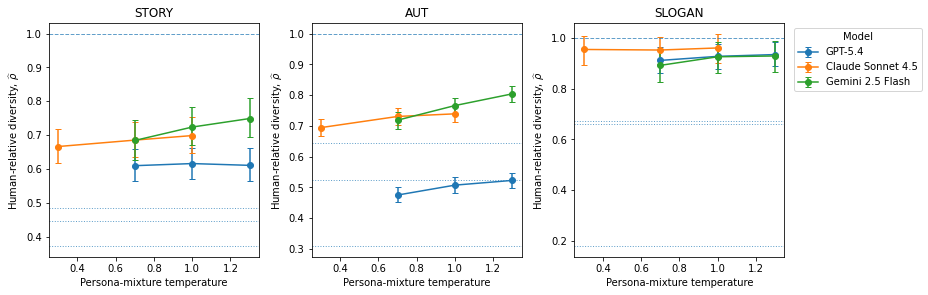

In [39]:
def plot_persona_mixture_rho_absolute(save_path: Path):
    plot_df = persona_mix_vs_main.copy()

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=False)

    for ax, task in zip(axes, TASK_ORDER):
        sub_task = plot_df.query("task_family == @task").copy()

        for model_label in MODEL_ORDER:
            sub = sub_task.query("model_label == @model_label").copy()
            if sub.empty:
                continue

            sub = sub.sort_values("temperature")

            x = sub["temperature"].to_numpy(dtype=float)
            y = sub["rho_mean"].to_numpy(dtype=float)
            yerr_low = y - sub["rho_ci_low"].to_numpy(dtype=float)
            yerr_high = sub["rho_ci_high"].to_numpy(dtype=float) - y

            ax.errorbar(
                x,
                y,
                yerr=[yerr_low, yerr_high],
                marker="o",
                capsize=3,
                label=model_label,
            )

            # Main neutral reference for this model-task.
            main_val = sub["main_rho"].iloc[0]
            ax.axhline(main_val, linestyle=":", linewidth=1, alpha=0.7)

        ax.axhline(1.0, linestyle="--", linewidth=1, alpha=0.7)
        ax.set_title(task.upper())
        ax.set_xlabel("Persona-mixture temperature")
        ax.set_ylabel("Human-relative diversity, $\\widehat{\\rho}$")

    axes[-1].legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_persona_mixture_rho_absolute(
    save_path=FIG_DIR / "persona_mixture_rho_absolute.pdf"
)

## 17.4 Direct comparison: neutral main vs. persona-mixture at $T=1.0$

To isolate the effect of persona diversification, we compare the neutral main protocol and the persona-mixture protocol at the same temperature, $T=1.0$.

This yields a direct protocol comparison:
- **Neutral main**: standard single-distribution prompting.
- **Persona mixture**: sample from a pooled set of persona-conditioned generations.

Because $\widehat{\rho}$ is already normalized relative to the matched human baseline, the reference line is $\rho=1$, the no-excess-crowding threshold.

We visualize the comparison with grouped bar plots and 95\% bootstrap confidence intervals. We also compute bootstrap difference tests for:
- $\Delta \widehat{\rho} = \widehat{\rho}^{persona\ mix} - \widehat{\rho}^{main}$
- $\Delta \widehat{\Delta} = \widehat{\Delta}^{persona\ mix} - \widehat{\Delta}^{main}$

In [40]:
# ------------------------------------------------------------------
# Build a fresh neutral-main T=1.0 bootstrap object inside this notebook
# so that it can be directly compared to persona-mixture T=1.0.
# ------------------------------------------------------------------

MAIN_PERSONA_COMPARE_DIR = ANALYSIS_DIR / "persona_vs_main_direct_comparison"
MAIN_PERSONA_COMPARE_DIR.mkdir(parents=True, exist_ok=True)

MAIN_COMPARE_AI_TARGET_N = 50
N_BOOT_MAIN_COMPARE = 2000
MAIN_COMPARE_SEED = 20260508

In [41]:
def make_main_t1_ai_table(robust_analysis_df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract neutral main T=1.0 AI rows from the embedded analysis table.
    """
    assert "embedding_text_id" in robust_analysis_df.columns, (
        "embedding_text_id missing. Rerun Section 5 embedding cell first."
    )

    out = robust_analysis_df.query("source_type == 'ai'").copy()
    out = out[out["analysis_scenario_name"].eq("neutral_main_t1")].copy()

    out["temperature"] = pd.to_numeric(out["temperature"], errors="coerce")
    out = out[out["temperature"].notna()].copy()
    out = out[np.isclose(out["temperature"], 1.0)].copy()

    out["protocol_family"] = "neutral_main"
    out["protocol_setting"] = "neutral_main_T=1.0"

    assert out["embedding_text_id"].notna().all()

    return out


ai_main_t1 = make_main_t1_ai_table(robust_analysis_df)

print("Neutral main T=1.0 AI rows:", ai_main_t1.shape)

display(
    ai_main_t1
    .groupby(["task_family", "model_label", "condition_id"], dropna=False)
    .size()
    .reset_index(name="n")
    .sort_values(["task_family", "model_label", "condition_id"])
)

Neutral main T=1.0 AI rows: (1350, 22)


,task_family,model_label,condition_id,n
0,aut,Claude Sonnet 4.5,automobile_tire,50
1,aut,Claude Sonnet 4.5,button,50
2,aut,Claude Sonnet 4.5,key,50
3,aut,Claude Sonnet 4.5,shoe,50
4,aut,Claude Sonnet 4.5,wooden_pencil,50
5,aut,GPT-5.4,automobile_tire,50
6,aut,GPT-5.4,button,50
7,aut,GPT-5.4,key,50
8,aut,GPT-5.4,shoe,50
9,aut,GPT-5.4,wooden_pencil,50


In [42]:
# Build neutral-main pools.

main_t1_pools = {}

for keys, g in ai_main_t1.groupby(
    ["model_label", "task_family", "condition_id", "protocol_family", "protocol_setting"],
    dropna=False,
):
    main_t1_pools[keys] = g["embedding_text_id"].astype(int).to_numpy()


main_t1_pool_rows = []

for keys, ai_ids in main_t1_pools.items():
    model_label, task, condition_id, protocol_family, protocol_setting = keys
    human_pool = human_pools.get((task, condition_id))

    if human_pool is None:
        continue

    n_human_participants = len(human_pool)
    n_human_response_rows = int(sum(len(v) for v in human_pool.values()))
    n_ai_available = len(ai_ids)

    b_matched = min(n_human_participants, n_ai_available, MAIN_COMPARE_AI_TARGET_N)

    main_t1_pool_rows.append({
        "model_label": model_label,
        "task_family": task,
        "condition_id": condition_id,
        "protocol_family": protocol_family,
        "protocol_setting": protocol_setting,
        "n_human_participants": n_human_participants,
        "n_human_response_rows": n_human_response_rows,
        "n_ai_available": n_ai_available,
        "b_matched": b_matched,
    })

main_t1_pool_summary = pd.DataFrame(main_t1_pool_rows).sort_values(
    ["task_family", "model_label", "condition_id"]
).reset_index(drop=True)

display(main_t1_pool_summary)

assert (main_t1_pool_summary["b_matched"] >= 2).all()

main_t1_pool_summary.to_csv(
    TABLE_DIR / "neutral_main_t1_sampling_pools_for_persona_comparison.csv",
    index=False,
)

,model_label,task_family,condition_id,protocol_family,protocol_setting,n_human_participants,n_human_response_rows,n_ai_available,b_matched
0,Claude Sonnet 4.5,aut,automobile_tire,neutral_main,neutral_main_T=1.0,109,615,50,50
1,Claude Sonnet 4.5,aut,button,neutral_main,neutral_main_T=1.0,109,603,50,50
2,Claude Sonnet 4.5,aut,key,neutral_main,neutral_main_T=1.0,109,612,50,50
3,Claude Sonnet 4.5,aut,shoe,neutral_main,neutral_main_T=1.0,109,604,50,50
4,Claude Sonnet 4.5,aut,wooden_pencil,neutral_main,neutral_main_T=1.0,109,613,50,50
5,GPT-5.4,aut,automobile_tire,neutral_main,neutral_main_T=1.0,109,615,50,50
6,GPT-5.4,aut,button,neutral_main,neutral_main_T=1.0,109,603,50,50
7,GPT-5.4,aut,key,neutral_main,neutral_main_T=1.0,109,612,50,50
8,GPT-5.4,aut,shoe,neutral_main,neutral_main_T=1.0,109,604,50,50
9,GPT-5.4,aut,wooden_pencil,neutral_main,neutral_main_T=1.0,109,613,50,50


In [43]:
# Build neutral-main pools.

main_t1_pools = {}

for keys, g in ai_main_t1.groupby(
    ["model_label", "task_family", "condition_id", "protocol_family", "protocol_setting"],
    dropna=False,
):
    main_t1_pools[keys] = g["embedding_text_id"].astype(int).to_numpy()


main_t1_pool_rows = []

for keys, ai_ids in main_t1_pools.items():
    model_label, task, condition_id, protocol_family, protocol_setting = keys
    human_pool = human_pools.get((task, condition_id))

    if human_pool is None:
        continue

    n_human_participants = len(human_pool)
    n_human_response_rows = int(sum(len(v) for v in human_pool.values()))
    n_ai_available = len(ai_ids)

    b_matched = min(n_human_participants, n_ai_available, MAIN_COMPARE_AI_TARGET_N)

    main_t1_pool_rows.append({
        "model_label": model_label,
        "task_family": task,
        "condition_id": condition_id,
        "protocol_family": protocol_family,
        "protocol_setting": protocol_setting,
        "n_human_participants": n_human_participants,
        "n_human_response_rows": n_human_response_rows,
        "n_ai_available": n_ai_available,
        "b_matched": b_matched,
    })

main_t1_pool_summary = pd.DataFrame(main_t1_pool_rows).sort_values(
    ["task_family", "model_label", "condition_id"]
).reset_index(drop=True)

display(main_t1_pool_summary)

assert (main_t1_pool_summary["b_matched"] >= 2).all()

main_t1_pool_summary.to_csv(
    TABLE_DIR / "neutral_main_t1_sampling_pools_for_persona_comparison.csv",
    index=False,
)

,model_label,task_family,condition_id,protocol_family,protocol_setting,n_human_participants,n_human_response_rows,n_ai_available,b_matched
0,Claude Sonnet 4.5,aut,automobile_tire,neutral_main,neutral_main_T=1.0,109,615,50,50
1,Claude Sonnet 4.5,aut,button,neutral_main,neutral_main_T=1.0,109,603,50,50
2,Claude Sonnet 4.5,aut,key,neutral_main,neutral_main_T=1.0,109,612,50,50
3,Claude Sonnet 4.5,aut,shoe,neutral_main,neutral_main_T=1.0,109,604,50,50
4,Claude Sonnet 4.5,aut,wooden_pencil,neutral_main,neutral_main_T=1.0,109,613,50,50
5,GPT-5.4,aut,automobile_tire,neutral_main,neutral_main_T=1.0,109,615,50,50
6,GPT-5.4,aut,button,neutral_main,neutral_main_T=1.0,109,603,50,50
7,GPT-5.4,aut,key,neutral_main,neutral_main_T=1.0,109,612,50,50
8,GPT-5.4,aut,shoe,neutral_main,neutral_main_T=1.0,109,604,50,50
9,GPT-5.4,aut,wooden_pencil,neutral_main,neutral_main_T=1.0,109,613,50,50


In [44]:
# Bootstrap neutral-main T=1.0 with the same matched AI target n=50
# used in the persona-mixture comparison.

main_t1_condition_boot_dfs = []

start_time = time.time()

for row in main_t1_pool_summary.itertuples(index=False):
    model_label = row.model_label
    task = row.task_family
    condition_id = row.condition_id
    protocol_family = row.protocol_family
    protocol_setting = row.protocol_setting

    human_pool = human_pools[(task, condition_id)]

    ai_key = (
        model_label,
        task,
        condition_id,
        protocol_family,
        protocol_setting,
    )
    ai_ids = main_t1_pools[ai_key]

    seed_payload = (
        f"{MAIN_COMPARE_SEED}::neutral_main::{model_label}::{task}::{condition_id}"
    )
    seed = int(hashlib.sha256(seed_payload.encode("utf-8")).hexdigest()[:8], 16)

    boot_df = bootstrap_condition_crowding_fixed_ai_n(
        human_participant_pool=human_pool,
        ai_ids=ai_ids,
        embedding_matrix=embedding_matrix,
        ai_target_n=MAIN_COMPARE_AI_TARGET_N,
        n_boot=N_BOOT_MAIN_COMPARE,
        seed=seed,
    )

    boot_df["model_label"] = model_label
    boot_df["task_family"] = task
    boot_df["condition_id"] = condition_id
    boot_df["temperature"] = 1.0
    boot_df["protocol_family"] = protocol_family
    boot_df["protocol_setting"] = protocol_setting

    main_t1_condition_boot_dfs.append(boot_df)

    print(
        f"Finished {model_label:20s} | {task:7s} | {condition_id:16s} "
        f"| main T=1.0 | n_ai_available={len(ai_ids)} | b={boot_df['b_matched'].iloc[0]}"
    )

main_t1_condition_boot_df = pd.concat(main_t1_condition_boot_dfs, ignore_index=True)

elapsed = time.time() - start_time
print(f"\nNeutral-main bootstrap complete: {main_t1_condition_boot_df.shape} rows")
print(f"Elapsed time: {elapsed:.1f} seconds")

main_t1_condition_boot_df.to_pickle(
    MAIN_PERSONA_COMPARE_DIR / "neutral_main_t1_condition_bootstrap.pkl"
)

Finished Claude Sonnet 4.5    | aut     | automobile_tire  | main T=1.0 | n_ai_available=50 | b=50
Finished Claude Sonnet 4.5    | aut     | button           | main T=1.0 | n_ai_available=50 | b=50
Finished Claude Sonnet 4.5    | aut     | key              | main T=1.0 | n_ai_available=50 | b=50
Finished Claude Sonnet 4.5    | aut     | shoe             | main T=1.0 | n_ai_available=50 | b=50
Finished Claude Sonnet 4.5    | aut     | wooden_pencil    | main T=1.0 | n_ai_available=50 | b=50
Finished GPT-5.4              | aut     | automobile_tire  | main T=1.0 | n_ai_available=50 | b=50
Finished GPT-5.4              | aut     | button           | main T=1.0 | n_ai_available=50 | b=50
Finished GPT-5.4              | aut     | key              | main T=1.0 | n_ai_available=50 | b=50
Finished GPT-5.4              | aut     | shoe             | main T=1.0 | n_ai_available=50 | b=50
Finished GPT-5.4              | aut     | wooden_pencil    | main T=1.0 | n_ai_available=50 | b=50
Finished G

In [45]:
# Aggregate neutral-main to task level.

main_t1_task_boot_df = (
    main_t1_condition_boot_df
    .groupby(
        [
            "bootstrap_rep",
            "task_family",
            "model_label",
            "temperature",
            "protocol_family",
            "protocol_setting",
        ],
        dropna=False,
    )
    .agg(
        kappa_h=("kappa_h", "mean"),
        kappa_a=("kappa_a", "mean"),
        delta=("delta", "mean"),
        rho=("rho", "mean"),
        n_conditions=("condition_id", "nunique"),
        mean_b_matched=("b_matched", "mean"),
        mean_ai_available_per_condition=("n_ai_available", "mean"),
    )
    .reset_index()
)

main_t1_task_summary = summarize_bootstrap(
    main_t1_task_boot_df,
    group_cols=[
        "task_family",
        "model_label",
        "temperature",
        "protocol_family",
        "protocol_setting",
    ],
    metric_cols=["kappa_h", "kappa_a", "delta", "rho"],
)

main_t1_task_meta = (
    main_t1_task_boot_df
    .groupby(
        [
            "task_family",
            "model_label",
            "temperature",
            "protocol_family",
            "protocol_setting",
        ],
        dropna=False,
    )
    .agg(
        n_conditions=("n_conditions", "first"),
        mean_b_matched=("mean_b_matched", "first"),
        mean_ai_available_per_condition=("mean_ai_available_per_condition", "first"),
    )
    .reset_index()
)

drop_cols = [
    c for c in ["n_conditions", "mean_b_matched", "mean_ai_available_per_condition"]
    if c in main_t1_task_summary.columns
]

main_t1_task_summary = main_t1_task_summary.drop(columns=drop_cols)
main_t1_task_summary = main_t1_task_summary.merge(
    main_t1_task_meta,
    on=[
        "task_family",
        "model_label",
        "temperature",
        "protocol_family",
        "protocol_setting",
    ],
    how="left",
)

main_t1_task_summary = main_t1_task_summary.sort_values(
    ["task_family", "model_label"]
).reset_index(drop=True)

display(main_t1_task_summary)

main_t1_task_summary.to_csv(
    TABLE_DIR / "neutral_main_t1_task_level_semantic_crowding_for_persona_comparison.csv",
    index=False,
)

,task_family,model_label,temperature,protocol_family,protocol_setting,kappa_h_mean,kappa_h_median,kappa_h_ci_low,kappa_h_ci_high,kappa_a_mean,kappa_a_median,kappa_a_ci_low,kappa_a_ci_high,delta_mean,delta_median,delta_ci_low,delta_ci_high,rho_mean,rho_median,rho_ci_low,rho_ci_high,n_conditions,mean_b_matched,mean_ai_available_per_condition
0,aut,Claude Sonnet 4.5,1.0,neutral_main,neutral_main_T=1.0,0.601023,0.601012,0.594681,0.607733,0.876521,0.876559,0.863896,0.888820,0.275498,0.275400,0.261767,0.289790,0.308984,0.308877,0.276905,0.341467,5,50.0,50.0
1,aut,GPT-5.4,1.0,neutral_main,neutral_main_T=1.0,0.601126,0.601105,0.594385,0.608155,0.790576,0.790493,0.781622,0.799637,0.189451,0.189328,0.178081,0.201078,0.525715,0.525963,0.500492,0.549929,5,50.0,50.0
2,aut,Gemini 2.5 Flash,1.0,neutral_main,neutral_main_T=1.0,0.601046,0.600991,0.594572,0.607887,0.743114,0.743076,0.731231,0.754832,0.142068,0.141992,0.128327,0.156005,0.644675,0.644963,0.613074,0.675940,5,50.0,50.0
3,slogan,Claude Sonnet 4.5,1.0,neutral_main,neutral_main_T=1.0,0.597141,0.596764,0.583481,0.612784,0.728908,0.728059,0.706781,0.758215,0.131767,0.131114,0.104624,0.164412,0.673138,0.674704,0.599115,0.735155,1,50.0,50.0
4,slogan,GPT-5.4,1.0,neutral_main,neutral_main_T=1.0,0.597150,0.597005,0.583980,0.611577,0.928028,0.928378,0.891677,0.961480,0.330877,0.331758,0.292502,0.366102,0.178662,0.177666,0.096408,0.268723,1,50.0,50.0
5,slogan,Gemini 2.5 Flash,1.0,neutral_main,neutral_main_T=1.0,0.597231,0.597176,0.582782,0.611925,0.734093,0.733058,0.699702,0.778419,0.136862,0.135554,0.099365,0.182974,0.660396,0.663032,0.548687,0.750924,1,50.0,50.0
6,story,Claude Sonnet 4.5,1.0,neutral_main,neutral_main_T=1.0,0.705659,0.705532,0.690320,0.721113,0.856919,0.857104,0.844579,0.868678,0.151260,0.151427,0.131915,0.170444,0.485670,0.485147,0.439442,0.534601,3,29.0,50.0
7,story,GPT-5.4,1.0,neutral_main,neutral_main_T=1.0,0.705255,0.705075,0.690433,0.721105,0.891648,0.891639,0.883757,0.899402,0.186393,0.186447,0.168536,0.203445,0.371931,0.371670,0.339322,0.406755,3,29.0,50.0
8,story,Gemini 2.5 Flash,1.0,neutral_main,neutral_main_T=1.0,0.705500,0.705617,0.689977,0.720952,0.869141,0.869345,0.858701,0.878594,0.163641,0.163725,0.145332,0.181858,0.446144,0.445515,0.407135,0.488161,3,29.0,50.0


### Prepare the direct-comparison summary table

We now compare:
- neutral main at $T=1.0$
- persona mixture at $T=1.0$

In [46]:
import numpy as np 

persona_mix_t1_summary = (
    persona_mix_task_summary[
        np.isclose(
            pd.to_numeric(persona_mix_task_summary["temperature"], errors="coerce"),
            1.0,
        )
    ]
    .copy()
    .reset_index(drop=True)
)

assert len(persona_mix_t1_summary) > 0, "No persona-mixture T=1.0 rows found."

persona_vs_main_summary = (
    main_t1_task_summary[
        [
            "task_family",
            "model_label",
            "rho_mean",
            "rho_ci_low",
            "rho_ci_high",
            "delta_mean",
            "delta_ci_low",
            "delta_ci_high",
            "kappa_h_mean",
            "kappa_a_mean",
            "n_conditions",
            "mean_b_matched",
        ]
    ]
    .rename(
        columns={
            "rho_mean": "main_rho_mean",
            "rho_ci_low": "main_rho_ci_low",
            "rho_ci_high": "main_rho_ci_high",
            "delta_mean": "main_delta_mean",
            "delta_ci_low": "main_delta_ci_low",
            "delta_ci_high": "main_delta_ci_high",
            "kappa_h_mean": "main_kappa_h_mean",
            "kappa_a_mean": "main_kappa_a_mean",
        }
    )
    .merge(
        persona_mix_t1_summary[
            [
                "task_family",
                "model_label",
                "rho_mean",
                "rho_ci_low",
                "rho_ci_high",
                "delta_mean",
                "delta_ci_low",
                "delta_ci_high",
                "kappa_h_mean",
                "kappa_a_mean",
                "n_conditions",
                "mean_b_matched",
            ]
        ].rename(
            columns={
                "rho_mean": "persona_rho_mean",
                "rho_ci_low": "persona_rho_ci_low",
                "rho_ci_high": "persona_rho_ci_high",
                "delta_mean": "persona_delta_mean",
                "delta_ci_low": "persona_delta_ci_low",
                "delta_ci_high": "persona_delta_ci_high",
                "kappa_h_mean": "persona_kappa_h_mean",
                "kappa_a_mean": "persona_kappa_a_mean",
                "n_conditions": "persona_n_conditions",
                "mean_b_matched": "persona_mean_b_matched",
            }
        ),
        on=["task_family", "model_label"],
        how="inner",
        validate="one_to_one",
    )
)

persona_vs_main_summary["rho_gain"] = (
    persona_vs_main_summary["persona_rho_mean"]
    - persona_vs_main_summary["main_rho_mean"]
)

persona_vs_main_summary["delta_change"] = (
    persona_vs_main_summary["persona_delta_mean"]
    - persona_vs_main_summary["main_delta_mean"]
)

display(persona_vs_main_summary.sort_values(["task_family", "model_label"]))

persona_vs_main_summary.to_csv(
    TABLE_DIR / "persona_mix_t1_vs_main_t1_summary.csv",
    index=False,
)

,task_family,model_label,main_rho_mean,main_rho_ci_low,main_rho_ci_high,main_delta_mean,main_delta_ci_low,main_delta_ci_high,main_kappa_h_mean,main_kappa_a_mean,n_conditions,mean_b_matched,persona_rho_mean,persona_rho_ci_low,persona_rho_ci_high,persona_delta_mean,persona_delta_ci_low,persona_delta_ci_high,persona_kappa_h_mean,persona_kappa_a_mean,persona_n_conditions,persona_mean_b_matched,rho_gain,delta_change
0,aut,Claude Sonnet 4.5,0.308984,0.276905,0.341467,0.275498,0.261767,0.289790,0.601023,0.876521,5,50.0,0.739183,0.712091,0.765349,0.104065,0.092677,0.115637,0.601258,0.705324,5,50.0,0.430199,-0.171433
1,aut,GPT-5.4,0.525715,0.500492,0.549929,0.189451,0.178081,0.201078,0.601126,0.790576,5,50.0,0.507319,0.482680,0.532670,0.196733,0.185020,0.207806,0.601244,0.797978,5,50.0,-0.018396,0.007283
2,aut,Gemini 2.5 Flash,0.644675,0.613074,0.675940,0.142068,0.128327,0.156005,0.601046,0.743114,5,50.0,0.766047,0.739261,0.792151,0.093562,0.082520,0.105216,0.601149,0.694711,5,50.0,0.121371,-0.048506
3,slogan,Claude Sonnet 4.5,0.673138,0.599115,0.735155,0.131767,0.104624,0.164412,0.597141,0.728908,1,50.0,0.960403,0.899188,1.016889,0.016514,0.000000,0.041145,0.597487,0.613558,1,50.0,0.287265,-0.115253
4,slogan,GPT-5.4,0.178662,0.096408,0.268723,0.330877,0.292502,0.366102,0.597150,0.928028,1,50.0,0.927323,0.877024,0.976119,0.029419,0.009481,0.050445,0.597028,0.626435,1,50.0,0.748661,-0.301458
5,slogan,Gemini 2.5 Flash,0.660396,0.548687,0.750924,0.136862,0.099365,0.182974,0.597231,0.734093,1,50.0,0.925631,0.861032,0.984452,0.030116,0.006161,0.056824,0.597100,0.627184,1,50.0,0.265235,-0.106746
6,story,Claude Sonnet 4.5,0.485670,0.439442,0.534601,0.151260,0.131915,0.170444,0.705659,0.856919,3,29.0,0.698698,0.648392,0.752949,0.089376,0.070106,0.107951,0.705390,0.794765,3,29.0,0.213028,-0.061884
7,story,GPT-5.4,0.371931,0.339322,0.406755,0.186393,0.168536,0.203445,0.705255,0.891648,3,29.0,0.615973,0.570406,0.662767,0.113894,0.095218,0.131993,0.705435,0.819329,3,29.0,0.244042,-0.072499
8,story,Gemini 2.5 Flash,0.446144,0.407135,0.488161,0.163641,0.145332,0.181858,0.705500,0.869141,3,29.0,0.723854,0.669827,0.782802,0.083379,0.063638,0.102356,0.705650,0.788988,3,29.0,0.277711,-0.080263


### Bootstrap difference tests

We estimate the bootstrap distribution of the protocol difference:
- $\Delta \widehat{\rho} = \widehat{\rho}^{persona\ mix} - \widehat{\rho}^{main}$
- $\Delta \widehat{\Delta} = \widehat{\Delta}^{persona\ mix} - \widehat{\Delta}^{main}$

A positive $\Delta \widehat{\rho}$ indicates improved diversity under persona mixture.
A negative $\Delta \widehat{\Delta}$ indicates reduced excess crowding under persona mixture.

In [47]:
# Keep persona-mixture T=1.0 bootstrap rows only.
persona_mix_t1_boot_df = (
    persona_mix_task_boot_df[
        np.isclose(
            pd.to_numeric(persona_mix_task_boot_df["temperature"], errors="coerce"),
            1.0,
        )
    ]
    .copy()
    .reset_index(drop=True)
)

# Merge bootstrap replicates by task/model/bootstrap_rep.
# Because both sides are bootstrap Monte Carlo samples with the same number of reps,
# subtracting replicate-aligned draws gives a valid bootstrap approximation to the
# difference distribution.
persona_vs_main_boot_df = (
    main_t1_task_boot_df[
        ["bootstrap_rep", "task_family", "model_label", "rho", "delta", "kappa_a"]
    ]
    .rename(
        columns={
            "rho": "main_rho",
            "delta": "main_delta",
            "kappa_a": "main_kappa_a",
        }
    )
    .merge(
        persona_mix_t1_boot_df[
            ["bootstrap_rep", "task_family", "model_label", "rho", "delta", "kappa_a"]
        ].rename(
            columns={
                "rho": "persona_rho",
                "delta": "persona_delta",
                "kappa_a": "persona_kappa_a",
            }
        ),
        on=["bootstrap_rep", "task_family", "model_label"],
        how="inner",
        validate="one_to_one",
    )
)

persona_vs_main_boot_df["rho_diff"] = (
    persona_vs_main_boot_df["persona_rho"]
    - persona_vs_main_boot_df["main_rho"]
)
persona_vs_main_boot_df["delta_diff"] = (
    persona_vs_main_boot_df["persona_delta"]
    - persona_vs_main_boot_df["main_delta"]
)
persona_vs_main_boot_df["kappa_a_diff"] = (
    persona_vs_main_boot_df["persona_kappa_a"]
    - persona_vs_main_boot_df["main_kappa_a"]
)

display(persona_vs_main_boot_df.head())

,bootstrap_rep,task_family,model_label,main_rho,main_delta,main_kappa_a,persona_rho,persona_delta,persona_kappa_a,rho_diff,delta_diff,kappa_a_diff
0,0,aut,Claude Sonnet 4.5,0.294783,0.283552,0.882164,0.740355,0.104017,0.703296,0.445572,-0.179535,-0.178867
1,0,aut,GPT-5.4,0.492287,0.205469,0.801302,0.497391,0.198222,0.805016,0.005104,-0.007247,0.003714
2,0,aut,Gemini 2.5 Flash,0.646169,0.142247,0.742096,0.754214,0.098322,0.700037,0.108045,-0.043925,-0.042060
3,0,slogan,Claude Sonnet 4.5,0.674946,0.128149,0.733909,0.899192,0.041040,0.633927,0.224246,-0.087109,-0.099982
4,0,slogan,GPT-5.4,0.126514,0.360268,0.947820,0.908066,0.037551,0.629094,0.781553,-0.322717,-0.318726


In [48]:
def summarize_difference_bootstrap(df: pd.DataFrame, group_cols: List[str], diff_col: str) -> pd.DataFrame:
    rows = []
    for keys, g in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        diff_vals = g[diff_col].to_numpy(dtype=float)

        rows.append(
            dict(
                zip(group_cols, keys),
                **{
                    f"{diff_col}_mean": float(np.mean(diff_vals)),
                    f"{diff_col}_ci_low": float(np.quantile(diff_vals, 0.025)),
                    f"{diff_col}_ci_high": float(np.quantile(diff_vals, 0.975)),
                    f"{diff_col}_p_one_sided_gt0": float(np.mean(diff_vals <= 0.0)),
                    f"{diff_col}_p_one_sided_lt0": float(np.mean(diff_vals >= 0.0)),
                    f"{diff_col}_p_two_sided": float(
                        2.0 * min(np.mean(diff_vals <= 0.0), np.mean(diff_vals >= 0.0))
                    ),
                }
            )
        )
    return pd.DataFrame(rows)


rho_diff_summary = summarize_difference_bootstrap(
    persona_vs_main_boot_df,
    group_cols=["task_family", "model_label"],
    diff_col="rho_diff",
)

delta_diff_summary = summarize_difference_bootstrap(
    persona_vs_main_boot_df,
    group_cols=["task_family", "model_label"],
    diff_col="delta_diff",
)

kappa_diff_summary = summarize_difference_bootstrap(
    persona_vs_main_boot_df,
    group_cols=["task_family", "model_label"],
    diff_col="kappa_a_diff",
)

persona_vs_main_stats = (
    rho_diff_summary
    .merge(delta_diff_summary, on=["task_family", "model_label"], how="outer")
    .merge(kappa_diff_summary, on=["task_family", "model_label"], how="outer")
    .sort_values(["task_family", "model_label"])
    .reset_index(drop=True)
)

def classify_persona_gain(row):
    rho_better = row["rho_diff_ci_low"] > 0
    delta_better = row["delta_diff_ci_high"] < 0

    if rho_better and delta_better:
        return "persona better"
    if (row["rho_diff_ci_high"] < 0) and (row["delta_diff_ci_low"] > 0):
        return "persona worse"
    return "mixed / inconclusive"

persona_vs_main_stats["comparison_class"] = persona_vs_main_stats.apply(
    classify_persona_gain,
    axis=1,
)

display(persona_vs_main_stats)

persona_vs_main_stats.to_csv(
    TABLE_DIR / "persona_mix_t1_vs_main_t1_bootstrap_tests.csv",
    index=False,
)

,task_family,model_label,rho_diff_mean,rho_diff_ci_low,rho_diff_ci_high,rho_diff_p_one_sided_gt0,rho_diff_p_one_sided_lt0,rho_diff_p_two_sided,delta_diff_mean,delta_diff_ci_low,delta_diff_ci_high,delta_diff_p_one_sided_gt0,delta_diff_p_one_sided_lt0,delta_diff_p_two_sided,kappa_a_diff_mean,kappa_a_diff_ci_low,kappa_a_diff_ci_high,kappa_a_diff_p_one_sided_gt0,kappa_a_diff_p_one_sided_lt0,kappa_a_diff_p_two_sided,comparison_class
0,aut,Claude Sonnet 4.5,0.430199,0.388366,0.474099,0.000,1.000,0.00,-0.171433,-0.190121,-0.153947,1.0000,0.0000,0.000,-0.171197,-0.187428,-0.155354,1.00,0.00,0.00,persona better
1,aut,GPT-5.4,-0.018396,-0.052519,0.017199,0.845,0.155,0.31,0.007283,-0.008963,0.023251,0.1925,0.8075,0.385,0.007401,-0.005362,0.019957,0.13,0.87,0.26,mixed / inconclusive
2,aut,Gemini 2.5 Flash,0.121371,0.080131,0.164047,0.000,1.000,0.00,-0.048506,-0.067222,-0.030929,1.0000,0.0000,0.000,-0.048403,-0.063408,-0.033413,1.00,0.00,0.00,persona better
3,slogan,Claude Sonnet 4.5,0.287265,0.201445,0.381665,0.000,1.000,0.00,-0.115253,-0.152433,-0.079141,1.0000,0.0000,0.000,-0.115350,-0.148697,-0.084326,1.00,0.00,0.00,persona better
4,slogan,GPT-5.4,0.748661,0.650114,0.846202,0.000,1.000,0.00,-0.301458,-0.341919,-0.259609,1.0000,0.0000,0.000,-0.301593,-0.337500,-0.263462,1.00,0.00,0.00,persona better
5,slogan,Gemini 2.5 Flash,0.265235,0.152809,0.391015,0.000,1.000,0.00,-0.106746,-0.158359,-0.059903,1.0000,0.0000,0.000,-0.106909,-0.154141,-0.064492,1.00,0.00,0.00,persona better
6,story,Claude Sonnet 4.5,0.213028,0.144920,0.283973,0.000,1.000,0.00,-0.061884,-0.088871,-0.034457,1.0000,0.0000,0.000,-0.062153,-0.079507,-0.045112,1.00,0.00,0.00,persona better
7,story,GPT-5.4,0.244042,0.188563,0.299977,0.000,1.000,0.00,-0.072499,-0.096950,-0.047486,1.0000,0.0000,0.000,-0.072319,-0.085424,-0.059236,1.00,0.00,0.00,persona better
8,story,Gemini 2.5 Flash,0.277711,0.212107,0.345185,0.000,1.000,0.00,-0.080263,-0.106161,-0.053910,1.0000,0.0000,0.000,-0.080153,-0.096309,-0.063823,1.00,0.00,0.00,persona better


### Grouped bar plot with 95\% confidence intervals

Each subplot corresponds to one task family.
Within each subplot, each model has two bars:
- neutral main $T=1.0$
- persona mixture $T=1.0$

The dashed horizontal line marks $\rho=1$, the no-excess-crowding threshold.

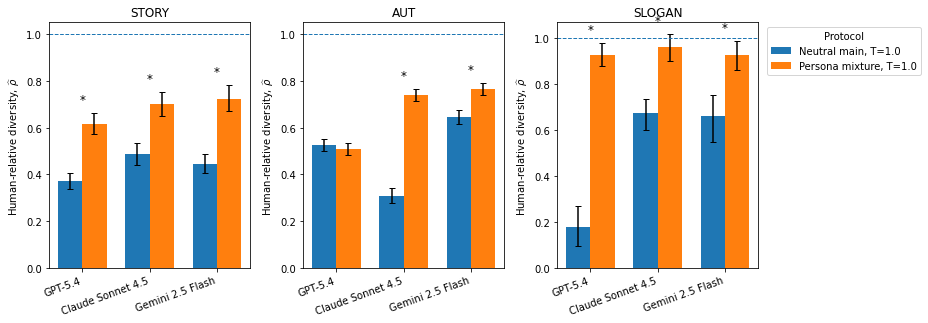

In [49]:
def plot_persona_vs_main_rho_bars(
    summary_df: pd.DataFrame,
    stats_df: pd.DataFrame,
    save_path: Path,
):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.6), sharey=False)

    bar_width = 0.36

    for ax, task in zip(axes, TASK_ORDER):
        sub = summary_df.query("task_family == @task").copy()
        sub = sub.set_index("model_label").reindex(MODEL_ORDER).reset_index()

        x = np.arange(len(sub))

        main_y = sub["main_rho_mean"].to_numpy(dtype=float)
        main_err_low = main_y - sub["main_rho_ci_low"].to_numpy(dtype=float)
        main_err_high = sub["main_rho_ci_high"].to_numpy(dtype=float) - main_y

        persona_y = sub["persona_rho_mean"].to_numpy(dtype=float)
        persona_err_low = persona_y - sub["persona_rho_ci_low"].to_numpy(dtype=float)
        persona_err_high = sub["persona_rho_ci_high"].to_numpy(dtype=float) - persona_y

        ax.bar(
            x - bar_width / 2,
            main_y,
            width=bar_width,
            yerr=[main_err_low, main_err_high],
            capsize=3,
            label="Neutral main, T=1.0",
        )

        ax.bar(
            x + bar_width / 2,
            persona_y,
            width=bar_width,
            yerr=[persona_err_low, persona_err_high],
            capsize=3,
            label="Persona mixture, T=1.0",
        )

        ax.axhline(1.0, linestyle="--", linewidth=1)
        ax.set_title(task.upper())
        ax.set_ylabel("Human-relative diversity, $\\widehat{\\rho}$")
        ax.set_xticks(x)
        ax.set_xticklabels(sub["model_label"], rotation=20, ha="right")

        # Add significance marks for rho improvement.
        sub_stats = (
            stats_df.query("task_family == @task")
            .set_index("model_label")
            .reindex(MODEL_ORDER)
            .reset_index()
        )

        for i in range(len(sub)):
            model_label = sub.loc[i, "model_label"]
            if pd.isna(model_label):
                continue

            row_stats = sub_stats.iloc[i]
            if pd.isna(row_stats["rho_diff_ci_low"]):
                continue

            y_top = max(
                sub.loc[i, "main_rho_ci_high"],
                sub.loc[i, "persona_rho_ci_high"],
            )

            if row_stats["rho_diff_ci_low"] > 0:
                mark = "*"
            elif row_stats["rho_diff_ci_high"] < 0:
                mark = "†"
            else:
                mark = ""

            if mark:
                ax.text(
                    x[i],
                    y_top + 0.03,
                    mark,
                    ha="center",
                    va="bottom",
                    fontsize=12,
                )

    axes[-1].legend(title="Protocol", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_persona_vs_main_rho_bars(
    summary_df=persona_vs_main_summary,
    stats_df=persona_vs_main_stats,
    save_path=FIG_DIR / "persona_mix_t1_vs_main_t1_rho_bars.pdf",
)

### Optional display table for the paper

This compact table reports the two $\widehat{\rho}$ estimates and the bootstrap difference test.

In [50]:
persona_vs_main_display = (
    persona_vs_main_summary[
        [
            "task_family",
            "model_label",
            "main_rho_mean",
            "main_rho_ci_low",
            "main_rho_ci_high",
            "persona_rho_mean",
            "persona_rho_ci_low",
            "persona_rho_ci_high",
            "rho_gain",
        ]
    ]
    .merge(
        persona_vs_main_stats[
            [
                "task_family",
                "model_label",
                "rho_diff_ci_low",
                "rho_diff_ci_high",
                "rho_diff_p_one_sided_gt0",
                "comparison_class",
            ]
        ],
        on=["task_family", "model_label"],
        how="left",
    )
    .sort_values(["task_family", "model_label"])
    .reset_index(drop=True)
)

display(persona_vs_main_display)

persona_vs_main_display.to_csv(
    TABLE_DIR / "persona_mix_t1_vs_main_t1_display_table.csv",
    index=False,
)

,task_family,model_label,main_rho_mean,main_rho_ci_low,main_rho_ci_high,persona_rho_mean,persona_rho_ci_low,persona_rho_ci_high,rho_gain,rho_diff_ci_low,rho_diff_ci_high,rho_diff_p_one_sided_gt0,comparison_class
0,aut,Claude Sonnet 4.5,0.308984,0.276905,0.341467,0.739183,0.712091,0.765349,0.430199,0.388366,0.474099,0.000,persona better
1,aut,GPT-5.4,0.525715,0.500492,0.549929,0.507319,0.482680,0.532670,-0.018396,-0.052519,0.017199,0.845,mixed / inconclusive
2,aut,Gemini 2.5 Flash,0.644675,0.613074,0.675940,0.766047,0.739261,0.792151,0.121371,0.080131,0.164047,0.000,persona better
3,slogan,Claude Sonnet 4.5,0.673138,0.599115,0.735155,0.960403,0.899188,1.016889,0.287265,0.201445,0.381665,0.000,persona better
4,slogan,GPT-5.4,0.178662,0.096408,0.268723,0.927323,0.877024,0.976119,0.748661,0.650114,0.846202,0.000,persona better
5,slogan,Gemini 2.5 Flash,0.660396,0.548687,0.750924,0.925631,0.861032,0.984452,0.265235,0.152809,0.391015,0.000,persona better
6,story,Claude Sonnet 4.5,0.485670,0.439442,0.534601,0.698698,0.648392,0.752949,0.213028,0.144920,0.283973,0.000,persona better
7,story,GPT-5.4,0.371931,0.339322,0.406755,0.615973,0.570406,0.662767,0.244042,0.188563,0.299977,0.000,persona better
8,story,Gemini 2.5 Flash,0.446144,0.407135,0.488161,0.723854,0.669827,0.782802,0.277711,0.212107,0.345185,0.000,persona better


### Interpretation aid

- `*` above a model indicates a bootstrap 95\% interval for $\Delta \widehat{\rho}$ entirely above 0, meaning persona mixture improved $\widehat{\rho}$ relative to neutral main.
- `†` would indicate the reverse.
- The dashed line at $\rho=1$ marks the no-excess-crowding threshold.

# 18. Actionable protocol effects on critical benefit curves

If a protocol reduces $\widehat{\Delta}$, then it lowers the critical private benefit required for rational adoption:

$ \frac{B^{crit}(X)}{\gamma}=1-\exp(-X\widehat{\Delta}) $

We compare the neutral main estimate to the best observed temperature or persona-mixture protocol for each model-task pair.

In [51]:
# Combine candidate protocol summaries.
main_protocol = main_ref.copy()
main_protocol["protocol_family"] = "neutral_main"
main_protocol["protocol_setting"] = "neutral_main_T=1.0"
main_protocol["temperature"] = 1.0
main_protocol["rho_mean"] = main_protocol["main_rho"]
main_protocol["delta_mean"] = main_protocol["main_delta"]
main_protocol["kappa_h_mean"] = main_protocol["main_kappa_h"]
main_protocol["kappa_a_mean"] = main_protocol["main_kappa_a"]

main_protocol = main_protocol[
    [
        "task_family",
        "model_label",
        "protocol_family",
        "protocol_setting",
        "temperature",
        "kappa_h_mean",
        "kappa_a_mean",
        "delta_mean",
        "rho_mean",
    ]
].copy()

temperature_protocol = temperature_task_summary[
    [
        "task_family",
        "model_label",
        "protocol_family",
        "protocol_setting",
        "temperature",
        "kappa_h_mean",
        "kappa_a_mean",
        "delta_mean",
        "rho_mean",
    ]
].copy()

persona_protocol = persona_mix_task_summary[
    [
        "task_family",
        "model_label",
        "protocol_family",
        "protocol_setting",
        "temperature",
        "kappa_h_mean",
        "kappa_a_mean",
        "delta_mean",
        "rho_mean",
    ]
].copy()

protocol_all = pd.concat(
    [main_protocol, temperature_protocol, persona_protocol],
    ignore_index=True,
)

# For each model-task, choose the protocol with highest rho.
best_protocol = (
    protocol_all
    .sort_values(["task_family", "model_label", "rho_mean"], ascending=[True, True, False])
    .groupby(["task_family", "model_label"], dropna=False)
    .head(1)
    .reset_index(drop=True)
)

best_protocol = best_protocol.merge(
    main_protocol.rename(
        columns={
            "rho_mean": "main_rho",
            "delta_mean": "main_delta",
            "protocol_setting": "main_protocol_setting",
        }
    )[["task_family", "model_label", "main_rho", "main_delta", "main_protocol_setting"]],
    on=["task_family", "model_label"],
    how="left",
)

best_protocol["rho_improvement"] = best_protocol["rho_mean"] - best_protocol["main_rho"]
best_protocol["delta_reduction"] = best_protocol["main_delta"] - best_protocol["delta_mean"]

display(best_protocol)

best_protocol.to_csv(
    TABLE_DIR / "best_observed_protocol_by_model_task.csv",
    index=False,
)

,task_family,model_label,protocol_family,protocol_setting,temperature,kappa_h_mean,kappa_a_mean,delta_mean,rho_mean,main_rho,main_delta,main_protocol_setting,rho_improvement,delta_reduction
0,aut,Claude Sonnet 4.5,persona_mixture,persona_mix_T=1.0,1.0,0.601258,0.705324,0.104065,0.739183,0.308882,0.275362,neutral_main_T=1.0,0.430302,0.171296
1,aut,GPT-5.4,temperature_grid,T=1.0,1.0,0.600879,0.790454,0.189575,0.526651,0.525446,0.189520,neutral_main_T=1.0,0.001205,-0.000055
2,aut,Gemini 2.5 Flash,persona_mixture,persona_mix_T=1.3,1.3,0.601153,0.679475,0.078322,0.804151,0.644685,0.142037,neutral_main_T=1.0,0.159467,0.063715
3,slogan,Claude Sonnet 4.5,persona_mixture,persona_mix_T=1.0,1.0,0.597487,0.613558,0.016514,0.960403,0.672075,0.132137,neutral_main_T=1.0,0.288328,0.115624
4,slogan,GPT-5.4,persona_mixture,persona_mix_T=1.3,1.3,0.597358,0.623904,0.026563,0.934368,0.179242,0.330772,neutral_main_T=1.0,0.755127,0.304210
5,slogan,Gemini 2.5 Flash,persona_mixture,persona_mix_T=1.3,1.3,0.597166,0.625935,0.028816,0.928875,0.661779,0.136397,neutral_main_T=1.0,0.267097,0.107581
6,story,Claude Sonnet 4.5,persona_mixture,persona_mix_T=1.0,1.0,0.705390,0.794765,0.089376,0.698698,0.485399,0.151266,neutral_main_T=1.0,0.213299,0.061891
7,story,GPT-5.4,persona_mixture,persona_mix_T=1.0,1.0,0.705435,0.819329,0.113894,0.615973,0.371828,0.186210,neutral_main_T=1.0,0.244145,0.072316
8,story,Gemini 2.5 Flash,persona_mixture,persona_mix_T=1.3,1.3,0.705540,0.781633,0.076263,0.748986,0.445808,0.163843,neutral_main_T=1.0,0.303178,0.087580


In [52]:
def critical_benefit(delta: float, X: np.ndarray) -> np.ndarray:
    return 1.0 - np.exp(-X * float(delta))


X_GRID = np.arange(0, 31)

crit_rows = []

for _, row in best_protocol.iterrows():
    for X in [1, 5, 10, 25]:
        crit_rows.append({
            "task_family": row["task_family"],
            "model_label": row["model_label"],
            "best_protocol_family": row["protocol_family"],
            "best_protocol_setting": row["protocol_setting"],
            "main_delta": row["main_delta"],
            "best_delta": row["delta_mean"],
            "main_rho": row["main_rho"],
            "best_rho": row["rho_mean"],
            "X": X,
            "main_Bcrit_over_gamma": float(critical_benefit(row["main_delta"], np.array([X]))[0]),
            "best_Bcrit_over_gamma": float(critical_benefit(row["delta_mean"], np.array([X]))[0]),
        })

critical_benefit_protocol_table = pd.DataFrame(crit_rows)
critical_benefit_protocol_table["absolute_reduction"] = (
    critical_benefit_protocol_table["main_Bcrit_over_gamma"]
    - critical_benefit_protocol_table["best_Bcrit_over_gamma"]
)

display(critical_benefit_protocol_table)

critical_benefit_protocol_table.to_csv(
    TABLE_DIR / "critical_benefit_main_vs_best_protocol.csv",
    index=False,
)

,task_family,model_label,best_protocol_family,best_protocol_setting,main_delta,best_delta,main_rho,best_rho,X,main_Bcrit_over_gamma,best_Bcrit_over_gamma,absolute_reduction
0,aut,Claude Sonnet 4.5,persona_mixture,persona_mix_T=1.0,0.275362,0.104065,0.308882,0.739183,1,0.240702,0.098833,0.141869
1,aut,Claude Sonnet 4.5,persona_mixture,persona_mix_T=1.0,0.275362,0.104065,0.308882,0.739183,5,0.747617,0.405673,0.341944
2,aut,Claude Sonnet 4.5,persona_mixture,persona_mix_T=1.0,0.275362,0.104065,0.308882,0.739183,10,0.936303,0.646776,0.289527
3,aut,Claude Sonnet 4.5,persona_mixture,persona_mix_T=1.0,0.275362,0.104065,0.308882,0.739183,25,0.998976,0.925847,0.073129
4,aut,GPT-5.4,temperature_grid,T=1.0,0.189520,0.189575,0.525446,0.526651,1,0.172644,0.172690,-0.000046
5,aut,GPT-5.4,temperature_grid,T=1.0,0.189520,0.189575,0.525446,0.526651,5,0.612329,0.612437,-0.000107
6,aut,GPT-5.4,temperature_grid,T=1.0,0.189520,0.189575,0.525446,0.526651,10,0.849712,0.849795,-0.000083
7,aut,GPT-5.4,temperature_grid,T=1.0,0.189520,0.189575,0.525446,0.526651,25,0.991244,0.991256,-0.000012
8,aut,Gemini 2.5 Flash,persona_mixture,persona_mix_T=1.3,0.142037,0.078322,0.644685,0.804151,1,0.132410,0.075333,0.057077
9,aut,Gemini 2.5 Flash,persona_mixture,persona_mix_T=1.3,0.142037,0.078322,0.644685,0.804151,5,0.508446,0.324031,0.184415


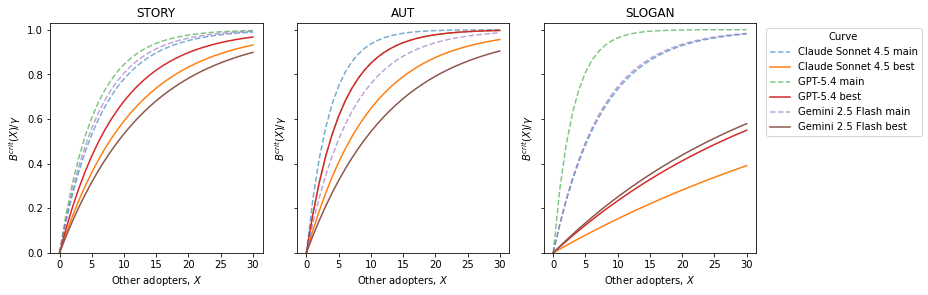

In [53]:
def plot_critical_benefit_main_vs_best(save_path: Path):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)

    for ax, task in zip(axes, TASK_ORDER):
        sub_task = best_protocol.query("task_family == @task").copy()

        for _, row in sub_task.iterrows():
            model_label = row["model_label"]

            y_main = critical_benefit(row["main_delta"], X_GRID)
            y_best = critical_benefit(row["delta_mean"], X_GRID)

            ax.plot(
                X_GRID,
                y_main,
                linestyle="--",
                alpha=0.6,
                label=f"{model_label} main",
            )

            ax.plot(
                X_GRID,
                y_best,
                linestyle="-",
                label=f"{model_label} best",
            )

        ax.set_title(task.upper())
        ax.set_xlabel("Other adopters, $X$")
        ax.set_ylabel("$B^{crit}(X)/\\gamma$")
        ax.set_ylim(0, 1.03)

    axes[-1].legend(title="Curve", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_critical_benefit_main_vs_best(
    save_path=FIG_DIR / "critical_benefit_main_vs_best_protocol.pdf"
)

,task_family,model_label,best_protocol_family,best_protocol_setting,main_delta,best_delta,main_rho,best_rho,X,main_Bcrit_over_gamma,best_Bcrit_over_gamma,absolute_reduction
0,aut,Claude Sonnet 4.5,persona_mixture,persona_mix_T=1.0,0.275362,0.104065,0.308882,0.739183,1,0.240702,0.098833,0.141869
1,aut,GPT-5.4,temperature_grid,T=1.0,0.189520,0.189575,0.525446,0.526651,1,0.172644,0.172690,-0.000046
2,aut,Gemini 2.5 Flash,persona_mixture,persona_mix_T=1.3,0.142037,0.078322,0.644685,0.804151,1,0.132410,0.075333,0.057077
3,slogan,Claude Sonnet 4.5,persona_mixture,persona_mix_T=1.0,0.132137,0.016514,0.672075,0.960403,1,0.123779,0.016378,0.107401
4,slogan,GPT-5.4,persona_mixture,persona_mix_T=1.3,0.330772,0.026563,0.179242,0.934368,1,0.281631,0.026213,0.255418
5,slogan,Gemini 2.5 Flash,persona_mixture,persona_mix_T=1.3,0.136397,0.028816,0.661779,0.928875,1,0.127504,0.028405,0.099099
6,story,Claude Sonnet 4.5,persona_mixture,persona_mix_T=1.0,0.151266,0.089376,0.485399,0.698698,1,0.140381,0.085498,0.054883
7,story,GPT-5.4,persona_mixture,persona_mix_T=1.0,0.186210,0.113894,0.371828,0.615973,1,0.169901,0.107648,0.062253
8,story,Gemini 2.5 Flash,persona_mixture,persona_mix_T=1.3,0.163843,0.076263,0.445808,0.748986,1,0.151125,0.073428,0.077697


Task-specific x-axis maxima:
  story: 50
  aut: 50
  slogan: 220


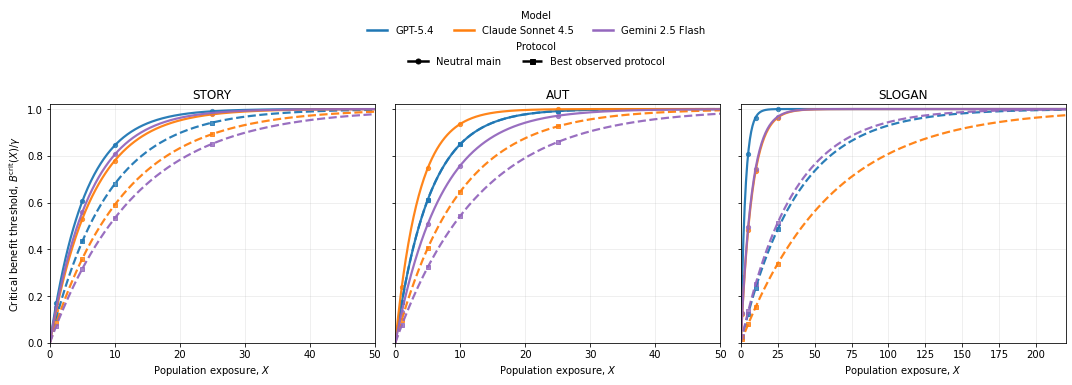

Saved figure to: analysis_outputs/figures/critical_benefit_main_vs_best_protocol_taskscaled.pdf


In [54]:
# ============================================================
# Improved critical-benefit figure:
# - better color separation
# - same color within model
# - solid = main protocol
# - dashed = best observed protocol
# - task-specific x-axis ranges
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Load if needed.
# ------------------------------------------------------------------
if "critical_benefit_best_df" not in globals():
    critical_benefit_best_df = pd.read_csv(
        TABLE_DIR / "critical_benefit_main_vs_best_protocol.csv"
    )

critical_benefit_summary = (
    critical_benefit_best_df
    .sort_values(["task_family", "model_label", "X"])
    .groupby(["task_family", "model_label"], as_index=False)
    .first()
)

display(critical_benefit_summary)

# ------------------------------------------------------------------
# Orders
# ------------------------------------------------------------------
TASK_ORDER = ["story", "aut", "slogan"] if "TASK_ORDER" not in globals() else TASK_ORDER
MODEL_ORDER = (
    ["GPT-5.4", "Claude Sonnet 4.5", "Gemini 2.5 Flash"]
    if "MODEL_ORDER" not in globals() else MODEL_ORDER
)

# ------------------------------------------------------------------
# Better-separated color mapping
# ------------------------------------------------------------------
model_colors = {
    "GPT-5.4": "#1f77b4",            # blue
    "Claude Sonnet 4.5": "#ff7f0e",  # orange
    "Gemini 2.5 Flash": "#9467bd",   # purple
}

# ------------------------------------------------------------------
# Choose task-specific x-axis maxima.
#
# For each task, find the smallest positive BEST delta among models
# in that task (i.e., the slowest-improving best protocol), and choose
# x_max so that it reaches TARGET_Y.
# ------------------------------------------------------------------
TARGET_Y = 0.97   # slightly less extreme than 0.99, visually cleaner
MIN_XMAX = 40
ROUND_TO = 10

task_xmax = {}

for task in TASK_ORDER:
    sub = critical_benefit_summary.query("task_family == @task").copy()
    positive_best_deltas = sub.loc[sub["best_delta"] > 0, "best_delta"]

    if len(positive_best_deltas) == 0:
        x_max = MIN_XMAX
    else:
        slowest_best_delta = positive_best_deltas.min()
        x_needed = -np.log(1 - TARGET_Y) / slowest_best_delta
        x_max = int(np.ceil(x_needed / ROUND_TO) * ROUND_TO)
        x_max = max(x_max, MIN_XMAX)

    task_xmax[task] = x_max

print("Task-specific x-axis maxima:")
for task in TASK_ORDER:
    print(f"  {task}: {task_xmax[task]}")

# ------------------------------------------------------------------
# Make the figure
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)

for ax, task in zip(axes, TASK_ORDER):
    sub = (
        critical_benefit_summary
        .query("task_family == @task")
        .set_index("model_label")
        .reindex(MODEL_ORDER)
        .reset_index()
    )

    x_max = task_xmax[task]
    x_grid = np.linspace(0, x_max, 500)

    for _, row in sub.iterrows():
        model_label = row["model_label"]

        if pd.isna(model_label):
            continue

        color = model_colors[model_label]
        main_delta = float(row["main_delta"])
        best_delta = float(row["best_delta"])

        # Smooth curves
        y_main = 1.0 - np.exp(-x_grid * main_delta)
        y_best = 1.0 - np.exp(-x_grid * best_delta)

        # Main protocol: solid
        ax.plot(
            x_grid,
            y_main,
            linestyle="-",
            linewidth=2.2,
            color=color,
            alpha=0.95,
        )

        # Best observed protocol: dashed
        ax.plot(
            x_grid,
            y_best,
            linestyle="--",
            linewidth=2.2,
            color=color,
            alpha=0.95,
        )

        # Show the tabulated X points
        sub_points = critical_benefit_best_df[
            (critical_benefit_best_df["task_family"] == task) &
            (critical_benefit_best_df["model_label"] == model_label)
        ].copy()

        ax.scatter(
            sub_points["X"],
            sub_points["main_Bcrit_over_gamma"],
            color=color,
            s=18,
            marker="o",
            alpha=0.8,
        )
        ax.scatter(
            sub_points["X"],
            sub_points["best_Bcrit_over_gamma"],
            color=color,
            s=18,
            marker="s",
            alpha=0.8,
        )

    ax.set_title(task.upper())
    ax.set_xlabel(r"Population exposure, $X$")
    ax.set_xlim(0, x_max)
    ax.set_ylim(0, 1.02)
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel(r"Critical benefit threshold, $B^{\mathrm{crit}}(X)/\gamma$")

# ------------------------------------------------------------------
# Two-part legend
# ------------------------------------------------------------------
model_handles = [
    Line2D([0], [0], color=model_colors[m], lw=2.5, linestyle="-", label=m)
    for m in MODEL_ORDER
]

protocol_handles = [
    Line2D([0], [0], color="black", lw=2.5, linestyle="-", marker="o",
           markersize=5, label="Neutral main"),
    Line2D([0], [0], color="black", lw=2.5, linestyle="--", marker="s",
           markersize=5, label="Best observed protocol"),
]

legend1 = fig.legend(
    handles=model_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=len(MODEL_ORDER),
    title="Model",
    frameon=False,
)

legend2 = fig.legend(
    handles=protocol_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=2,
    title="Protocol",
    frameon=False,
)

fig.tight_layout(rect=[0, 0, 1, 0.90])

save_path = FIG_DIR / "critical_benefit_main_vs_best_protocol_taskscaled.pdf"
fig.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {save_path}")

In [55]:
# ============================================================
# Fixed-T critical-benefit figure:
# Neutral main T=1.0 vs persona-mixture T=1.0
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

FIXED_T_CRIT_DIR = ANALYSIS_DIR / "critical_benefit_fixed_t_persona"
FIXED_T_CRIT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------
# Ensure persona_mix_t1_summary exists.
# ------------------------------------------------------------------
if "persona_mix_t1_summary" not in globals():
    persona_mix_t1_summary = (
        persona_mix_task_summary[
            np.isclose(
                pd.to_numeric(persona_mix_task_summary["temperature"], errors="coerce"),
                1.0,
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

assert len(persona_mix_t1_summary) > 0, "No persona-mixture T=1.0 rows found."

# ------------------------------------------------------------------
# Build one row per model-task pair.
# ------------------------------------------------------------------
main_for_fixed_t = main_t1_task_summary[
    [
        "task_family",
        "model_label",
        "delta_mean",
        "rho_mean",
        "kappa_h_mean",
        "kappa_a_mean",
    ]
].rename(
    columns={
        "delta_mean": "main_delta",
        "rho_mean": "main_rho",
        "kappa_h_mean": "main_kappa_h",
        "kappa_a_mean": "main_kappa_a",
    }
)

persona_for_fixed_t = persona_mix_t1_summary[
    [
        "task_family",
        "model_label",
        "delta_mean",
        "rho_mean",
        "kappa_h_mean",
        "kappa_a_mean",
    ]
].rename(
    columns={
        "delta_mean": "persona_delta",
        "rho_mean": "persona_rho",
        "kappa_h_mean": "persona_kappa_h",
        "kappa_a_mean": "persona_kappa_a",
    }
)

fixed_t_critical_summary = main_for_fixed_t.merge(
    persona_for_fixed_t,
    on=["task_family", "model_label"],
    how="inner",
    validate="one_to_one",
)

fixed_t_critical_summary["delta_reduction"] = (
    fixed_t_critical_summary["main_delta"]
    - fixed_t_critical_summary["persona_delta"]
)

fixed_t_critical_summary["rho_gain"] = (
    fixed_t_critical_summary["persona_rho"]
    - fixed_t_critical_summary["main_rho"]
)

fixed_t_critical_summary = fixed_t_critical_summary.sort_values(
    ["task_family", "model_label"]
).reset_index(drop=True)

display(fixed_t_critical_summary)

fixed_t_critical_summary.to_csv(
    TABLE_DIR / "critical_benefit_main_vs_persona_t1_summary.csv",
    index=False,
)

,task_family,model_label,main_delta,main_rho,main_kappa_h,main_kappa_a,persona_delta,persona_rho,persona_kappa_h,persona_kappa_a,delta_reduction,rho_gain
0,aut,Claude Sonnet 4.5,0.275498,0.308984,0.601023,0.876521,0.104065,0.739183,0.601258,0.705324,0.171433,0.430199
1,aut,GPT-5.4,0.189451,0.525715,0.601126,0.790576,0.196733,0.507319,0.601244,0.797978,-0.007283,-0.018396
2,aut,Gemini 2.5 Flash,0.142068,0.644675,0.601046,0.743114,0.093562,0.766047,0.601149,0.694711,0.048506,0.121371
3,slogan,Claude Sonnet 4.5,0.131767,0.673138,0.597141,0.728908,0.016514,0.960403,0.597487,0.613558,0.115253,0.287265
4,slogan,GPT-5.4,0.330877,0.178662,0.597150,0.928028,0.029419,0.927323,0.597028,0.626435,0.301458,0.748661
5,slogan,Gemini 2.5 Flash,0.136862,0.660396,0.597231,0.734093,0.030116,0.925631,0.597100,0.627184,0.106746,0.265235
6,story,Claude Sonnet 4.5,0.151260,0.485670,0.705659,0.856919,0.089376,0.698698,0.705390,0.794765,0.061884,0.213028
7,story,GPT-5.4,0.186393,0.371931,0.705255,0.891648,0.113894,0.615973,0.705435,0.819329,0.072499,0.244042
8,story,Gemini 2.5 Flash,0.163641,0.446144,0.705500,0.869141,0.083379,0.723854,0.705650,0.788988,0.080263,0.277711


In [56]:
# ------------------------------------------------------------------
# Create tabulated critical-benefit values for common X points.
# ------------------------------------------------------------------

def critical_benefit(delta: float, X: np.ndarray) -> np.ndarray:
    return 1.0 - np.exp(-X * float(delta))


X_TABLE = [1, 5, 10, 25]

fixed_t_crit_rows = []

for _, row in fixed_t_critical_summary.iterrows():
    for X in X_TABLE:
        main_bcrit = float(critical_benefit(row["main_delta"], np.array([X]))[0])
        persona_bcrit = float(critical_benefit(row["persona_delta"], np.array([X]))[0])

        fixed_t_crit_rows.append({
            "task_family": row["task_family"],
            "model_label": row["model_label"],
            "X": X,
            "main_delta": row["main_delta"],
            "persona_delta": row["persona_delta"],
            "main_rho": row["main_rho"],
            "persona_rho": row["persona_rho"],
            "main_Bcrit_over_gamma": main_bcrit,
            "persona_Bcrit_over_gamma": persona_bcrit,
            "absolute_reduction": main_bcrit - persona_bcrit,
        })

fixed_t_critical_table = pd.DataFrame(fixed_t_crit_rows)

display(fixed_t_critical_table)

fixed_t_critical_table.to_csv(
    TABLE_DIR / "critical_benefit_main_vs_persona_t1_values.csv",
    index=False,
)

,task_family,model_label,X,main_delta,persona_delta,main_rho,persona_rho,main_Bcrit_over_gamma,persona_Bcrit_over_gamma,absolute_reduction
0,aut,Claude Sonnet 4.5,1,0.275498,0.104065,0.308984,0.739183,0.240806,0.098833,0.141973
1,aut,Claude Sonnet 4.5,5,0.275498,0.104065,0.308984,0.739183,0.747789,0.405673,0.342116
2,aut,Claude Sonnet 4.5,10,0.275498,0.104065,0.308984,0.739183,0.936390,0.646776,0.289614
3,aut,Claude Sonnet 4.5,25,0.275498,0.104065,0.308984,0.739183,0.998979,0.925847,0.073132
4,aut,GPT-5.4,1,0.189451,0.196733,0.525715,0.507319,0.172587,0.178590,-0.006004
5,aut,GPT-5.4,5,0.189451,0.196733,0.525715,0.507319,0.612195,0.626062,-0.013867
6,aut,GPT-5.4,10,0.189451,0.196733,0.525715,0.507319,0.849608,0.860171,-0.010563
7,aut,GPT-5.4,25,0.189451,0.196733,0.525715,0.507319,0.991229,0.992689,-0.001460
8,aut,Gemini 2.5 Flash,1,0.142068,0.093562,0.644675,0.766047,0.132438,0.089319,0.043119
9,aut,Gemini 2.5 Flash,5,0.142068,0.093562,0.644675,0.766047,0.508523,0.373628,0.134895


Task-specific x-axis maxima:
  story: 50
  aut: 40
  slogan: 220


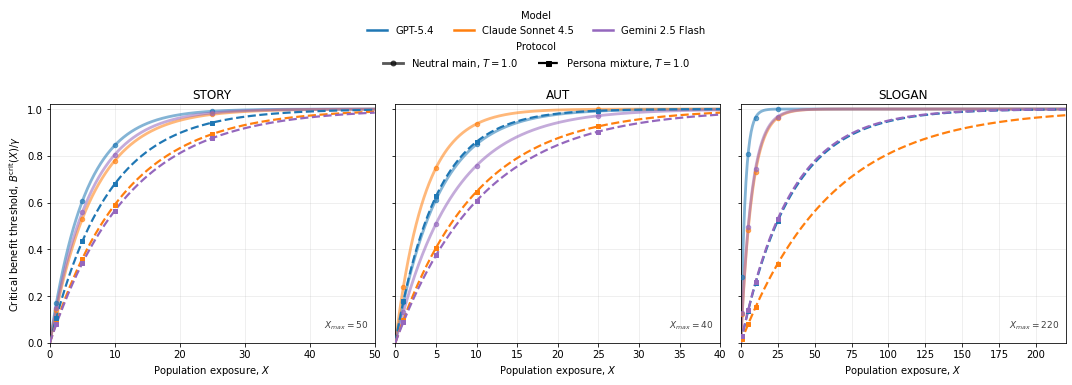

Saved figure to: analysis_outputs/figures/critical_benefit_main_vs_persona_t1_taskscaled.pdf


In [57]:
# ============================================================
# Plot: main T=1.0 vs persona-mixture T=1.0
# ============================================================

TASK_ORDER = ["story", "aut", "slogan"] if "TASK_ORDER" not in globals() else TASK_ORDER
MODEL_ORDER = (
    ["GPT-5.4", "Claude Sonnet 4.5", "Gemini 2.5 Flash"]
    if "MODEL_ORDER" not in globals() else MODEL_ORDER
)

# Better-separated colors.
model_colors = {
    "GPT-5.4": "#1f77b4",            # blue
    "Claude Sonnet 4.5": "#ff7f0e",  # orange
    "Gemini 2.5 Flash": "#9467bd",   # purple
}

# Choose task-specific x-axis maxima.
# We use the smallest positive PERSONA delta within each task because
# the persona curve is the improved, slower-saturating curve.
TARGET_Y = 0.97
MIN_XMAX = 40
ROUND_TO = 10

task_xmax = {}

for task in TASK_ORDER:
    sub = fixed_t_critical_summary.query("task_family == @task").copy()
    positive_persona_deltas = sub.loc[sub["persona_delta"] > 0, "persona_delta"]

    if len(positive_persona_deltas) == 0:
        x_max = MIN_XMAX
    else:
        slowest_delta = positive_persona_deltas.min()
        x_needed = -np.log(1 - TARGET_Y) / slowest_delta
        x_max = int(np.ceil(x_needed / ROUND_TO) * ROUND_TO)
        x_max = max(x_max, MIN_XMAX)

    task_xmax[task] = x_max

print("Task-specific x-axis maxima:")
for task in TASK_ORDER:
    print(f"  {task}: {task_xmax[task]}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)

for ax, task in zip(axes, TASK_ORDER):
    sub = (
        fixed_t_critical_summary
        .query("task_family == @task")
        .set_index("model_label")
        .reindex(MODEL_ORDER)
        .reset_index()
    )

    x_max = task_xmax[task]
    x_grid = np.linspace(0, x_max, 500)

    for _, row in sub.iterrows():
        model_label = row["model_label"]

        if pd.isna(model_label):
            continue

        color = model_colors[model_label]

        main_delta = float(row["main_delta"])
        persona_delta = float(row["persona_delta"])

        y_main = critical_benefit(main_delta, x_grid)
        y_persona = critical_benefit(persona_delta, x_grid)

        # Main: solid, thicker, partially transparent.
        ax.plot(
            x_grid,
            y_main,
            linestyle="-",
            linewidth=2.8,
            color=color,
            alpha=0.55,
            zorder=2,
        )

        # Persona mixture: dashed, fully opaque, drawn on top.
        ax.plot(
            x_grid,
            y_persona,
            linestyle="--",
            linewidth=2.2,
            color=color,
            alpha=1.0,
            zorder=3,
        )

        # Add tabulated X points.
        sub_points = fixed_t_critical_table[
            (fixed_t_critical_table["task_family"] == task) &
            (fixed_t_critical_table["model_label"] == model_label)
        ].copy()

        ax.scatter(
            sub_points["X"],
            sub_points["main_Bcrit_over_gamma"],
            color=color,
            s=20,
            marker="o",
            alpha=0.65,
            zorder=4,
        )

        ax.scatter(
            sub_points["X"],
            sub_points["persona_Bcrit_over_gamma"],
            color=color,
            s=24,
            marker="s",
            alpha=1.0,
            zorder=5,
        )

    ax.set_title(task.upper())
    ax.set_xlabel(r"Population exposure, $X$")
    ax.set_xlim(0, x_max)
    ax.set_ylim(0, 1.02)
    ax.grid(True, alpha=0.25)

    # Optional: show task-specific x scale.
    ax.text(
        0.98,
        0.05,
        rf"$X_{{max}}={x_max}$",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=9,
        alpha=0.75,
    )

axes[0].set_ylabel(r"Critical benefit threshold, $B^{\mathrm{crit}}(X)/\gamma$")

# Legends.
model_handles = [
    Line2D([0], [0], color=model_colors[m], lw=2.5, linestyle="-", label=m)
    for m in MODEL_ORDER
]

protocol_handles = [
    Line2D(
        [0], [0],
        color="black",
        lw=2.8,
        linestyle="-",
        marker="o",
        markersize=5,
        alpha=0.65,
        label=r"Neutral main, $T=1.0$",
    ),
    Line2D(
        [0], [0],
        color="black",
        lw=2.2,
        linestyle="--",
        marker="s",
        markersize=5,
        label=r"Persona mixture, $T=1.0$",
    ),
]

fig.legend(
    handles=model_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=len(MODEL_ORDER),
    title="Model",
    frameon=False,
)

fig.legend(
    handles=protocol_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=2,
    title="Protocol",
    frameon=False,
)

fig.tight_layout(rect=[0, 0, 1, 0.90])

save_path = FIG_DIR / "critical_benefit_main_vs_persona_t1_taskscaled.pdf"
fig.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {save_path}")

# 19. Final actionable-protocol output report

In [58]:
print("=" * 100)
print("ACTIONABLE PROTOCOL OUTPUTS")
print("=" * 100)

saved_paths = [
    TABLE_DIR / "temperature_grid_task_level_semantic_crowding.csv",
    TABLE_DIR / "temperature_grid_monotonicity_tests.csv",
    TABLE_DIR / "persona_mixture_task_level_semantic_crowding.csv",
    TABLE_DIR / "persona_mixture_against_main.csv",
    TABLE_DIR / "best_observed_protocol_by_model_task.csv",
    TABLE_DIR / "critical_benefit_main_vs_best_protocol.csv",
    FIG_DIR / "temperature_grid_rho_with_main_t1.pdf",
    FIG_DIR / "temperature_grid_delta_with_main_t1.pdf",
    FIG_DIR / "temperature_grid_kappa_a_with_main_t1.pdf",
    FIG_DIR / "persona_mixture_rho_shift_from_main.pdf",
    FIG_DIR / "persona_mixture_rho_absolute.pdf",
    FIG_DIR / "critical_benefit_main_vs_best_protocol.pdf",
]

for p in saved_paths:
    print(p, "| exists:", p.exists())

print("\nTemperature monotonicity:")
display(temperature_monotonicity)

print("\nPersona-mixture vs main:")
display(
    persona_mix_vs_main[
        [
            "task_family",
            "model_label",
            "temperature",
            "protocol_setting",
            "main_rho",
            "rho_mean",
            "rho_shift_from_main",
            "main_delta",
            "delta_mean",
            "delta_shift_from_main",
            "protocol_shift_class",
        ]
    ].sort_values(["task_family", "model_label", "temperature"])
)

print("\nBest observed protocol per model-task:")
display(best_protocol)

ACTIONABLE PROTOCOL OUTPUTS
analysis_outputs/tables/temperature_grid_task_level_semantic_crowding.csv | exists: True
analysis_outputs/tables/temperature_grid_monotonicity_tests.csv | exists: True
analysis_outputs/tables/persona_mixture_task_level_semantic_crowding.csv | exists: True
analysis_outputs/tables/persona_mixture_against_main.csv | exists: True
analysis_outputs/tables/best_observed_protocol_by_model_task.csv | exists: True
analysis_outputs/tables/critical_benefit_main_vs_best_protocol.csv | exists: True
analysis_outputs/figures/temperature_grid_rho_with_main_t1.pdf | exists: True
analysis_outputs/figures/temperature_grid_delta_with_main_t1.pdf | exists: True
analysis_outputs/figures/temperature_grid_kappa_a_with_main_t1.pdf | exists: True
analysis_outputs/figures/persona_mixture_rho_shift_from_main.pdf | exists: True
analysis_outputs/figures/persona_mixture_rho_absolute.pdf | exists: True
analysis_outputs/figures/critical_benefit_main_vs_best_protocol.pdf | exists: True

Tempe

,task_family,model_label,n_temperatures,temperatures,rho_at_min_temp,rho_at_max_temp,rho_change_max_minus_min,spearman_temp_rho,spearman_temp_rho_p,kendall_temp_rho,kendall_temp_rho_p,delta_at_min_temp,delta_at_max_temp,delta_change_max_minus_min,spearman_temp_delta,spearman_temp_delta_p,kendall_temp_delta,kendall_temp_delta_p,kappa_a_at_min_temp,kappa_a_at_max_temp,kappa_a_change_max_minus_min,spearman_temp_kappa_a,spearman_temp_kappa_a_p,kendall_temp_kappa_a,kendall_temp_kappa_a_p
0,aut,Claude Sonnet 4.5,3,"0.3, 0.7, 1.0",0.167183,0.309908,0.142725,1.0,0.000000,1.000000,0.333333,0.332072,0.275530,-0.056542,-1.0,0.000000,-1.000000,0.333333,0.933035,0.876406,-0.056629,-1.0,0.000000,-1.000000,0.333333
1,aut,GPT-5.4,3,"0.7, 1.0, 1.3",0.451661,0.465341,0.013680,0.5,0.666667,0.333333,1.000000,0.219514,0.214076,-0.005438,-0.5,0.666667,-0.333333,1.000000,0.820490,0.815347,-0.005144,-0.5,0.666667,-0.333333,1.000000
2,aut,Gemini 2.5 Flash,3,"0.7, 1.0, 1.3",0.508704,0.654922,0.146218,1.0,0.000000,1.000000,0.333333,0.196615,0.138260,-0.058356,-1.0,0.000000,-1.000000,0.333333,0.797752,0.739526,-0.058226,-1.0,0.000000,-1.000000,0.333333
3,slogan,Claude Sonnet 4.5,3,"0.3, 0.7, 1.0",0.418385,0.672215,0.253831,1.0,0.000000,1.000000,0.333333,0.234663,0.132444,-0.102219,-1.0,0.000000,-1.000000,0.333333,0.831886,0.729998,-0.101887,-1.0,0.000000,-1.000000,0.333333
4,slogan,GPT-5.4,3,"0.7, 1.0, 1.3",0.064431,0.227421,0.162989,1.0,0.000000,1.000000,0.333333,0.376884,0.311506,-0.065379,-1.0,0.000000,-1.000000,0.333333,0.974095,0.908573,-0.065522,-1.0,0.000000,-1.000000,0.333333
5,slogan,Gemini 2.5 Flash,3,"0.7, 1.0, 1.3",0.569634,0.710626,0.140992,1.0,0.000000,1.000000,0.333333,0.173495,0.117089,-0.056406,-1.0,0.000000,-1.000000,0.333333,0.771360,0.714502,-0.056858,-1.0,0.000000,-1.000000,0.333333
6,story,Claude Sonnet 4.5,3,"0.3, 0.7, 1.0",0.289102,0.487483,0.198380,1.0,0.000000,1.000000,0.333333,0.209695,0.151311,-0.058385,-1.0,0.000000,-1.000000,0.333333,0.915099,0.856878,-0.058222,-1.0,0.000000,-1.000000,0.333333
7,story,GPT-5.4,3,"0.7, 1.0, 1.3",0.319502,0.367760,0.048258,0.5,0.666667,0.333333,1.000000,0.202614,0.187909,-0.014705,-0.5,0.666667,-0.333333,1.000000,0.907853,0.893070,-0.014783,-0.5,0.666667,-0.333333,1.000000
8,story,Gemini 2.5 Flash,3,"0.7, 1.0, 1.3",0.378065,0.401493,0.023428,0.5,0.666667,0.333333,1.000000,0.184751,0.177391,-0.007360,-0.5,0.666667,-0.333333,1.000000,0.890121,0.883073,-0.007048,-0.5,0.666667,-0.333333,1.000000



Persona-mixture vs main:


,task_family,model_label,temperature,protocol_setting,main_rho,rho_mean,rho_shift_from_main,main_delta,delta_mean,delta_shift_from_main,protocol_shift_class
0,aut,Claude Sonnet 4.5,0.3,persona_mix_T=0.3,0.308882,0.694514,0.385632,0.275362,0.121914,-0.153448,higher diversity than main
1,aut,Claude Sonnet 4.5,0.7,persona_mix_T=0.7,0.308882,0.730644,0.421762,0.275362,0.107528,-0.167834,higher diversity than main
2,aut,Claude Sonnet 4.5,1.0,persona_mix_T=1.0,0.308882,0.739183,0.430302,0.275362,0.104065,-0.171296,higher diversity than main
3,aut,GPT-5.4,0.7,persona_mix_T=0.7,0.525446,0.475115,-0.050330,0.189520,0.209602,0.020082,lower diversity than main
4,aut,GPT-5.4,1.0,persona_mix_T=1.0,0.525446,0.507319,-0.018127,0.189520,0.196733,0.007213,stable
5,aut,GPT-5.4,1.3,persona_mix_T=1.3,0.525446,0.522732,-0.002714,0.189520,0.190657,0.001137,stable
6,aut,Gemini 2.5 Flash,0.7,persona_mix_T=0.7,0.644685,0.718621,0.073936,0.142037,0.112503,-0.029533,higher diversity than main
7,aut,Gemini 2.5 Flash,1.0,persona_mix_T=1.0,0.644685,0.766047,0.121362,0.142037,0.093562,-0.048474,higher diversity than main
8,aut,Gemini 2.5 Flash,1.3,persona_mix_T=1.3,0.644685,0.804151,0.159467,0.142037,0.078322,-0.063715,higher diversity than main
9,slogan,Claude Sonnet 4.5,0.3,persona_mix_T=0.3,0.672075,0.954491,0.282416,0.132137,0.018676,-0.113462,higher diversity than main



Best observed protocol per model-task:


,task_family,model_label,protocol_family,protocol_setting,temperature,kappa_h_mean,kappa_a_mean,delta_mean,rho_mean,main_rho,main_delta,main_protocol_setting,rho_improvement,delta_reduction
0,aut,Claude Sonnet 4.5,persona_mixture,persona_mix_T=1.0,1.0,0.601258,0.705324,0.104065,0.739183,0.308882,0.275362,neutral_main_T=1.0,0.430302,0.171296
1,aut,GPT-5.4,temperature_grid,T=1.0,1.0,0.600879,0.790454,0.189575,0.526651,0.525446,0.189520,neutral_main_T=1.0,0.001205,-0.000055
2,aut,Gemini 2.5 Flash,persona_mixture,persona_mix_T=1.3,1.3,0.601153,0.679475,0.078322,0.804151,0.644685,0.142037,neutral_main_T=1.0,0.159467,0.063715
3,slogan,Claude Sonnet 4.5,persona_mixture,persona_mix_T=1.0,1.0,0.597487,0.613558,0.016514,0.960403,0.672075,0.132137,neutral_main_T=1.0,0.288328,0.115624
4,slogan,GPT-5.4,persona_mixture,persona_mix_T=1.3,1.3,0.597358,0.623904,0.026563,0.934368,0.179242,0.330772,neutral_main_T=1.0,0.755127,0.304210
5,slogan,Gemini 2.5 Flash,persona_mixture,persona_mix_T=1.3,1.3,0.597166,0.625935,0.028816,0.928875,0.661779,0.136397,neutral_main_T=1.0,0.267097,0.107581
6,story,Claude Sonnet 4.5,persona_mixture,persona_mix_T=1.0,1.0,0.705390,0.794765,0.089376,0.698698,0.485399,0.151266,neutral_main_T=1.0,0.213299,0.061891
7,story,GPT-5.4,persona_mixture,persona_mix_T=1.0,1.0,0.705435,0.819329,0.113894,0.615973,0.371828,0.186210,neutral_main_T=1.0,0.244145,0.072316
8,story,Gemini 2.5 Flash,persona_mixture,persona_mix_T=1.3,1.3,0.705540,0.781633,0.076263,0.748986,0.445808,0.163843,neutral_main_T=1.0,0.303178,0.087580
